Ссылка на Githab:
https://github.com/Konopatskaya/Yeti
_______________
# Классификация пользователей на группы по возрастным интервалам
_______________

**Описание исследования**. IT-компания «Йети», управляет группой популярных интернет-сервисов. Каждый день через них проходят миллионы пользователей. Значительную часть дохода компания получает от контекстной рекламы. В связи с этим, важно показывать рекламу (таргетировать рекламу) своей группе пользователей, в зависимости от возраста. Чем больше рекламу посмотрит целевая аудитория, тем больше коэффициент кликабельности CTR и, следовательно, прибыли получит компания. Таргетированная реклама  - это привлечение прибыли, повышение качества услуг и имиджа компании.  

1. Тип: Задача обучения с учителем
2. Целевая перерменная (Target): `age_category` — возрастная категория пользователя, этот показатель модель должна научиться предсказывать. Признак многоклассовой классфикации, где:
  -  0: младше 18;
  -  1: 18-25 лет;
  -  2: 26-40 лет;
  -  3: 41-55 лет;
  -  4: 56+ лет.
_______________

**Цель исследования** - построить предсказательную модель многоклассовой классификации, которая разделяет пользователей на несколько групп по возрастным интервалам.

Бизнес-контекст и цель:
- Проблема: отсутствует таргетированная по возрастым группам реклама. Маркетологи тратят много сил и средств, чтобы узнать, какой возрастной категории будет интересен продвигаемый товар. Для них выяснить возраст целевой аудитории — это не просто хорошая практика, а залог эффективности рекламы. Одна из задач отделов маркетинга — научиться показывать рекламу нужным пользователям
- Цель бизнеса: увеличить прибыли и качество сервисов за счёт таргетированной по возрасту рекламы.
- Цель ML: построить модель многоклассовой классификации, которая делит пользователей на 4 возрастных группы. Это позволит повысить качество маркетинговых мероприятий и эффективность рекламных кампаний для своего пользователя.
_________________________

**Задачи исследования**
1.	Подготовка среды и библиотек.
2.	Исследовательский анализ данных.
3.	Предобработка данных.
4.	Обучение и оценка базовой модели.
5.	Создание и отбор признаков.
6.	Подбор гиперпараметров моделей.
7.	Подготовка артефактов модели для внедрения.
8.	Выводы о результатах работы.

__________________________

**Технические требования к модели и её обучению**

-	Данные представлены в нескольких CSV-файлах (6 файлов). Они получены из разных источников. 
-	Все виды предобработки должны производиться так, чтобы избежать утечки данных из тестовой выборки в обучающую. Это особенно важно учесть при заполнении пропусков, кодировании категориальных признаков и масштабировании числовых.
-	Тип модели. Некоторые входные признаки могут быть связаны с целевой переменной **нелинейно**. Поэтому помимо **LogisticRegression** буде использзовать модели **опорных векторов с разными ядрами**. В качестве базовой модели будем использовать DummyClassifier. Требуется подберать оптимальные гиперпараметры для каждой архитектуры.
- Валидация. Для оценки качества модели при обучении планируем применяйть кросс-валидацию. При разделении данных на выборки и фолды использовать стратификацию по целевой переменной, чтобы сохранить пропорции классов.
- Метрики качества. В качестве основной метрики будем использовать F1-меру. Вспомогательные метрики качества: precision и recall. Модель нужно оценить одинаково по всем классам, даже если один из них встречается редко, поэтому используйте макро-усреднение.
- Значение F1-меры лучшей модели должно быть не меньше **0.75** и на кросс-валидации по обучающей выборке, и на тестовой выборке. В этом случае модель можно рекомендовать к внедрению.
- Подготовка к внедрению. Необходимо сохранить не только итоговую модель, но и весь пайплайн предобработки данных.
_______________________________

**Исходные данные**

1.  Таблица `users`
Таблица ds_s13_users.csv содержит информацию о возрастной категории пользователя:
-	user_id — уникальный идентификатор пользователя.
-	age_category — возрастная категория пользователя, этот показатель модель должна научиться предсказывать. Содержит следующие категории: 
-	0: младше 18;
-	1: 18-25 лет;
-	2: 26-40 лет;
-	3: 41-55 лет;
-	4: 56+ лет.
2. Таблица `visits`

Лог посещений сайтов ds_s13_visits.csv похож на данные сервиса веб-аналитики «Яндекс Метрика». Он предназначен для сбора и анализа информации об активности пользователей разных сайтов. Заказчик попросил в целях защиты персональных данных заменить в логах все URL на анонимизированную категорию сайта, а вместо точного времени использовать время суток.

Признаки в датасете:
-	date — дата посещения сайта.
-	daytime — анонимизированное время посещения сайта. Категории: утро, день, вечер, ночь.
-	session_id — уникальный идентификатор сессии. Сессия — это последовательность действий пользователя на сайте, которая начинается при первом взаимодействии с ресурсом и завершается по правилам тайм-аута или смены условий.
-	user_id — уникальный идентификатор пользователя.
-	website_category — анонимизированная категория сайта. В лог включены несколько десятков категорий, которые позволяют эффективно сегментировать аудиторию. Это позволяет сократить пространство признаков модели без потери её качества.
Таблица ads_activity
Активность взаимодействия пользователя с рекламными объявлениями — важный показатель, связанный с возрастом. Информация об этом признаке представлена в таблице ads_activity.csv:
-	user_id — уникальный идентификатор пользователя.
-	ads_activity — характеристика CTR, выраженная одним из значений: очень редко, редко, умеренно, часто, очень часто.

3. Таблица `surf_depth`
 
В таблице surf_depth.csv содержится два признака:
-	user_id — уникальный идентификатор пользователя.
-	surf_depth — категориальная переменная, характеризующая глубину перехода пользователя по сайтам во время одной сессии. Содержит категории поверхностно, средне, глубоко.
Таблица primary_device

4. Таблица `primary_device.csv` содержит два признака:
-	user_id — уникальный идентификатор пользователя.
-	primary_device — информация о типе основного устройства пользователя для выхода в Интернет.
Такие данные о пользователях можно взять на сервисах типа Крипты. Каждое устройство и браузер, которым человек пользуется для выхода в интернет, имеет свой уникальный идентификатор. Крипта умеет определять, что все эти идентификаторы принадлежат одному пользователю, по схожести его поведения на разных устройствах или по более точным факторам: например, по использованию одного и того же логина. Также учитывается, что одним устройством могут пользоваться сразу несколько человек: члены семьи или коллеги. Так Крипта составляет более полный портрет пользователя.

5. Таблица `cloud_usage`

Использование облачных технологий описано в файле cloud_usage.csv:
-	user_id — уникальный идентификатор пользователя;
-	cloud_usage — True означает, что пользователь обращается к облачным ресурсам типа Яндекс 360 прямо или через посещаемые сайты.

## Подготовка среды и библиотек

In [1]:
!pip install -r requirements.txt

In [1]:
# Библиотеки для работы с данными и визуализации
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import category_encoders
from phik import phik_matrix
import joblib
import mlxtend
# Основная библиотека машинного обучения
import sklearn
import sys
import json


# Классы из sklearn для разбиения данных и кросс-валидации
from sklearn.model_selection import train_test_split, KFold, cross_validate, StratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit, GroupShuffleSplit

# Классы для построения пайплайнов
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
#  для надежности установить опцию в sklearn, чтобы он всегда в пандас выводил
# Шаг 1: Импортируем функцию
from sklearn import set_config
# Шаг 2: Вызываем функцию для изменения глобальной настройки
set_config(transform_output="pandas")

# Трансформеры для предобработки данных
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.compose import make_column_transformer
from category_encoders import CountEncoder


# Базовые классы для создания собственных трансформеров
from sklearn.base import BaseEstimator, TransformerMixin

# Модель для классификации
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, average_precision_score, accuracy_score, recall_score, precision_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.dummy import DummyClassifier
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.feature_selection import RFE
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.inspection import permutation_importance

In [3]:
print("Scikit-learn version:", sklearn.__version__)
print("Category encoders version:", category_encoders.__version__) 

Scikit-learn version: 1.7.2
Category encoders version: 2.8.1


Настраиваем единообразное отображение графиков

In [4]:
plt.rcParams.update({
    "figure.figsize": (12, 8),   # Размер графика
    "font.size": 14,             # Размер шрифта по умолчанию
    "lines.linewidth": 2          # Толщина линий на графике
})

**Котстанты**

In [5]:
RANDOM_SEED=42

Зафиксирую cv для моделей кросс-валидации

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED) 

## Исследовательский анализ данных

**Опишем базовую информацию о каждом  датасете.**

- изменим названия и метки полей
- оптимизируем типы полей
- проверим пропуски
- удалим явные и неявные дубликаты


Загрузим информацию из csv файлов

In [7]:
df_ads_activity=pd.read_csv('ads_activity.csv', decimal='.')

In [8]:
df_cloud_usage=pd.read_csv('cloud_usage.csv', decimal='.')

In [9]:
df_ds_s13_users=pd.read_csv('ds_s13_users.csv', decimal='.')

In [10]:
df_ds_s13_visits=pd.read_csv('ds_s13_visits.csv', decimal='.')

In [11]:
df_primary_device=pd.read_csv('primary_device.csv', decimal='.')

In [12]:
df_surf_depth=pd.read_csv('surf_depth.csv', decimal='.')

### `df_ads_activity` Базовая информация о файле **ads_activity.csv**

In [13]:
df_ads_activity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5826 entries, 0 to 5825
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   user_id       5826 non-null   object
 1   ads_activity  5826 non-null   object
dtypes: object(2)
memory usage: 91.2+ KB


In [14]:
df_ads_activity.head()

,user_id,ads_activity
0,e318-d8e69c86b543a5fb927c-c36fb6e6,очень часто
1,35cd-a972339dec534f49332c-a8b6d383,редко
2,f7e6-3b29cf9cb7ed4bb00d8f-81534360,очень редко
3,5186-e25a37549e50f45b2b43-178eaabe,умеренно
4,febd-077f277466253ee04ef6-42656680,умеренно


In [15]:
BOLD = '\033[1m'
RESET = '\033[0m'
def show_df(tmp0):
    # Приводим наввания столбцов к нижнему регистру стиль Snake case
    tmp0.columns=tmp0.columns.str.lower()
    # Заменяем пробелы на подчеркивание
    tmp0.columns = tmp0.columns.str.replace(" ", "_")

    # Вывод информации о датафрейме
    display(tmp0.head())
    print('\n' + '='*50 + '\nИнформация о DataFrame:\n' + '='*50)
    tmp0.info()
    
     # Вывод названий полей и подсчёт их типов с описанием
    count_float = 0
    count_object=0
    count_int=0
    count_datetime=0
    count_bool=0
    list_fl=[]
    list_obj=[]
    list_int=[]
    list_dt=[]
    list_bool=[]
    for col in tmp0.columns:
        if tmp0[col].dtype in ['float16', 'float32', 'float64']:
            list_fl.append(col)
            count_float += 1
        if tmp0[col].dtype in ['object']:
            list_obj.append(col)
            count_object += 1
        if tmp0[col].dtype in ['int8', 'int16', 'int32', 'int64']:
            list_int.append(col)
            count_int += 1
        if tmp0[col].dtype in ['datetime64[ns]']:
            list_dt.append(col)
            count_datetime += 1
        if tmp0[col].dtype in ['bool']:
            list_bool.append(col)
            count_bool += 1
        
    return print(f'\n Датафрейм содержит: строк - {BOLD}{tmp0.shape[0]}{RESET}, столбцов - {BOLD}{tmp0.shape[1]}{RESET} \n'
                 f'\n Названия столбцов датафрейма приведены к стилю {BOLD}snake case{RESET} \n'
                 f'\n Столбцов типа {BOLD}float{RESET}: {count_float} : {list_fl}\n' 
                 f'\n Столбцов типа {BOLD}object: {count_object}{RESET}\n : {list_obj}'
                 f'\n Столбцов типа {BOLD}int: {count_int}{RESET}\n : {list_int}'
                 f'\n Столбцов типа {BOLD}datetime: {count_datetime}{RESET} :{list_dt}'
                 f'\n Столбцов типа {BOLD}bool: {count_bool}{RESET} :{list_bool}'
                 )



In [16]:
show_df(df_ads_activity)

,user_id,ads_activity
0,e318-d8e69c86b543a5fb927c-c36fb6e6,очень часто
1,35cd-a972339dec534f49332c-a8b6d383,редко
2,f7e6-3b29cf9cb7ed4bb00d8f-81534360,очень редко
3,5186-e25a37549e50f45b2b43-178eaabe,умеренно
4,febd-077f277466253ee04ef6-42656680,умеренно



Информация о DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5826 entries, 0 to 5825
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   user_id       5826 non-null   object
 1   ads_activity  5826 non-null   object
dtypes: object(2)
memory usage: 91.2+ KB

 Датафрейм содержит: строк - 5826, столбцов - 2 

 Названия столбцов датафрейма приведены к стилю snake case 

 Столбцов типа float: 0 : []

 Столбцов типа object: 2
 : ['user_id', 'ads_activity']
 Столбцов типа int: 0
 : []
 Столбцов типа datetime: 0 :[]
 Столбцов типа bool: 0 :[]


Пропусков нет

In [17]:
df_ads_activity.isna().sum()

user_id         0
ads_activity    0
dtype: int64

Нормализуем текстовые данные

In [18]:
# Нормализация и анализ категориальных данных
def analiz_category (tmp0, value):
    '''
    Нормализация и анализ категориальных данных
    value - список полей/поле
    tmp0 
    '''
    # нормализация
    rez=[]
    for col in value:
        tmp0[col]=tmp0[col].str.lower()
        tmp0[col]=tmp0[col].str.strip()
        rez.append(col)
    # анализ категориальных значений
    print(f'Проведена нормализация и анализ данных в {rez}: преобразованы данные к нижнему регистру, убраны лишние пробелы в начале строки и в конце строки. ')
    for column in value:
        print(f"\nColumn: {column}")
        print("\nUnique values:", tmp0[column].unique())
        print("\nUnique values count:", tmp0[column].nunique())
        print("\nMissing values count:", tmp0[column].isna().sum())
        if tmp0[column].isna().any()==True:  # есть ли хоть один пропуск
            proportion_of=tmp0[column].isna().sum()/tmp0.shape[0]
            print("\nProportion of missing values:", proportion_of)
        print("\nValue counts:\n")
        print(tmp0[column].value_counts(dropna=False), "\n")



In [19]:
analiz_category (df_ads_activity, ['user_id', 'ads_activity']) 

Проведена нормализация и анализ данных в ['user_id', 'ads_activity']: преобразованы данные к нижнему регистру, убраны лишние пробелы в начале строки и в конце строки. 

Column: user_id

Unique values: ['e318-d8e69c86b543a5fb927c-c36fb6e6' '35cd-a972339dec534f49332c-a8b6d383'
 'f7e6-3b29cf9cb7ed4bb00d8f-81534360' ...
 '4935-01dc73917d7e63993a53-d6c25279' '248e-badf8573d062256e2696-ccfeb267'
 '8020-a38d1e3acfcde0832ca3-7eb07b96']

Unique values count: 5593

Missing values count: 0

Value counts:

user_id
5384-dc9b2024da1ed110b46d-fdffb359    2
ee37-0689dd7ea9281f743a71-aed1b03f    2
4c0b-a9e74eeb12d759e172e8-b31cdb14    2
e57a-168ea1d543c6c4b24a9e-b861493c    2
4906-a3aca0e6a4881849ffa1-d08c9cc1    2
                                     ..
6701-8cc1d900e2d692cb8e34-bac8ef39    1
3e45-04cd6d5387c3d0df19ff-89cf0a91    1
4935-01dc73917d7e63993a53-d6c25279    1
248e-badf8573d062256e2696-ccfeb267    1
55ba-bb355dd086987f5f390f-508cb1cc    1
Name: count, Length: 5593, dtype: int64 


Column: a

Обработка дубликатов

In [20]:
def obvious_duplicates(tmp0):
    """
    Функция для удаления явных дубликатов.
    """
    # Отсортируем датафрейм по всем столбцам
    df_sorted = tmp0.sort_values(by=tmp0.columns.tolist())
    # Находим дубликаты
    duplicates = df_sorted[df_sorted.duplicated(keep=False)]

    df_no_duplicated = df_sorted.drop_duplicates()
    display(f'Удалено явных дубликатов: {duplicates.shape[0]}, Число строк в датафрейме: {df_no_duplicated.shape[0]}')
    return df_no_duplicated



In [21]:
df_ads_activity=obvious_duplicates(df_ads_activity)

df_ads_activity.shape

'Удалено явных дубликатов: 466, Число строк в датафрейме: 5593'

(5593, 2)

Удалим неявные дубликаты

In [22]:
def implicit_duplicates(tmp0, values):
    # Отсортируем датафрейм по свем столбцам
    df_sorted3=tmp0.sort_values(by=tmp0.columns.tolist())
     # Удаляем дубликаты (1 запись удалим)
    df_no_duplicated3=df_sorted3.drop_duplicates(subset=values)
    count_df_no_duplicated3=tmp0.shape[0]-df_no_duplicated3.shape[0]
    display(f'Удалено неявных дубликатов по столбцам {values}: {count_df_no_duplicated3}')
    procent=round(1-df_no_duplicated3.shape[0]/len(df_sorted3), 3)
    print(f'доля неявных дубликатов в датафрейме {procent} ')
 

In [23]:
implicit_duplicates(df_ads_activity,['user_id', 'ads_activity'])

"Удалено неявных дубликатов по столбцам ['user_id', 'ads_activity']: 0"

доля неявных дубликатов в датафрейме 0.0 


In [24]:
df_ads_activity.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5593 entries, 1472 to 2999
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   user_id       5593 non-null   object
 1   ads_activity  5593 non-null   object
dtypes: object(2)
memory usage: 131.1+ KB


**df_ads_activity**
- Датафрейм содержит: строк - 5826, столбцов - 2 
- Названия столбцов датафрейма приведены к стилю snake case 
- 2 текстовых поля
- нормализовали
- пропусков нет
- дубликатов нет

### `df_cloud_usage` Базовая информация о файле **df_cloud_usage.csv**

In [25]:
df_cloud_usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5680 entries, 0 to 5679
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      5680 non-null   object
 1   cloud_usage  5680 non-null   bool  
dtypes: bool(1), object(1)
memory usage: 50.0+ KB


In [26]:
df_cloud_usage.head()

,user_id,cloud_usage
0,a1e4-91c8a52eb855595e653f-298ce305,False
1,db9a-7b8e9e94448b7fcb19b6-4edca15f,False
2,0d55-9ad768879e9b08ca7ff9-843f76c7,True
3,4baa-43285d10a6d3cc969f2a-b21881d1,False
4,b8cd-cbb2411db005115ca64d-32700c62,False


Знакомимся с датафреймом

In [27]:
show_df(df_cloud_usage)

,user_id,cloud_usage
0,a1e4-91c8a52eb855595e653f-298ce305,False
1,db9a-7b8e9e94448b7fcb19b6-4edca15f,False
2,0d55-9ad768879e9b08ca7ff9-843f76c7,True
3,4baa-43285d10a6d3cc969f2a-b21881d1,False
4,b8cd-cbb2411db005115ca64d-32700c62,False



Информация о DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5680 entries, 0 to 5679
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      5680 non-null   object
 1   cloud_usage  5680 non-null   bool  
dtypes: bool(1), object(1)
memory usage: 50.0+ KB

 Датафрейм содержит: строк - 5680, столбцов - 2 

 Названия столбцов датафрейма приведены к стилю snake case 

 Столбцов типа float: 0 : []

 Столбцов типа object: 1
 : ['user_id']
 Столбцов типа int: 0
 : []
 Столбцов типа datetime: 0 :[]
 Столбцов типа bool: 1 :['cloud_usage']


Пропусков нет

In [28]:
df_cloud_usage.isna().sum()

user_id        0
cloud_usage    0
dtype: int64

Нормализуем user_id

In [29]:
analiz_category (df_cloud_usage, ['user_id']) 

Проведена нормализация и анализ данных в ['user_id']: преобразованы данные к нижнему регистру, убраны лишние пробелы в начале строки и в конце строки. 

Column: user_id

Unique values: ['a1e4-91c8a52eb855595e653f-298ce305' 'db9a-7b8e9e94448b7fcb19b6-4edca15f'
 '0d55-9ad768879e9b08ca7ff9-843f76c7' ...
 '38ca-e9f4ad0c70aaf343ed34-4c573d57' '123c-46f5ce2c7f058cfd3e40-2bcb7c0d'
 'b0a1-7f4332342edc93c99d85-06ca847a']

Unique values count: 5680

Missing values count: 0

Value counts:

user_id
b0a1-7f4332342edc93c99d85-06ca847a    1
a1e4-91c8a52eb855595e653f-298ce305    1
db9a-7b8e9e94448b7fcb19b6-4edca15f    1
0d55-9ad768879e9b08ca7ff9-843f76c7    1
4baa-43285d10a6d3cc969f2a-b21881d1    1
                                     ..
1895-988b653ac11d406ff4f9-39a39674    1
d4d5-22b839d907d3ce957d50-51e69c6d    1
8f7a-049478a361f648be5c66-49f35b59    1
b106-24bc7d759716f4b759af-766e9533    1
fd0a-c1e99153d2917880ef76-ff1121c1    1
Name: count, Length: 5680, dtype: int64 



Обработка явных дубликатов

In [30]:
df_cloud_usage=obvious_duplicates(df_cloud_usage)

df_cloud_usage.shape

'Удалено явных дубликатов: 0, Число строк в датафрейме: 5680'

(5680, 2)

Поиск неявных дубликатов

In [31]:
implicit_duplicates(df_cloud_usage,['user_id', 'cloud_usage'])

"Удалено неявных дубликатов по столбцам ['user_id', 'cloud_usage']: 0"

доля неявных дубликатов в датафрейме 0.0 


In [32]:
df_cloud_usage.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5680 entries, 5399 to 3984
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      5680 non-null   object
 1   cloud_usage  5680 non-null   bool  
dtypes: bool(1), object(1)
memory usage: 94.3+ KB


**df_cloud_usage**
- Датафрейм содержит: строк - 5680, столбцов - 2 
- Названия столбцов датафрейма приведены к стилю snake case 
- 1 текстовое поле, 1 типа bool
- нормализовали
- пропусков нет
- дубликатов нет

### `df_ds_s13_users` Базовая информация о файле **df_ds_s13_users.csv**

In [33]:
df_ds_s13_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5913 entries, 0 to 5912
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   user_id       5913 non-null   object
 1   age_category  5913 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 92.5+ KB


In [34]:
df_ds_s13_users.head()

,user_id,age_category
0,f545-8c95aefe8d3e5548a689-a5b2fd39,4
1,cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2
2,678b-614cd47d854b9d591db2-000b2e50,0
3,4ac0-dad169100b4a29b20818-b26ae7c5,4
4,f19b-9ac21ca973b41ecfa8c3-6a58191d,0


In [35]:
show_df(df_ds_s13_users)

,user_id,age_category
0,f545-8c95aefe8d3e5548a689-a5b2fd39,4
1,cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2
2,678b-614cd47d854b9d591db2-000b2e50,0
3,4ac0-dad169100b4a29b20818-b26ae7c5,4
4,f19b-9ac21ca973b41ecfa8c3-6a58191d,0



Информация о DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5913 entries, 0 to 5912
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   user_id       5913 non-null   object
 1   age_category  5913 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 92.5+ KB

 Датафрейм содержит: строк - 5913, столбцов - 2 

 Названия столбцов датафрейма приведены к стилю snake case 

 Столбцов типа float: 0 : []

 Столбцов типа object: 1
 : ['user_id']
 Столбцов типа int: 1
 : ['age_category']
 Столбцов типа datetime: 0 :[]
 Столбцов типа bool: 0 :[]


In [36]:
df_ds_s13_users.isna().sum()

user_id         0
age_category    0
dtype: int64

In [37]:
analiz_category (df_ds_s13_users, ['user_id']) 

Проведена нормализация и анализ данных в ['user_id']: преобразованы данные к нижнему регистру, убраны лишние пробелы в начале строки и в конце строки. 

Column: user_id

Unique values: ['f545-8c95aefe8d3e5548a689-a5b2fd39' 'cb48-5a0d6cde4d86ae10637e-c8ceb6ed'
 '678b-614cd47d854b9d591db2-000b2e50' ...
 'e0d8-1b36a6b475ebfbf87c14-fa566d97' 'ad58-7c3c5b76a1dd90ba850d-0307d559'
 'c892-72c57d41488d7956d880-3474e42b']

Unique values count: 5826

Missing values count: 0

Value counts:

user_id
3fb4-b0158c2fc55a76a26265-7a5c374a    2
cda3-8ef64feb790e9e138307-173bd4ad    2
48c4-88e07854a9125ee372de-bef57968    2
05dc-feaa264cf69411853e5f-fdaf96bd    2
95a6-f0aeddeb9e112588bee7-4f8a50cc    2
                                     ..
f4bd-a23c0f510067ac3836b6-052bd910    1
eda0-e3e82537c708854dd5f2-ec0540bf    1
e0d8-1b36a6b475ebfbf87c14-fa566d97    1
ad58-7c3c5b76a1dd90ba850d-0307d559    1
c892-72c57d41488d7956d880-3474e42b    1
Name: count, Length: 5826, dtype: int64 



In [38]:
df_ds_s13_users=obvious_duplicates(df_ds_s13_users)

df_ds_s13_users.shape

'Удалено явных дубликатов: 174, Число строк в датафрейме: 5826'

(5826, 2)

In [39]:
implicit_duplicates(df_ds_s13_users,['user_id', 'age_category'])

"Удалено неявных дубликатов по столбцам ['user_id', 'age_category']: 0"

доля неявных дубликатов в датафрейме 0.0 


Понизим разрядность у числового поля

In [40]:
BOLD = '\033[1m'
RESET = '\033[0m'

def type_to_type(tmp0, value, to_type):
    '''
    Преобразовывает список полей в заданный тип поля с понижением разрядности,
    считает количество преобразований, пишет вывод

    tmp0 - имя датафрейма
    value - список полей, которые надо преобразовать/понизить разрядность
    to_type - тип, в который надо преобразовать поле (строка, например 'float32')
    '''
    results = []  # Для хранения сообщений о преобразованиях
    count_col = 0

    # Проверка существования колонок
    missing_cols = [col for col in value if col not in tmp0.columns]
    if missing_cols:
        print(f"Предупреждение: колонки {missing_cols} не найдены в DataFrame.")
        value = [col for col in value if col in tmp0.columns]  # Фильтруем список

    if to_type in ['float16', 'float32', 'float64', 'float']:
        for col in value:
            tmp0[col] = pd.to_numeric(tmp0[col], downcast='float')
            count_col += 1
            results.append(f'{col}')
    elif to_type in ['int16', 'int32', 'int64', 'int']:
        for col in value:
            tmp0[col] = pd.to_numeric(tmp0[col], downcast='integer')
            count_col += 1
            results.append(f'{col}')
    elif to_type in ['datetime64','datetime64[ns]', 'datetime']:
        for col in value:
            try:
                tmp0[col] = pd.to_datetime(tmp0[col])
                count_col+=1
                results.append(f'{col}')
            except ValueError as e:
                print(f'Ошибка при преобразовании {col}: {e}')

    return print('\n'.join(results), f"\n\nВсего преобразовано в {BOLD} {to_type} {RESET} с понижением разрядности {BOLD} {count_col} {RESET} полей\n")  # Возвращаем отчёт для дальнейшего использования



In [41]:
type_to_type(df_ds_s13_users, ['age_category'], 'int')

age_category 

Всего преобразовано в  int  с понижением разрядности  1  полей



In [42]:
df_ds_s13_users.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5826 entries, 5867 to 5842
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   user_id       5826 non-null   object
 1   age_category  5826 non-null   int8  
dtypes: int8(1), object(1)
memory usage: 96.7+ KB


**df_ds_s13_users**

- Датафрейм содержит: строк - 5913, столбцов - 2 
- Названия столбцов датафрейма приведены к стилю snake case 
-  user_id 1 текстовое поле, 1 типа int8
- нормализовали
- Удалено явных дубликатов: 174, Число строк в датафрейме: 5826
- дубликатов нет

### `df_ds_s13_visits` Базовая информация о файле **df_ds_s13_visits.csv**

In [43]:
df_ds_s13_visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1065745 entries, 0 to 1065744
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   date              1065745 non-null  object
 1   daytime           1065745 non-null  object
 2   session_id        1065745 non-null  object
 3   user_id           1065745 non-null  object
 4   website_category  1065745 non-null  object
dtypes: object(5)
memory usage: 40.7+ MB


In [44]:
df_ds_s13_visits.head()

,date,daytime,session_id,user_id,website_category
0,2025-11-01,вечер,066e4e02-8c1f-45eb-a50f-178659abe698,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 17
1,2025-11-01,вечер,0bce1749-3376-439c-9a22-f8ffbba00e9a,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 19
2,2025-11-01,вечер,3445d8c4-221d-4d88-bb6a-a2939fe3c610,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 18
3,2025-11-01,вечер,3bf97286-1d91-4aaa-af4a-ed58eceb8cd2,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 20
4,2025-11-01,вечер,40e22712-3cad-410d-a9f0-13bd8f6911c0,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 05


In [45]:
show_df(df_ds_s13_visits)

,date,daytime,session_id,user_id,website_category
0,2025-11-01,вечер,066e4e02-8c1f-45eb-a50f-178659abe698,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 17
1,2025-11-01,вечер,0bce1749-3376-439c-9a22-f8ffbba00e9a,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 19
2,2025-11-01,вечер,3445d8c4-221d-4d88-bb6a-a2939fe3c610,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 18
3,2025-11-01,вечер,3bf97286-1d91-4aaa-af4a-ed58eceb8cd2,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 20
4,2025-11-01,вечер,40e22712-3cad-410d-a9f0-13bd8f6911c0,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 05



Информация о DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1065745 entries, 0 to 1065744
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   date              1065745 non-null  object
 1   daytime           1065745 non-null  object
 2   session_id        1065745 non-null  object
 3   user_id           1065745 non-null  object
 4   website_category  1065745 non-null  object
dtypes: object(5)
memory usage: 40.7+ MB

 Датафрейм содержит: строк - 1065745, столбцов - 5 

 Названия столбцов датафрейма приведены к стилю snake case 

 Столбцов типа float: 0 : []

 Столбцов типа object: 5
 : ['date', 'daytime', 'session_id', 'user_id', 'website_category']
 Столбцов типа int: 0
 : []
 Столбцов типа datetime: 0 :[]
 Столбцов типа bool: 0 :[]


In [46]:
df_ds_s13_visits.isna().sum()

date                0
daytime             0
session_id          0
user_id             0
website_category    0
dtype: int64

In [47]:
analiz_category (df_ds_s13_visits, ['date', 'daytime', 'session_id', 'user_id', 'website_category']) 

Проведена нормализация и анализ данных в ['date', 'daytime', 'session_id', 'user_id', 'website_category']: преобразованы данные к нижнему регистру, убраны лишние пробелы в начале строки и в конце строки. 

Column: date

Unique values: ['2025-11-01' '2025-11-02' '2025-11-03' '2025-11-04' '2025-11-05'
 '2025-11-06' '2025-11-07' '2025-11-08' '2025-11-09' '2025-11-10'
 '2025-11-11' '2025-11-12' '2025-11-13' '2025-11-14']

Unique values count: 14

Missing values count: 0

Value counts:

date
2025-11-13    76599
2025-11-03    76438
2025-11-11    76309
2025-11-06    76295
2025-11-04    76294
2025-11-08    76287
2025-11-01    76170
2025-11-09    76156
2025-11-10    76090
2025-11-02    76052
2025-11-07    75962
2025-11-12    75793
2025-11-05    75689
2025-11-14    75611
Name: count, dtype: int64 


Column: daytime

Unique values: ['вечер' 'день' 'ночь' 'утро']

Unique values count: 4

Missing values count: 0

Value counts:

daytime
день     389052
вечер    382098
утро     211500
ночь      83095

In [48]:
df_ds_s13_visits=obvious_duplicates(df_ds_s13_visits)

df_ds_s13_visits.shape

'Удалено явных дубликатов: 31500, Число строк в датафрейме: 1049995'

(1049995, 5)

In [49]:
implicit_duplicates(df_ds_s13_visits,['date', 'daytime', 'session_id', 'user_id', 'website_category'])

"Удалено неявных дубликатов по столбцам ['date', 'daytime', 'session_id', 'user_id', 'website_category']: 0"

доля неявных дубликатов в датафрейме 0.0 


**df_ds_s13_visits**

- Датафрейм содержит: строк - 1065745, столбцов - **5** 
- Названия столбцов датафрейма приведены к стилю **snake case**
- Столбцов типа object: 5: ['date', 'daytime', 'session_id', 'user_id', 'website_category']
- нормализовали
- Удалено явных дубликатов: 31500, Число строк в датафрейме: 1049995
- дубликатов неявных нет

### `df_primary_device` Базовая информация о файле **df_primary_device.csv**

In [50]:
df_primary_device.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5669 entries, 0 to 5668
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   user_id         5669 non-null   object
 1   primary_device  5669 non-null   object
dtypes: object(2)
memory usage: 88.7+ KB


In [51]:
df_primary_device.head()

,user_id,primary_device
0,d602-ec060db7597a6b8cd4e7-aa625896,смартфон
1,9204-9558455be649d4e77945-b5e25d62,ПК
2,5eea-22babd6a9474b43b9d0b-a39a4cf2,ноутбук
3,c142-0296948e8d08e417de10-2da9523c,смартфон
4,abec-bb4092da51eb2233a928-e44ba074,ПК


In [52]:
show_df(df_primary_device)
df_primary_device.isna().sum()
analiz_category (df_primary_device, ['user_id', 'primary_device'])
df_primary_device=obvious_duplicates(df_primary_device)

df_primary_device.shape
implicit_duplicates(df_primary_device,['user_id', 'primary_device'])


,user_id,primary_device
0,d602-ec060db7597a6b8cd4e7-aa625896,смартфон
1,9204-9558455be649d4e77945-b5e25d62,ПК
2,5eea-22babd6a9474b43b9d0b-a39a4cf2,ноутбук
3,c142-0296948e8d08e417de10-2da9523c,смартфон
4,abec-bb4092da51eb2233a928-e44ba074,ПК



Информация о DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5669 entries, 0 to 5668
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   user_id         5669 non-null   object
 1   primary_device  5669 non-null   object
dtypes: object(2)
memory usage: 88.7+ KB

 Датафрейм содержит: строк - 5669, столбцов - 2 

 Названия столбцов датафрейма приведены к стилю snake case 

 Столбцов типа float: 0 : []

 Столбцов типа object: 2
 : ['user_id', 'primary_device']
 Столбцов типа int: 0
 : []
 Столбцов типа datetime: 0 :[]
 Столбцов типа bool: 0 :[]
Проведена нормализация и анализ данных в ['user_id', 'primary_device']: преобразованы данные к нижнему регистру, убраны лишние пробелы в начале строки и в конце строки. 

Column: user_id

Unique values: ['d602-ec060db7597a6b8cd4e7-aa625896' '9204-9558455be649d4e77945-b5e25d62'
 '5eea-22babd6a9474b43b9d0b-a39a4cf2' ...
 '7586-300c84809aabf1c678fa-652cd801' 'e3b3-2d

'Удалено явных дубликатов: 0, Число строк в датафрейме: 5669'

"Удалено неявных дубликатов по столбцам ['user_id', 'primary_device']: 0"

доля неявных дубликатов в датафрейме 0.0 


In [53]:
df_primary_device.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5669 entries, 2195 to 3094
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   user_id         5669 non-null   object
 1   primary_device  5669 non-null   object
dtypes: object(2)
memory usage: 132.9+ KB


**df_primary_device**

- Датафрейм содержит: строк - 5669, столбцов - 2 
- Названия столбцов датафрейма приведены к стилю snake case  
-  2 текстовых полей
- нормализовали
- дубликатов нет

### `df_surf_depth` Базовая информация о файле **surf_depth.csv**

In [54]:
df_surf_depth.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5715 entries, 0 to 5714
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     5715 non-null   object
 1   surf_depth  5715 non-null   object
dtypes: object(2)
memory usage: 89.4+ KB


In [55]:
df_surf_depth.head()

,user_id,surf_depth
0,f238-0c4c1e787cce311541b7-736925a0,поверхностно
1,9030-1b562ad80182b6dc27f1-ce811740,глубоко
2,22e0-7c6cadcc45e246b8688d-c43c9b23,поверхностно
3,9d7f-a19f10756378940a49b5-5d03e1ef,поверхностно
4,4233-bb5ae4b09827e5497094-1a4956af,глубоко


In [56]:
show_df(df_surf_depth)
df_surf_depth.isna().sum()
analiz_category (df_surf_depth, ['user_id', 'surf_depth'])
df_surf_depth=obvious_duplicates(df_surf_depth)

df_surf_depth.shape
implicit_duplicates(df_surf_depth,['user_id', 'surf_depth'])


,user_id,surf_depth
0,f238-0c4c1e787cce311541b7-736925a0,поверхностно
1,9030-1b562ad80182b6dc27f1-ce811740,глубоко
2,22e0-7c6cadcc45e246b8688d-c43c9b23,поверхностно
3,9d7f-a19f10756378940a49b5-5d03e1ef,поверхностно
4,4233-bb5ae4b09827e5497094-1a4956af,глубоко



Информация о DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5715 entries, 0 to 5714
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     5715 non-null   object
 1   surf_depth  5715 non-null   object
dtypes: object(2)
memory usage: 89.4+ KB

 Датафрейм содержит: строк - 5715, столбцов - 2 

 Названия столбцов датафрейма приведены к стилю snake case 

 Столбцов типа float: 0 : []

 Столбцов типа object: 2
 : ['user_id', 'surf_depth']
 Столбцов типа int: 0
 : []
 Столбцов типа datetime: 0 :[]
 Столбцов типа bool: 0 :[]
Проведена нормализация и анализ данных в ['user_id', 'surf_depth']: преобразованы данные к нижнему регистру, убраны лишние пробелы в начале строки и в конце строки. 

Column: user_id

Unique values: ['f238-0c4c1e787cce311541b7-736925a0' '9030-1b562ad80182b6dc27f1-ce811740'
 '22e0-7c6cadcc45e246b8688d-c43c9b23' ...
 '005f-e13485327a8d563dfb3b-ae1fdd6b' '15a8-033323dcbda9fc7530dc-16477

'Удалено явных дубликатов: 0, Число строк в датафрейме: 5715'

"Удалено неявных дубликатов по столбцам ['user_id', 'surf_depth']: 0"

доля неявных дубликатов в датафрейме 0.0 


In [57]:
df_surf_depth.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5715 entries, 5068 to 4883
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     5715 non-null   object
 1   surf_depth  5715 non-null   object
dtypes: object(2)
memory usage: 133.9+ KB


 **df_surf_depth**

- Датафрейм содержит: строк - 5715, столбцов - 2 
- Названия столбцов датафрейма приведены к стилю snake case 
-  2 текстовых поля
- нормализовали
- дубликатов неявных нет

### Подготовка единого датафрейма

Задача проекта предполагает создание портрета пользователя для анализа его поведения и определении категории возраста. Поэтому можно соединить данные о том, как пользователи пользуются сервисами из таблиц:
- users (ds_s13_users.csv)
- visits (ds_s13_visits.csv) посещения польз большая
- ads_activity (ads_activity.csv) активность пользователя
- surf_depth (surf_depth.csv) глубина погружения в сервис
- primary_device (primary_device.csv) тип устройства
- cloud_usage (cloud_usage.csv) работа в облаке


Каждая строка в этих датафреймах — это информация о пользователе, поэтому такие данные удобно соединить в один датафрейм, который можно использовать для поиска закономерностей в данных. Соединять данные будем по идентификатору клиента. При соединении оставим только полные данные — это значит, что значение `user_id` пользователя должно быть в двух датафреймах.

Соединим данные, используя значение параметра `how` по умолчанию — `'inner'`. Это позволит оставить только полные данные по клиентам банка.

+**df_ads_activity**
Index: 5593 entries, 1472 to 2999
Data columns (total 2 columns):
    Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   user_id       5593 non-null   object
 1   ads_activity  5593 non-null   object
dtypes: object(2)

+**df_cloud_usage**
Index: 5680 entries, 5399 to 3984
Data columns (total 2 columns):
    Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      5680 non-null   object
 1   cloud_usage  5680 non-null   bool  
dtypes: bool(1), object(1)

+**df_ds_s13_users**
Index: 5826 entries, 5867 to 5842
Data columns (total 2 columns):
   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   user_id       5826 non-null   object
 1   age_category  5826 non-null   int8  

**df_ds_s13_visits**
Index: 1049995 entries, 27051 to 1061366
Data columns (total 5 columns):
    Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   date              1049995 non-null  object
 1   daytime           1049995 non-null  object
 2   session_id        1049995 non-null  object
 3   user_id           1049995 non-null  object
 4   website_category  1049995 non-null  object

+**df_primary_device**
Index: 5669 entries, 2195 to 3094
Data columns (total 2 columns):
    Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   user_id         5669 non-null   object
 1   primary_device  5669 non-null   object

+**df_surf_depth**
Index: 5715 entries, 5068 to 4883
Data columns (total 2 columns):
    Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     5715 non-null   object
 1   surf_depth  5715 non-null   object


**Объединим по очереди все датафреймы**

In [58]:
# Соединяем данные в единый датафрейм df
df1 = df_ds_s13_users.merge(df_cloud_usage, on='user_id')

In [59]:
df2=df1.merge(df_ads_activity, on='user_id')

In [60]:
df3= df2.merge(df_primary_device, on='user_id')

In [61]:
df4= df3.merge(df_surf_depth, on='user_id')

In [62]:
df= df4.merge(df_ds_s13_visits, on='user_id')

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 939148 entries, 0 to 939147
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   user_id           939148 non-null  object
 1   age_category      939148 non-null  int8  
 2   cloud_usage       939148 non-null  bool  
 3   ads_activity      939148 non-null  object
 4   primary_device    939148 non-null  object
 5   surf_depth        939148 non-null  object
 6   date              939148 non-null  object
 7   daytime           939148 non-null  object
 8   session_id        939148 non-null  object
 9   website_category  939148 non-null  object
dtypes: bool(1), int8(1), object(8)
memory usage: 59.1+ MB


In [64]:
df.head(20)

,user_id,age_category,cloud_usage,ads_activity,primary_device,surf_depth,date,daytime,session_id,website_category
0,0010-5cf8f6b38a7b6c70a021-009dbcda,0,True,умеренно,ноутбук,средне,2025-11-01,вечер,066e4e02-8c1f-45eb-a50f-178659abe698,category 17
1,0010-5cf8f6b38a7b6c70a021-009dbcda,0,True,умеренно,ноутбук,средне,2025-11-01,вечер,0bce1749-3376-439c-9a22-f8ffbba00e9a,category 19
2,0010-5cf8f6b38a7b6c70a021-009dbcda,0,True,умеренно,ноутбук,средне,2025-11-01,вечер,3445d8c4-221d-4d88-bb6a-a2939fe3c610,category 18
3,0010-5cf8f6b38a7b6c70a021-009dbcda,0,True,умеренно,ноутбук,средне,2025-11-01,вечер,3bf97286-1d91-4aaa-af4a-ed58eceb8cd2,category 20
4,0010-5cf8f6b38a7b6c70a021-009dbcda,0,True,умеренно,ноутбук,средне,2025-11-01,вечер,40e22712-3cad-410d-a9f0-13bd8f6911c0,category 05
5,0010-5cf8f6b38a7b6c70a021-009dbcda,0,True,умеренно,ноутбук,средне,2025-11-01,вечер,5566c418-0071-42d2-95d9-393564c1022e,category 12
6,0010-5cf8f6b38a7b6c70a021-009dbcda,0,True,умеренно,ноутбук,средне,2025-11-01,вечер,577e8a3a-1c9c-4b49-a1b1-497c997816e7,category 17
7,0010-5cf8f6b38a7b6c70a021-009dbcda,0,True,умеренно,ноутбук,средне,2025-11-01,вечер,589d139c-55c1-4b2c-adef-0d8189e770a1,category 03
8,0010-5cf8f6b38a7b6c70a021-009dbcda,0,True,умеренно,ноутбук,средне,2025-11-01,вечер,604b2c13-114a-4fcb-8ebe-9a3f18866fbe,category 15
9,0010-5cf8f6b38a7b6c70a021-009dbcda,0,True,умеренно,ноутбук,средне,2025-11-01,вечер,7c0763dd-6aff-4493-a982-77fa2c99d4e5,category 17


In [65]:
df.columns

Index(['user_id', 'age_category', 'cloud_usage', 'ads_activity',
       'primary_device', 'surf_depth', 'date', 'daytime', 'session_id',
       'website_category'],
      dtype='object')

### Создаём новые признаки в объединённом датафрейме **df** по п.6

**Построение новых признаков на основе логов сайтов**

- доля интернет-активности пользователя приходится в зависимости от посещение  разных категорий сайтов website_category (share_of_visited_websites)
- распределение активности пользователя во времени в процентах (share_of_daytime)
- Среднее количество сессий пользователя в день (mean_session)
- Наиболее активное время суток у пользователя (max_active_daytime)


*Долю интернет-активности пользователя в зависимости от посещениея разных категорий сайтов* рассчитаем как отношение *количества сессий пользователя по каждой категории* к *общему количеству сессий пользователя*

In [66]:
# количество сессий пользователя в каждой категории
count_website_category_user=df.groupby(['user_id', 'website_category'])['website_category'].transform('count')
count_website_category_user

0         28
1         50
2         43
3         50
4         18
          ..
939143    15
939144    15
939145     1
939146    15
939147    15
Name: website_category, Length: 939148, dtype: int64

In [67]:
# количество сесстий кользователя
user_count_ALL_sessii=df.groupby('user_id')['session_id'].transform('count')
user_count_ALL_sessii

0         546
1         546
2         546
3         546
4         546
         ... 
939143    168
939144    168
939145    168
939146    168
939147    168
Name: session_id, Length: 939148, dtype: int64

In [68]:
df['share_of_visited_websites'] = (count_website_category_user / user_count_ALL_sessii).round(3)

Рассчитаем *распределение активности пользователя во времени в процентах*: количество сессий пользователя в каждой категории daytime / количество сессий пользователя

рассчитаем другим способом


In [69]:
total_user_sessions = df.groupby('user_id')['session_id'].count()

sessions_in_group = df.groupby(['user_id', 'daytime'])['session_id'].count()

share_daytime=(sessions_in_group / total_user_sessions).reset_index(name='share_daytime')


In [70]:
df = df.merge(share_daytime, on=['user_id', 'daytime'], how='left')

*Среднее количество сессий пользователя в день*

In [71]:
df['mean_session'] =(df.groupby(['user_id', 'date'])['session_id'].transform('count')/user_count_ALL_sessii)

*Наиболее активное время суток у пользователя*

In [72]:
max_daytime=(df.groupby(['user_id', 'daytime'])['daytime'].count())
max_active_daytime=max_daytime.groupby('user_id').max().reset_index(name='max_active_daytime')
max_active_daytime

,user_id,max_active_daytime
0,0010-5cf8f6b38a7b6c70a021-009dbcda,226
1,0013-4ae5f7d127b91a3fb0f8-ba59f141,69
2,001a-eee53e44f848608779b0-78704a67,119
3,002c-40a064b12e1217e12207-a56eaf3b,188
4,002d-36514fbad6d7bd7b368c-1594dfee,123
...,...,...
5200,ff8d-7f887e5eb53bb75f5377-32b69238,39
5201,ff8f-8167e729650d17c3add4-205d9000,53
5202,ff92-8c8d93a642a46d347963-033140eb,130
5203,ffa9-44aaa5379e9d408ff0dc-0f7f6119,38


Добавим признак max_active_daytime в датафраме df_ds_s13_visits

In [73]:
df=df.merge(max_active_daytime, on=['user_id'], how='left')

- `share_of_daytime_degree6` - возвели `share_of_daytime` в шестую степень 

In [74]:
df['share_of_daytime_degree6'] = df['share_daytime'] ** 6

создаём вспомогательный столбец: количество сессий пользователя

In [75]:
# количество входов пользователя за весь период
user_id_count=df.groupby(['user_id'])['user_id'].count()
user_id_count

user_id
0010-5cf8f6b38a7b6c70a021-009dbcda    546
0013-4ae5f7d127b91a3fb0f8-ba59f141    185
001a-eee53e44f848608779b0-78704a67    287
002c-40a064b12e1217e12207-a56eaf3b    490
002d-36514fbad6d7bd7b368c-1594dfee    311
                                     ... 
ff8d-7f887e5eb53bb75f5377-32b69238    100
ff8f-8167e729650d17c3add4-205d9000    118
ff92-8c8d93a642a46d347963-033140eb    346
ffa9-44aaa5379e9d408ff0dc-0f7f6119    100
ffab-d0fa7686828005ebbcd1-a4b28b3a    168
Name: user_id, Length: 5205, dtype: int64

In [76]:
user_id_count.shape

(5205,)

**share_of_user_clicks** - доля интенсивности кликов пользователя в зависимости от категории ads_activity, на 1000 кликов

Считаем: 
- количество кликов пользователя в звисимости от категории ads_activity
- доля интенсивности кликов пользователя в зависимости от категории ads_activity на 1000 кликов

In [77]:
count_ads_activity_user=df.groupby(['ads_activity', 'user_id'])['user_id'].count()

share_of_user_clicks=((count_ads_activity_user/df.groupby(['ads_activity'])['user_id'].count())*1000).reset_index(name='share_of_user_clicks')
share_of_user_clicks

,ads_activity,user_id,share_of_user_clicks
0,очень редко,001a-eee53e44f848608779b0-78704a67,2.551542
1,очень редко,0103-7899a2cb25e657e9e4d4-ff31a939,1.102408
2,очень редко,010b-ff2cede1e3bff4b74f96-b51b9ef7,1.031285
3,очень редко,012f-c5416db6191a72ec734f-f0bb3c84,0.933491
4,очень редко,01c0-7e5a272c6bda88235ad1-020c08d3,0.977943
...,...,...,...
5200,часто,ff28-66345e798746304fc860-b8d30e43,0.572820
5201,часто,ff3a-3524daebf47ebb668982-4aac9bbe,1.391952
5202,часто,ff8d-7f887e5eb53bb75f5377-32b69238,0.572820
5203,часто,ff92-8c8d93a642a46d347963-033140eb,1.981956


объединяем **share_of_user_clicks** с датафреймом **df**

In [78]:
df = df.merge(share_of_user_clicks, on=['ads_activity', 'user_id'], how='left')

In [79]:
df['share_of_user_clicks'].nunique()

943

**share_of_user_devices** - доля видов устройств на пользователя по primary_device, на 1000 устройств

In [80]:
# Количество устройств в каждой категории primary_device
count_primary_device=df.groupby(['primary_device'])['user_id'].count()
count_primary_device

primary_device
ноутбук     150622
пк          211599
планшет      63734
смартфон    513193
Name: user_id, dtype: int64

In [81]:
#сколько раз с какого устройства пользователь заходил
count_primary_device_user=df.groupby(['primary_device', 'user_id'])['age_category'].count()
count_primary_device_user

#доля видов устройств на пользователя по primary_device на 1000 устройств
share_of_user_devices=((count_primary_device_user/count_primary_device)*1000).reset_index(name='share_of_user_devices')
share_of_user_devices

df = df.merge(share_of_user_devices, on=['primary_device', 'user_id'], how='left')

In [82]:
df.head()

,user_id,age_category,cloud_usage,ads_activity,primary_device,surf_depth,date,daytime,session_id,website_category,share_of_visited_websites,share_daytime,mean_session,max_active_daytime,share_of_daytime_degree6,share_of_user_clicks,share_of_user_devices
0,0010-5cf8f6b38a7b6c70a021-009dbcda,0,True,умеренно,ноутбук,средне,2025-11-01,вечер,066e4e02-8c1f-45eb-a50f-178659abe698,category 17,0.051,0.413919,0.076923,226,0.005029,1.605387,3.624968
1,0010-5cf8f6b38a7b6c70a021-009dbcda,0,True,умеренно,ноутбук,средне,2025-11-01,вечер,0bce1749-3376-439c-9a22-f8ffbba00e9a,category 19,0.092,0.413919,0.076923,226,0.005029,1.605387,3.624968
2,0010-5cf8f6b38a7b6c70a021-009dbcda,0,True,умеренно,ноутбук,средне,2025-11-01,вечер,3445d8c4-221d-4d88-bb6a-a2939fe3c610,category 18,0.079,0.413919,0.076923,226,0.005029,1.605387,3.624968
3,0010-5cf8f6b38a7b6c70a021-009dbcda,0,True,умеренно,ноутбук,средне,2025-11-01,вечер,3bf97286-1d91-4aaa-af4a-ed58eceb8cd2,category 20,0.092,0.413919,0.076923,226,0.005029,1.605387,3.624968
4,0010-5cf8f6b38a7b6c70a021-009dbcda,0,True,умеренно,ноутбук,средне,2025-11-01,вечер,40e22712-3cad-410d-a9f0-13bd8f6911c0,category 05,0.033,0.413919,0.076923,226,0.005029,1.605387,3.624968


In [83]:
df['share_of_user_devices'].nunique()

952

**relative audience weight** - отношение числа пользователей, сгруппированных по возрасту и категории сайта, к общему числу пользователей сайта, на 10000 пользователей 

Рассчитаем вспомогательные показатели:
- количество посетителей сайта
- количество пользователей по возрасту среди посетителей сайта
  
Объединим две полученные таблицы по полю `website_category` и расситаем `relative audience weight`

In [84]:
count_website_category=df.groupby(['website_category'])['user_id'].count().reset_index(name='count_website_category')
count_website_category

,website_category,count_website_category
0,category 01,46887
1,category 02,39447
2,category 03,61563
3,category 04,45695
4,category 05,53378
5,category 06,50235
6,category 07,48469
7,category 08,49347
8,category 09,47158
9,category 10,46622


In [85]:
# количество пользователей по возрасту среди посетителей сайта
relative_audience_weight=df.groupby(['age_category', 'website_category','user_id'])['user_id'].count().reset_index(name='relative_audience_weight')
relative_audience_weight

,age_category,website_category,user_id,relative_audience_weight
0,0,category 01,0010-5cf8f6b38a7b6c70a021-009dbcda,16
1,0,category 01,001a-eee53e44f848608779b0-78704a67,19
2,0,category 01,00e9-8930d7fec88d43c25215-7247e2ea,5
3,0,category 01,0107-756db7164a6e3c9d7fc3-93fc2505,9
4,0,category 01,0167-4038de704e0fafb991b2-48bb71a4,2
...,...,...,...,...
96149,4,category 20,fede-d0877883969ebfb0e596-f24c4420,7
96150,4,category 20,ff10-de44b4704a1c79823722-b304553a,16
96151,4,category 20,ff31-e132aa0a2a247d8e367e-9751ecc4,2
96152,4,category 20,ff61-3ec9d3de84af0aeee70e-5b921eb0,5


In [86]:
df=df.merge(relative_audience_weight, on=['age_category', 'website_category','user_id'], how='left')

In [87]:
df.head()

,user_id,age_category,cloud_usage,ads_activity,primary_device,surf_depth,date,daytime,session_id,website_category,share_of_visited_websites,share_daytime,mean_session,max_active_daytime,share_of_daytime_degree6,share_of_user_clicks,share_of_user_devices,relative_audience_weight
0,0010-5cf8f6b38a7b6c70a021-009dbcda,0,True,умеренно,ноутбук,средне,2025-11-01,вечер,066e4e02-8c1f-45eb-a50f-178659abe698,category 17,0.051,0.413919,0.076923,226,0.005029,1.605387,3.624968,28
1,0010-5cf8f6b38a7b6c70a021-009dbcda,0,True,умеренно,ноутбук,средне,2025-11-01,вечер,0bce1749-3376-439c-9a22-f8ffbba00e9a,category 19,0.092,0.413919,0.076923,226,0.005029,1.605387,3.624968,50
2,0010-5cf8f6b38a7b6c70a021-009dbcda,0,True,умеренно,ноутбук,средне,2025-11-01,вечер,3445d8c4-221d-4d88-bb6a-a2939fe3c610,category 18,0.079,0.413919,0.076923,226,0.005029,1.605387,3.624968,43
3,0010-5cf8f6b38a7b6c70a021-009dbcda,0,True,умеренно,ноутбук,средне,2025-11-01,вечер,3bf97286-1d91-4aaa-af4a-ed58eceb8cd2,category 20,0.092,0.413919,0.076923,226,0.005029,1.605387,3.624968,50
4,0010-5cf8f6b38a7b6c70a021-009dbcda,0,True,умеренно,ноутбук,средне,2025-11-01,вечер,40e22712-3cad-410d-a9f0-13bd8f6911c0,category 05,0.033,0.413919,0.076923,226,0.005029,1.605387,3.624968,18


Рассчитаем общий показатель **session_clicks_devices**, перемножим признаки: mean_session х share_of_user_clicks х share_of_user_devices

In [88]:
df['session_clicks_devices'] = df['mean_session'] * df['share_of_user_clicks'] * df['share_of_user_devices']

In [89]:
df['session_clicks_devices'].nunique()

21697

II

Рассчитаем обобщенный показатель активности пользователя **users_activity**: перемножим 'share_daytime' (распределение активности пользователя во времени), 'share_of_user_clicks' (доля интенсивности кликов пользователя в зависимости от категории ads_activity), 'mean_session' (среднее количество сессий в день).

In [90]:
df['users_activity'] = df['share_daytime']*df['share_of_user_clicks']*df['mean_session']

In [91]:
df['users_activity'].nunique()

100926

#### Преобразования типов полей `cloud_usage` и `date`

Преобразуем поле `cloud_usage` в числовое. Для этого используем astype.

In [92]:
df['cloud_usage']=df['cloud_usage'].astype(int)

Преобразуем поле `date` в `datetime`. Для этого используем to_datetime.

In [93]:
df['date'] = pd.to_datetime(df['date'])

Создадим поле `day_week` - день недели, где 0 - пн, 6 - вс

In [94]:
df['day_week'] = df['date'].dt.dayofweek

In [95]:
df['day_week'].unique()

array([5, 6, 0, 1, 2, 3, 4], dtype=int32)

Рассчитаем 9 столбцов, характеризующих пользователя ('cloud_usage', 'primary_device', 'surf_depth','ads_activity', 'date', 'day_week', 'daytime', 'website_category') в зависимости от возраста:

- **users_activity** - обобщенный показатель активности пользователя: перемножим 'share_daytime' (распределение активности пользователя во времени), 'share_of_user_clicks' (доля интенсивности кликов пользователя в зависимости от категории ads_activity), 'mean_session' (среднее количество сессий в день).

- **share_age_group_cloud_usage** - доля пользователей по возрастам среди облачных серсисов

Считаем как отношение количества пользователей по возрaстным группам к общему количеству посещений "облаков" пользователей по возрастным группам

- **share_age_group_primary_device** - доля пользователей по возрастам среди типов устройств

Считаем как отношение количества пользователей по возрaстным группам (`age_group`) к общему количеству типов устройств пользователей по возрастным группам

- **share_age_group_surf_depth** - доля пользователей по возрастам по глубине посещения сайта за сессию

Считаем как отношение количества пользователей по возрaстным группам (`age_group`) к общему количеству типов погружения на сайте по возрастным группам

- **share_age_group_ads_activity** - доля пользователей по возрастам по активности CTR

Считаем как отношение количества пользователей по возрaстным группам (`age_group`) к общему количеству активности CTR пользователей по возрастным группам

- **share_age_group_date** - доля пользователей по возрастам в зависимости от даты посещения

Считаем как отношение количества пользователей по возрaстным группам (`age_group`) к общему количеству посещений определенную дату по возрастным группам

- **share_age_group_day_week** - доля пользователей по возрастам в зависимости от дня недели
- **share_age_daytime** - доля пользователей по возрастам в зависимости от времени посещения за день
- **share_age_website_category** - доля пользователей по возрастам в зависимости от количества посещённых сайтов

Количество посещений "облаков" пользователей по возрастным группам

In [96]:
age_count = df.groupby(['age_category', 'user_id'])['user_id'].transform('count')
age_count

0         546
1         546
2         546
3         546
4         546
         ... 
939143    168
939144    168
939145    168
939146    168
939147    168
Name: user_id, Length: 939148, dtype: int64

Рассчитываем показатели

In [97]:
for_age_list = ['cloud_usage', 'primary_device', 'surf_depth','ads_activity', 
                'date', 'day_week', 'daytime', 'website_category']

In [98]:
for col in for_age_list:
    group_counts = df.groupby([col, 'age_category'])['user_id'].transform('count')
    col_name = f'share_age_group_{col}'
    df[col_name] = round(group_counts / age_count, 4)
    display(df[col_name].nunique())
    

1794

2264

2162

2225

15916

8174

4675

22528

**max_active_day** - самый активный день

In [99]:
df['max_active_day'] = df.groupby(['date', 'user_id'])['date'].transform('max')
df['max_active_day'].nunique()

14

**max_active_dayweek** - самый активный день недели

In [100]:
df['max_active_dayweek'] = df.groupby(['day_week', 'user_id'])['day_week'].transform('max')
df['max_active_dayweek'].unique()

array([5, 6, 0, 1, 2, 3, 4], dtype=int32)

In [101]:
df['max_active_dayweek'].head()

0    5
1    5
2    5
3    5
4    5
Name: max_active_dayweek, dtype: int32

**users characteristics**  - усредненные характеристики пользователя

In [102]:
df['users_character'] = (
    df['share_age_group_primary_device'] + 
    df['share_age_group_cloud_usage'] + 
    df['share_age_group_surf_depth'] + 
    df['share_age_group_date'] + 
    df['share_age_group_daytime'] + 
    df['share_age_group_website_category'] + 
    df['share_age_group_day_week']
) / age_count
df['users_character']

0          0.687575
1          0.701619
2          0.703729
3          0.697004
4          0.696481
            ...    
939143    18.174639
939144    16.419963
939145    16.396826
939146    16.227289
939147    16.227289
Name: users_character, Length: 939148, dtype: float64

In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 939148 entries, 0 to 939147
Data columns (total 32 columns):
 #   Column                            Non-Null Count   Dtype         
---  ------                            --------------   -----         
 0   user_id                           939148 non-null  object        
 1   age_category                      939148 non-null  int8          
 2   cloud_usage                       939148 non-null  int64         
 3   ads_activity                      939148 non-null  object        
 4   primary_device                    939148 non-null  object        
 5   surf_depth                        939148 non-null  object        
 6   date                              939148 non-null  datetime64[ns]
 7   daytime                           939148 non-null  object        
 8   session_id                        939148 non-null  object        
 9   website_category                  939148 non-null  object        
 10  share_of_visited_websites       

###### Таким образом, рассчитано и добавлено в датафрейм **df** 16 показателей:
- `share_of_daytime_degree6` - возвели `share_of_daytime` в шестую степень
- `share_of_user_clicks` - доля интенсивности кликов пользователя в зависимости от категории ads_activity, на 1000 кликов
- `share_of_user_devices` - доля видов устройств на пользователя по primary_device, на 1000 устройств
- `relative audience weigh` - отношение числа пользователей, сгруппированных по возрасту и категории сайта, к общему числу пользователей сайта, на 10000 пользователей
- общий показатель `session_clicks_devices`, перемножим признаки: mean_session х share_of_user_clicks х share_of_user_devices
- `share_age_group_cloud_usage` - доля пользователей по возрастам среди облачных серсисов
- `share_age_group_primary_device` - доля пользователей по возрастам среди типов устройств
- `share_age_group_surf_depth` - доля пользователей по возрастам по глубине посещения сайта за сессию
- `share_age_group_ads_activity` - доля пользователей по возрастам по активности CTR
- `share_age_group_date` - доля пользователей по возрастам в зависимости от даты посещения
- `share_age_group_day_week` - доля пользователей по возрастам в зависимости от дня недели
- `share_age_daytime` - доля пользователей по возрастам в зависимости от времени посещения за день
- `share_age_website_category` - доля пользователей по возрастам в зависимости от количества посещённых сайтов
- `max_active_day` - самый активный день
- `max_active_dayweek` - самый активный день недели
- `users characteristics`  - усредненные характеристики пользователя

Ha этапе 2.5, в таблице **df_ds_s13_visits** рассчитано 4 признака, которые также попали в результате объединения, в датафрейм **df**:
- доля интернет-активности пользователя приходится в зависимости от посещение  разных категорий сайтов website_category (`share_of_visited_websites`)
- распределение активности пользователя во времени в процентах (`share_of_daytime`)
- Среднее количество сессий пользователя в день (`mean_session`)
- Наиболее активное время суток у пользователя (`max_active_daytime`)

Таким образом, всего рассчитано и добавлено 20 показателей.

### Изучим новый датафрейм df

In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 939148 entries, 0 to 939147
Data columns (total 32 columns):
 #   Column                            Non-Null Count   Dtype         
---  ------                            --------------   -----         
 0   user_id                           939148 non-null  object        
 1   age_category                      939148 non-null  int8          
 2   cloud_usage                       939148 non-null  int64         
 3   ads_activity                      939148 non-null  object        
 4   primary_device                    939148 non-null  object        
 5   surf_depth                        939148 non-null  object        
 6   date                              939148 non-null  datetime64[ns]
 7   daytime                           939148 non-null  object        
 8   session_id                        939148 non-null  object        
 9   website_category                  939148 non-null  object        
 10  share_of_visited_websites       

In [105]:
df.head()

,user_id,age_category,cloud_usage,ads_activity,primary_device,surf_depth,date,daytime,session_id,website_category,...,share_age_group_primary_device,share_age_group_surf_depth,share_age_group_ads_activity,share_age_group_date,share_age_group_day_week,share_age_group_daytime,share_age_group_website_category,max_active_day,max_active_dayweek,users_character
0,0010-5cf8f6b38a7b6c70a021-009dbcda,0,1,умеренно,ноутбук,средне,2025-11-01,вечер,066e4e02-8c1f-45eb-a50f-178659abe698,category 17,...,17.826,97.1355,65.7363,18.2857,36.8791,105.3004,9.6832,2025-11-01,5,0.687575
1,0010-5cf8f6b38a7b6c70a021-009dbcda,0,1,умеренно,ноутбук,средне,2025-11-01,вечер,0bce1749-3376-439c-9a22-f8ffbba00e9a,category 19,...,17.826,97.1355,65.7363,18.2857,36.8791,105.3004,17.3516,2025-11-01,5,0.701619
2,0010-5cf8f6b38a7b6c70a021-009dbcda,0,1,умеренно,ноутбук,средне,2025-11-01,вечер,3445d8c4-221d-4d88-bb6a-a2939fe3c610,category 18,...,17.826,97.1355,65.7363,18.2857,36.8791,105.3004,18.5037,2025-11-01,5,0.703729
3,0010-5cf8f6b38a7b6c70a021-009dbcda,0,1,умеренно,ноутбук,средне,2025-11-01,вечер,3bf97286-1d91-4aaa-af4a-ed58eceb8cd2,category 20,...,17.826,97.1355,65.7363,18.2857,36.8791,105.3004,14.8315,2025-11-01,5,0.697004
4,0010-5cf8f6b38a7b6c70a021-009dbcda,0,1,умеренно,ноутбук,средне,2025-11-01,вечер,40e22712-3cad-410d-a9f0-13bd8f6911c0,category 05,...,17.826,97.1355,65.7363,18.2857,36.8791,105.3004,14.5458,2025-11-01,5,0.696481


In [106]:
show_df(df)

,user_id,age_category,cloud_usage,ads_activity,primary_device,surf_depth,date,daytime,session_id,website_category,...,share_age_group_primary_device,share_age_group_surf_depth,share_age_group_ads_activity,share_age_group_date,share_age_group_day_week,share_age_group_daytime,share_age_group_website_category,max_active_day,max_active_dayweek,users_character
0,0010-5cf8f6b38a7b6c70a021-009dbcda,0,1,умеренно,ноутбук,средне,2025-11-01,вечер,066e4e02-8c1f-45eb-a50f-178659abe698,category 17,...,17.826,97.1355,65.7363,18.2857,36.8791,105.3004,9.6832,2025-11-01,5,0.687575
1,0010-5cf8f6b38a7b6c70a021-009dbcda,0,1,умеренно,ноутбук,средне,2025-11-01,вечер,0bce1749-3376-439c-9a22-f8ffbba00e9a,category 19,...,17.826,97.1355,65.7363,18.2857,36.8791,105.3004,17.3516,2025-11-01,5,0.701619
2,0010-5cf8f6b38a7b6c70a021-009dbcda,0,1,умеренно,ноутбук,средне,2025-11-01,вечер,3445d8c4-221d-4d88-bb6a-a2939fe3c610,category 18,...,17.826,97.1355,65.7363,18.2857,36.8791,105.3004,18.5037,2025-11-01,5,0.703729
3,0010-5cf8f6b38a7b6c70a021-009dbcda,0,1,умеренно,ноутбук,средне,2025-11-01,вечер,3bf97286-1d91-4aaa-af4a-ed58eceb8cd2,category 20,...,17.826,97.1355,65.7363,18.2857,36.8791,105.3004,14.8315,2025-11-01,5,0.697004
4,0010-5cf8f6b38a7b6c70a021-009dbcda,0,1,умеренно,ноутбук,средне,2025-11-01,вечер,40e22712-3cad-410d-a9f0-13bd8f6911c0,category 05,...,17.826,97.1355,65.7363,18.2857,36.8791,105.3004,14.5458,2025-11-01,5,0.696481



Информация о DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 939148 entries, 0 to 939147
Data columns (total 32 columns):
 #   Column                            Non-Null Count   Dtype         
---  ------                            --------------   -----         
 0   user_id                           939148 non-null  object        
 1   age_category                      939148 non-null  int8          
 2   cloud_usage                       939148 non-null  int64         
 3   ads_activity                      939148 non-null  object        
 4   primary_device                    939148 non-null  object        
 5   surf_depth                        939148 non-null  object        
 6   date                              939148 non-null  datetime64[ns]
 7   daytime                           939148 non-null  object        
 8   session_id                        939148 non-null  object        
 9   website_category                  939148 non-null  object        
 10  share_o

In [107]:
df.isna().sum()

user_id                             0
age_category                        0
cloud_usage                         0
ads_activity                        0
primary_device                      0
surf_depth                          0
date                                0
daytime                             0
session_id                          0
website_category                    0
share_of_visited_websites           0
share_daytime                       0
mean_session                        0
max_active_daytime                  0
share_of_daytime_degree6            0
share_of_user_clicks                0
share_of_user_devices               0
relative_audience_weight            0
session_clicks_devices              0
users_activity                      0
day_week                            0
share_age_group_cloud_usage         0
share_age_group_primary_device      0
share_age_group_surf_depth          0
share_age_group_ads_activity        0
share_age_group_date                0
share_age_gr

In [108]:
analiz_category (df, ['user_id', 'ads_activity',
       'primary_device', 'surf_depth', 'daytime', 'session_id',
       'website_category'])

Проведена нормализация и анализ данных в ['user_id', 'ads_activity', 'primary_device', 'surf_depth', 'daytime', 'session_id', 'website_category']: преобразованы данные к нижнему регистру, убраны лишние пробелы в начале строки и в конце строки. 

Column: user_id

Unique values: ['0010-5cf8f6b38a7b6c70a021-009dbcda' '0013-4ae5f7d127b91a3fb0f8-ba59f141'
 '001a-eee53e44f848608779b0-78704a67' ...
 'ff92-8c8d93a642a46d347963-033140eb' 'ffa9-44aaa5379e9d408ff0dc-0f7f6119'
 'ffab-d0fa7686828005ebbcd1-a4b28b3a']

Unique values count: 5205

Missing values count: 0

Value counts:

user_id
5ff2-0a5aa967e353041283b9-ff7929cc    839
fbf0-7ac146d7229be77a8ff9-3b34ae73    832
dd71-f5e3d3024a482da0264c-aa9ef170    791
8c3d-a68bbabfa97db0a3eb5e-7c60863f    712
8655-d69cbcb7502c3b48f047-edef75ab    708
                                     ... 
bd5f-d1bb492ee3240c8d8bb2-d784fdd6    100
bd6a-6112942f8619aaa590e0-a717be6b    100
bddd-3a3f3c13c00c7f0c0296-5719c13f    100
e7f7-d26ede4fa1f0549f86fe-8283feb7   

In [109]:
df=obvious_duplicates(df)

df.shape


'Удалено явных дубликатов: 0, Число строк в датафрейме: 939148'

(939148, 32)

In [110]:
implicit_duplicates(df,['user_id', 'age_category', 'cloud_usage', 'ads_activity',
       'primary_device', 'surf_depth', 'date', 'daytime', 'session_id',
       'website_category'])

"Удалено неявных дубликатов по столбцам ['user_id', 'age_category', 'cloud_usage', 'ads_activity', 'primary_device', 'surf_depth', 'date', 'daytime', 'session_id', 'website_category']: 0"

доля неявных дубликатов в датафрейме 0.0 


Понизим разрядность `cloud_usage` с **int64** до **int8**

In [111]:
df['cloud_usage']=pd.to_numeric(df['cloud_usage'], downcast='integer')

In [112]:
numeric_float = ['share_of_visited_websites', 'share_daytime',
       'mean_session', 'share_of_daytime_degree6', 'share_of_user_clicks', 'share_of_user_devices',
       'session_clicks_devices', 'users_activity', 'share_age_group_primary_device', 
       'share_age_group_surf_depth', 'share_age_group_cloud_usage',
       'share_age_group_ads_activity', 'share_age_group_date',
       'share_age_group_day_week', 'share_age_group_daytime',
       'share_age_group_website_category', 'users_character']
numeric_int = ['age_category', 'cloud_usage', 'max_active_daytime', 'relative_audience_weight',
              'day_week', 'max_active_dayweek']

In [113]:
for col in numeric_int:
    df[col]=pd.to_numeric(df[col], downcast='integer')

In [114]:
for col in numeric_float:
    df[col]=pd.to_numeric(df[col], downcast='float')

In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 939148 entries, 0 to 939147
Data columns (total 32 columns):
 #   Column                            Non-Null Count   Dtype         
---  ------                            --------------   -----         
 0   user_id                           939148 non-null  object        
 1   age_category                      939148 non-null  int8          
 2   cloud_usage                       939148 non-null  int8          
 3   ads_activity                      939148 non-null  object        
 4   primary_device                    939148 non-null  object        
 5   surf_depth                        939148 non-null  object        
 6   date                              939148 non-null  datetime64[ns]
 7   daytime                           939148 non-null  object        
 8   session_id                        939148 non-null  object        
 9   website_category                  939148 non-null  object        
 10  share_of_visited_websites       

**df**

- Датафрейм содержит: строк - **939148**, столбцов - **32** 

 Названия столбцов датафрейма приведены к стилю **snake case** 

 Столбцов типа **float: 17** : ['share_of_visited_websites', 'share_daytime', 'mean_session', 'share_of_daytime_degree6', 'share_of_user_clicks', 'share_of_user_devices', 'session_clicks_devices', 'users_activity', 'share_age_group_cloud_usage', 'share_age_group_primary_device', 'share_age_group_surf_depth', 'share_age_group_ads_activity', 'share_age_group_date', 'share_age_group_day_week', 'share_age_group_daytime', 'share_age_group_website_category', 'users_character']

 Столбцов типа **object: 7**
 : ['user_id', 'ads_activity', 'primary_device', 'surf_depth', 'daytime', 'session_id', 'website_category']
 Столбцов типа **int: 6**
 : ['age_category', 'cloud_usage', 'max_active_daytime', 'relative_audience_weight', 'day_week', 'max_active_dayweek']
 Столбцов типа **datetime: 2** :['date', 'max_active_day']
 Столбцов типа bool: 0 :[]

- нормализовали
-  число уникальных значений в поле:
    -  user_id: 5205 категории
    -  ads_activity: 5 категорий ('умеренно' 'очень редко' 'часто' 'редко' 'очень часто') CTR
    -  primary_device: 4 категории ('ноутбук' 'планшет' 'пк' 'смартфон')
    -  surf_depth: 3 категории ('средне' 'поверхностно' 'глубоко')
    -  date: 14 категорий (за первые 2 недели ноября 2025года)
    -  daytime: 4 категории ('вечер' 'день' 'ночь' 'утро')
    -  session_id: 939148 категории
    -  website_category: 20 категорий
- дубликатов явных и неявных нет

*Изучим описательные статистики распределения для числового категориального признака 'age_category' и 'cloud_usage'*

In [116]:
def feature_category (tmp0, value):
    '''
    Исследует категориальные (числовые) признаки по столбцам:
      Считает описательные статистики
      столбчатые диаграммы по столвцам/столбцу
    
    value - столбцы/столбец
    
    '''
    BOLD = '\033[1m' 
    RESET = '\033[0m'
    
    for col in value:
        print(f'Описательные статистики для столбца {BOLD} {col} {RESET}:') 
        print(tmp0[col].describe())
        sns.set_theme(style="darkgrid")
        tmp0[col].value_counts().plot(
            kind='bar',
            edgecolor='black',
            rot=0 
        )

        plt.title(col, fontsize=14)
        plt.xlabel(col, fontsize=12)
        plt.ylabel('Частота', fontsize=12)

        plt.tight_layout()
        plt.show()

Описательные статистики для столбца  age_category :
count    939148.000000
mean          2.427329
std           1.378898
min           0.000000
25%           2.000000
50%           3.000000
75%           4.000000
max           4.000000
Name: age_category, dtype: float64


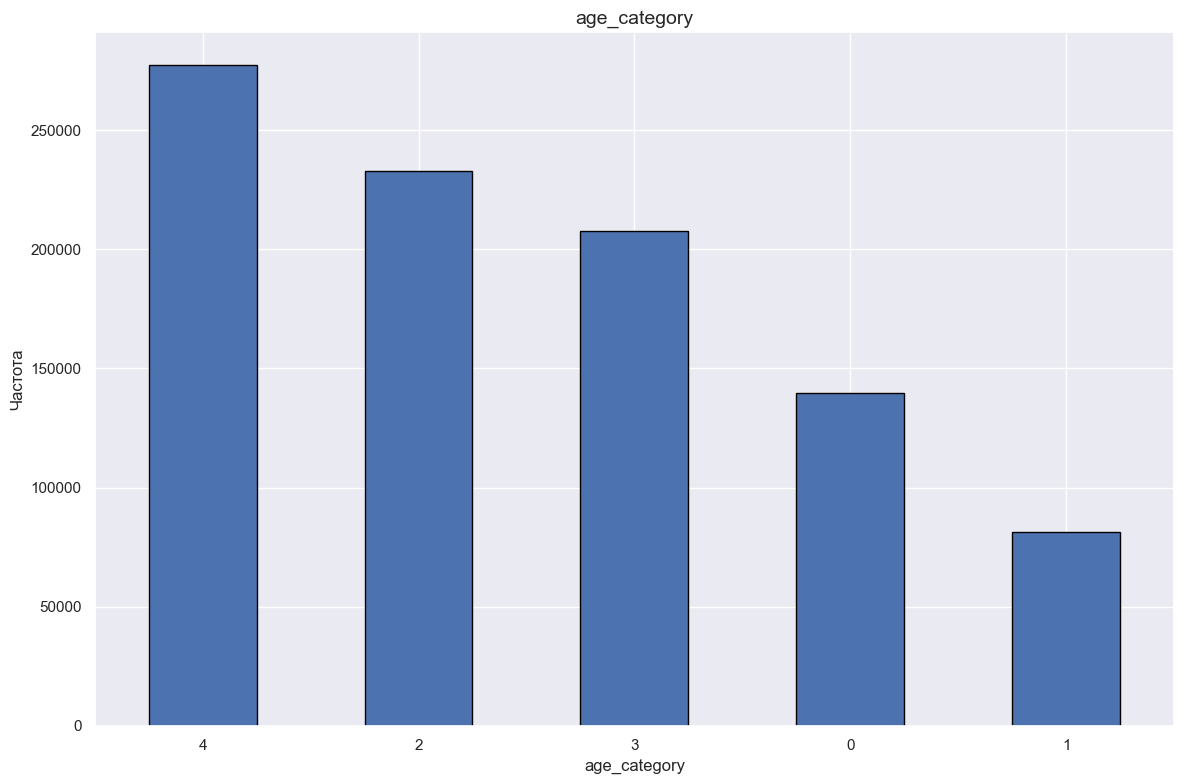

Описательные статистики для столбца  cloud_usage :
count    939148.000000
mean          0.523765
std           0.499435
min           0.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           1.000000
Name: cloud_usage, dtype: float64


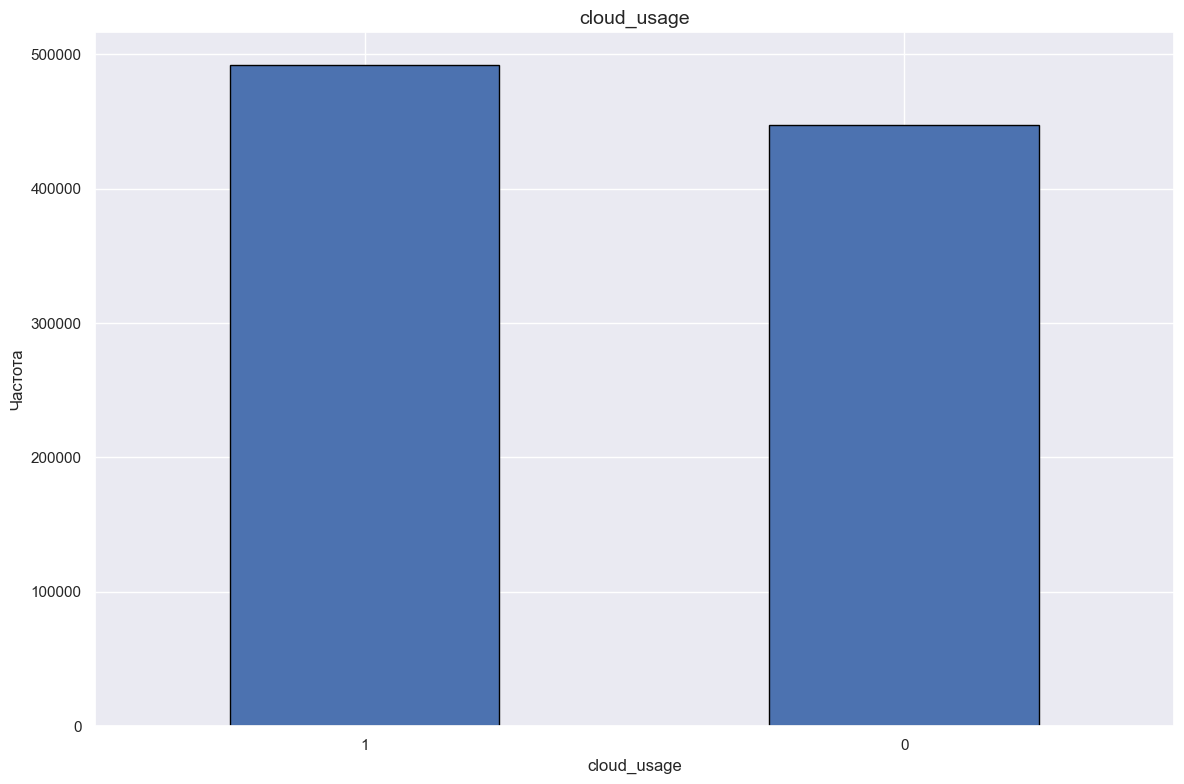

Описательные статистики для столбца  date :
count                           939148
mean     2025-11-07 11:57:30.778790400
min                2025-11-01 00:00:00
25%                2025-11-04 00:00:00
50%                2025-11-07 00:00:00
75%                2025-11-11 00:00:00
max                2025-11-14 00:00:00
Name: date, dtype: object


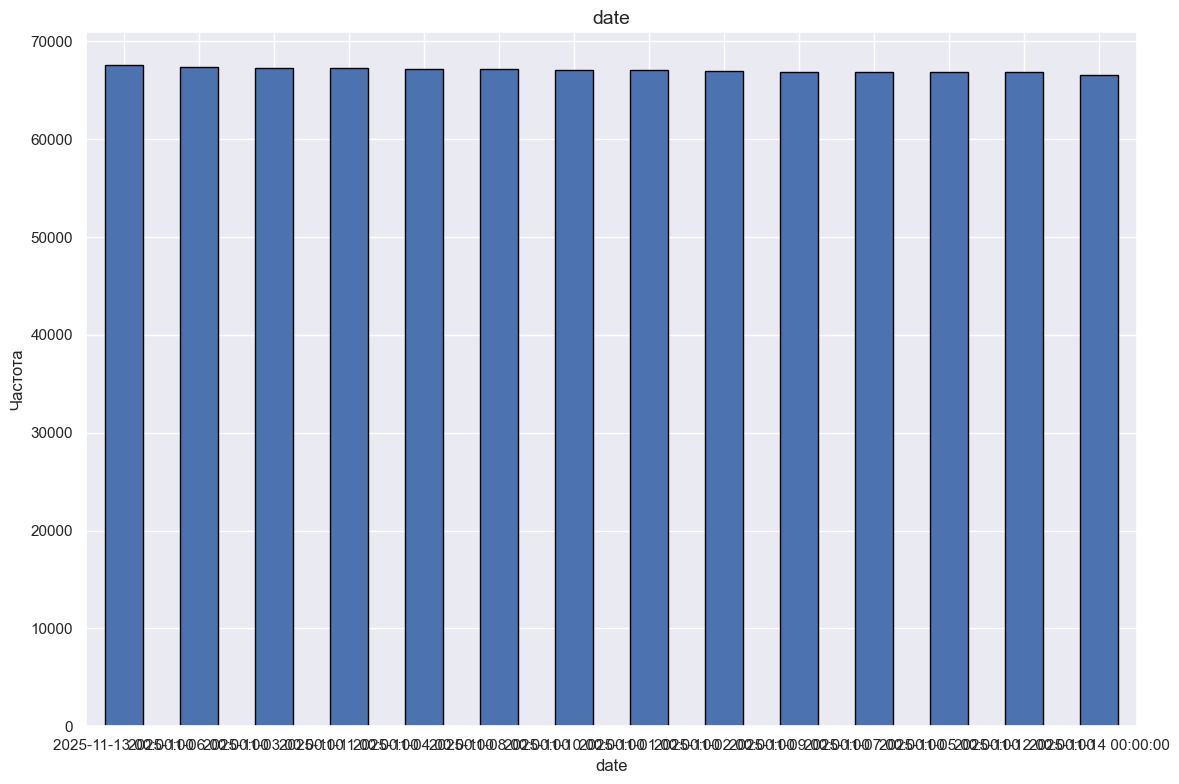

Описательные статистики для столбца  day_week :
count    939148.000000
mean          2.997647
std           1.999842
min           0.000000
25%           1.000000
50%           3.000000
75%           5.000000
max           6.000000
Name: day_week, dtype: float64


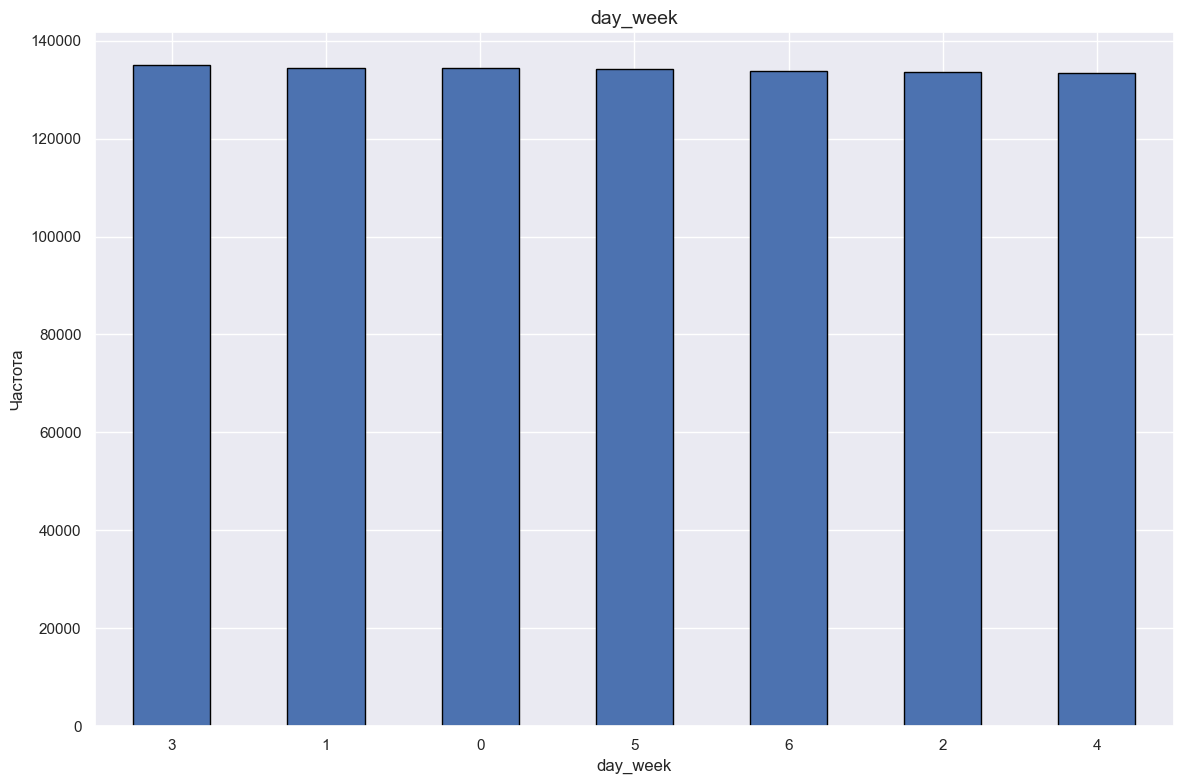

Описательные статистики для столбца  max_active_day :
count                           939148
mean     2025-11-07 11:57:30.778790400
min                2025-11-01 00:00:00
25%                2025-11-04 00:00:00
50%                2025-11-07 00:00:00
75%                2025-11-11 00:00:00
max                2025-11-14 00:00:00
Name: max_active_day, dtype: object


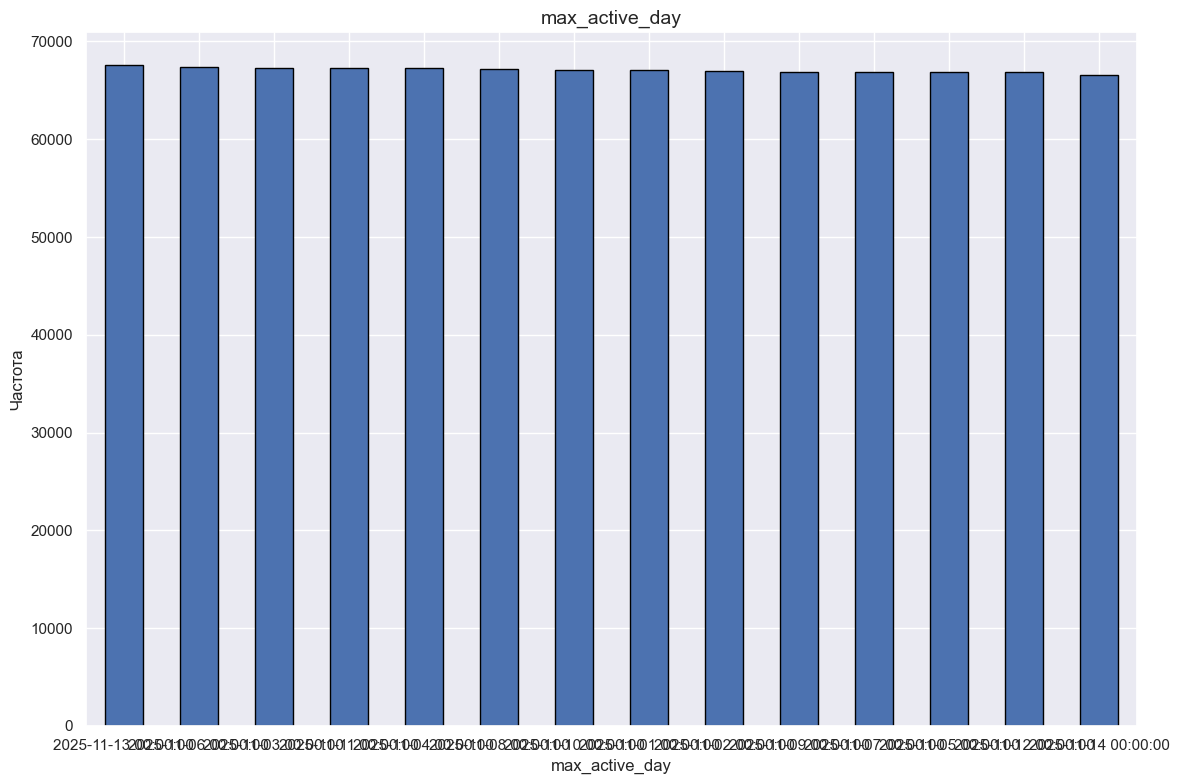

Описательные статистики для столбца  max_active_dayweek :
count    939148.000000
mean          2.997647
std           1.999842
min           0.000000
25%           1.000000
50%           3.000000
75%           5.000000
max           6.000000
Name: max_active_dayweek, dtype: float64


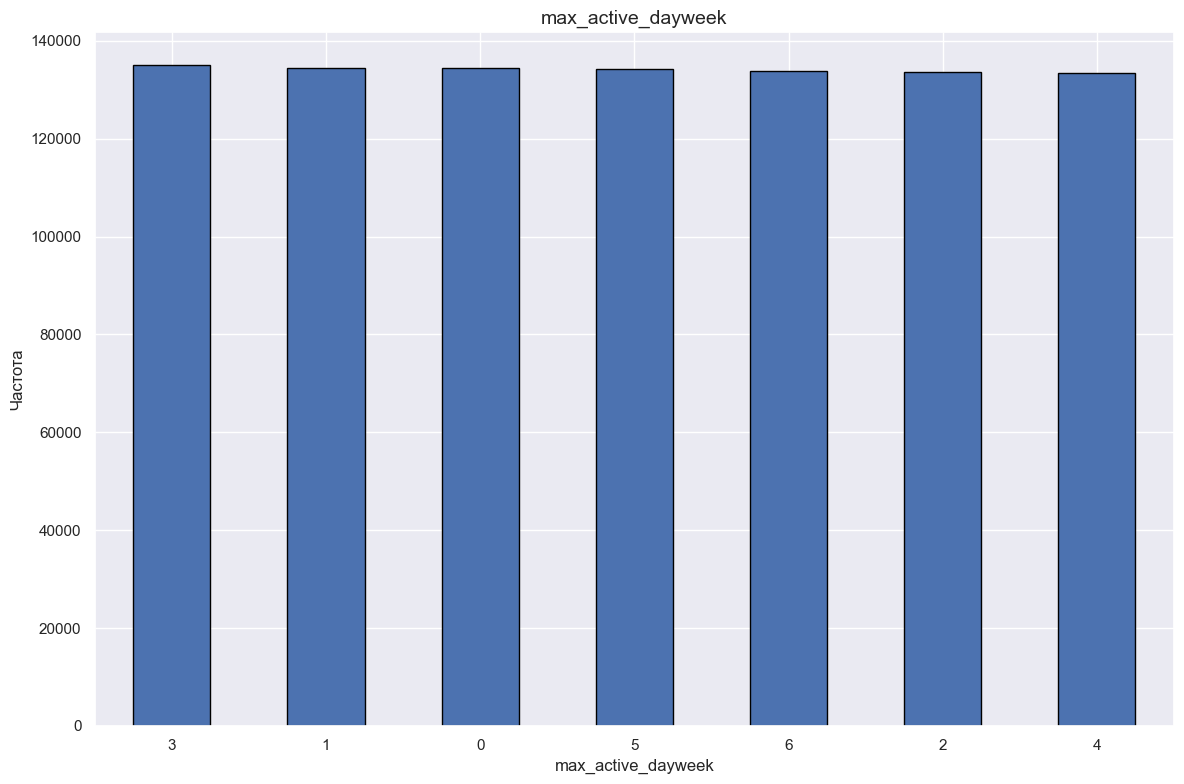

In [117]:
feature_category (df, ['age_category', 'cloud_usage', 'date', 'day_week', 'max_active_day', 'max_active_dayweek'])

**cloud_usage** - расделение почти 50/50. Тех, кто пользуется облаками 52%

*Изучим описательные статистики распределения для числовых непрерывных признаков `'share_of_visited_websites', 'share_of_daytime', 'mean_session', 'max_active_daytime', 'share_of_visited_websites', 'share_daytime',
       'mean_session', 'max_active_daytime', 'share_of_daytime_degree6',
       'share_of_user_clicks', 'share_of_user_devices',
       'relative_audience_weight', 'session_clicks_devices'`*

In [118]:
def feature_distribution (value):
    '''
    Исследует распределение признаков по столбцам:
      Считает описательные статистики
      Строит гистограммы распределения, ящики с усами по столвцам/столбцу
    
    value - столбцы/столбец
    
    '''
    BOLD = '\033[1m' 
    RESET = '\033[0m'
    
    for col in value:
        print(f'Описательные статистики для столбца {BOLD} {col} {RESET}:')  # Заголовок отдельно
        print(df[col].describe())
        sns.set_theme(style="darkgrid")
        # creating a figure composed of two matplotlib.Axes objects (ax_box and ax_hist)
        f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)})

        # assigning a graph to each ax
        sns.boxplot(data=df, x=col, orient="h", ax=ax_box)  # Явно указываем data и x
        sns.histplot(data=df, x=col, ax=ax_hist, bins=50, edgecolor='black')

        # Remove x axis name for the boxplot
        ax_box.set(xlabel='')
        plt.show()

Описательные статистики для столбца  share_of_visited_websites :
count    939148.000000
mean          0.071606
std           0.034721
min           0.002000
25%           0.048000
50%           0.067000
75%           0.089000
max           0.296000
Name: share_of_visited_websites, dtype: float64


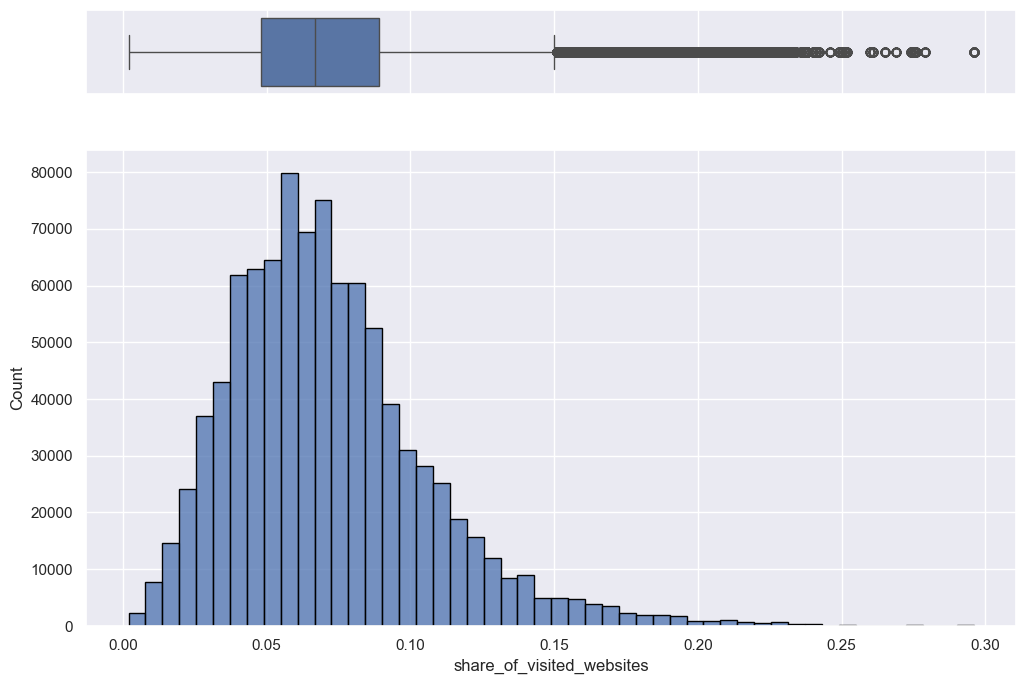

Описательные статистики для столбца  share_daytime :
count    939148.000000
mean          0.313157
std           0.101264
min           0.007874
25%           0.244444
50%           0.345455
75%           0.385593
max           0.532710
Name: share_daytime, dtype: float64


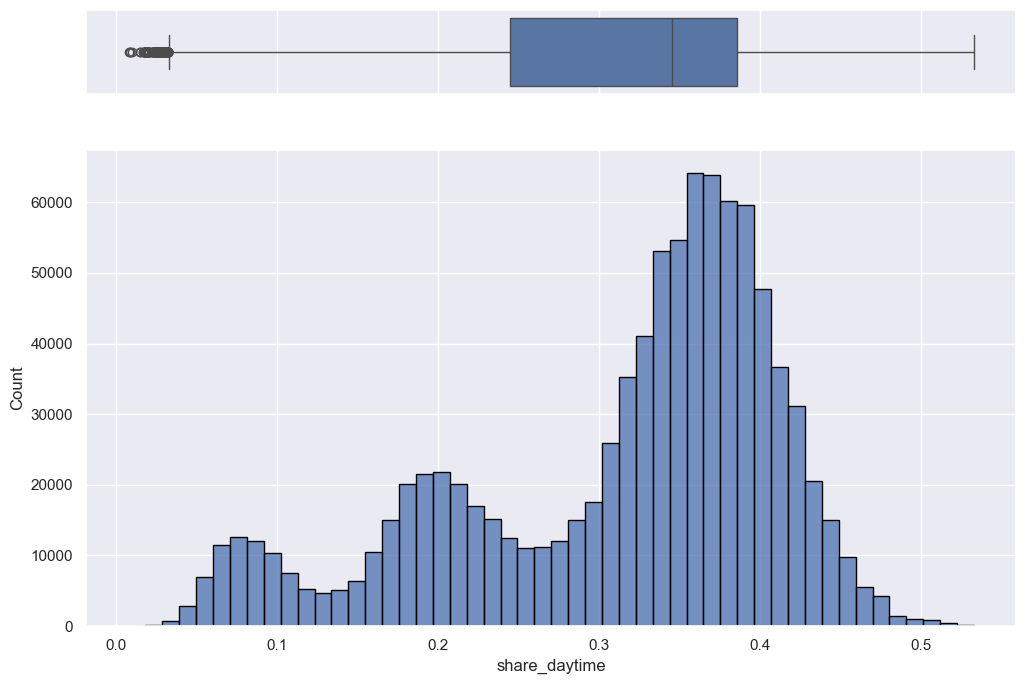

Описательные статистики для столбца  mean_session :
count    939148.000000
mean          0.076585
std           0.019199
min           0.006757
25%           0.063584
50%           0.075472
75%           0.088525
max           0.198020
Name: mean_session, dtype: float64


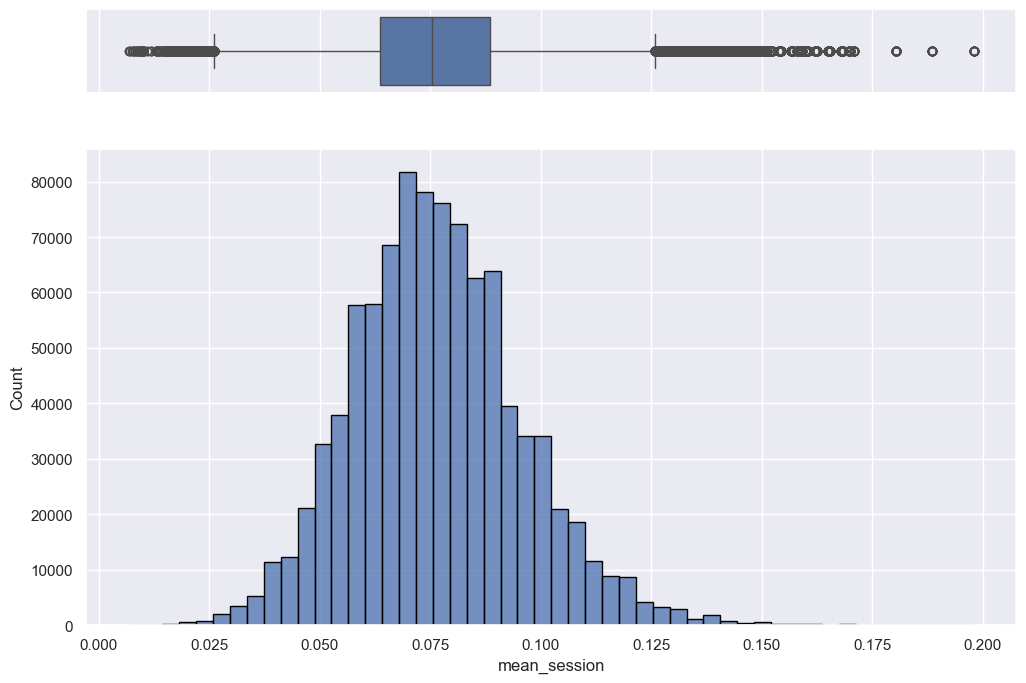

Описательные статистики для столбца  max_active_daytime :
count    939148.000000
mean         83.616965
std          38.075690
min          31.000000
25%          58.000000
50%          75.000000
75%          99.000000
max         305.000000
Name: max_active_daytime, dtype: float64


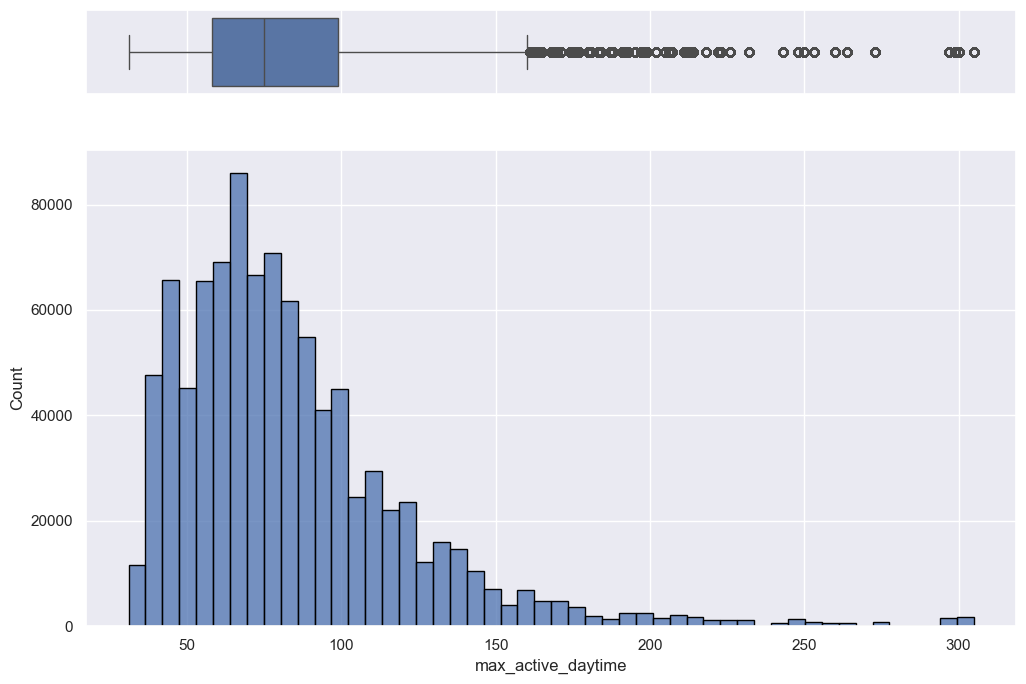

Описательные статистики для столбца  share_of_daytime_degree6 :
count    9.391480e+05
mean     2.215248e-03
std      2.325843e-03
min      2.383294e-13
25%      2.133443e-04
50%      1.699595e-03
75%      3.286823e-03
max      2.285317e-02
Name: share_of_daytime_degree6, dtype: float64


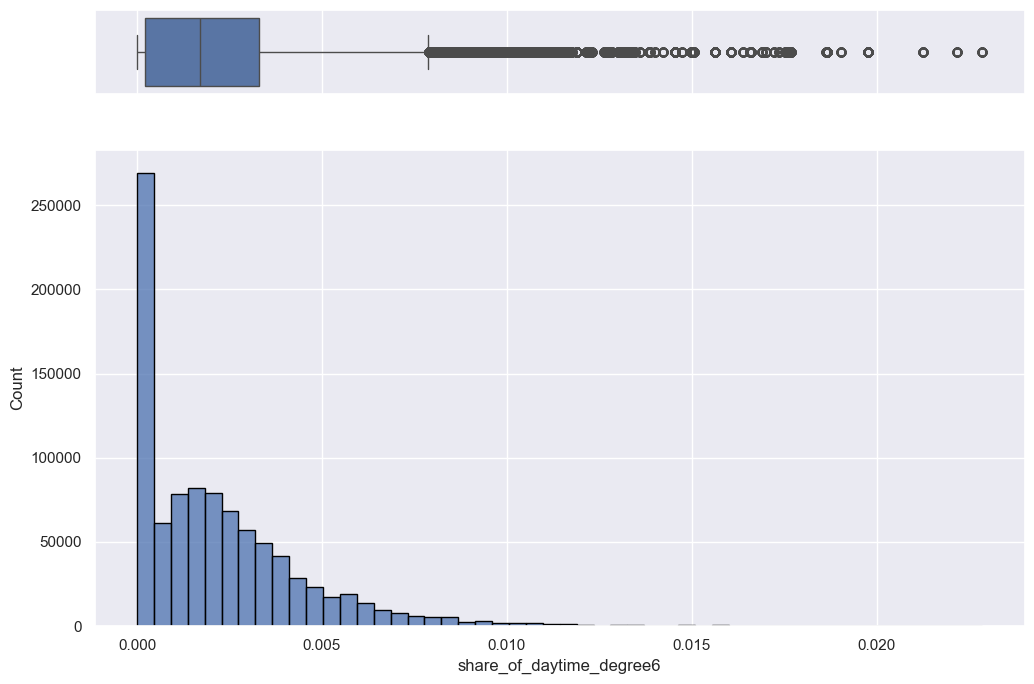

Описательные статистики для столбца  share_of_user_clicks :
count    939148.000000
mean          0.987458
std           0.784323
min           0.294027
25%           0.566839
50%           0.762656
75%           1.093518
max           5.787644
Name: share_of_user_clicks, dtype: float64


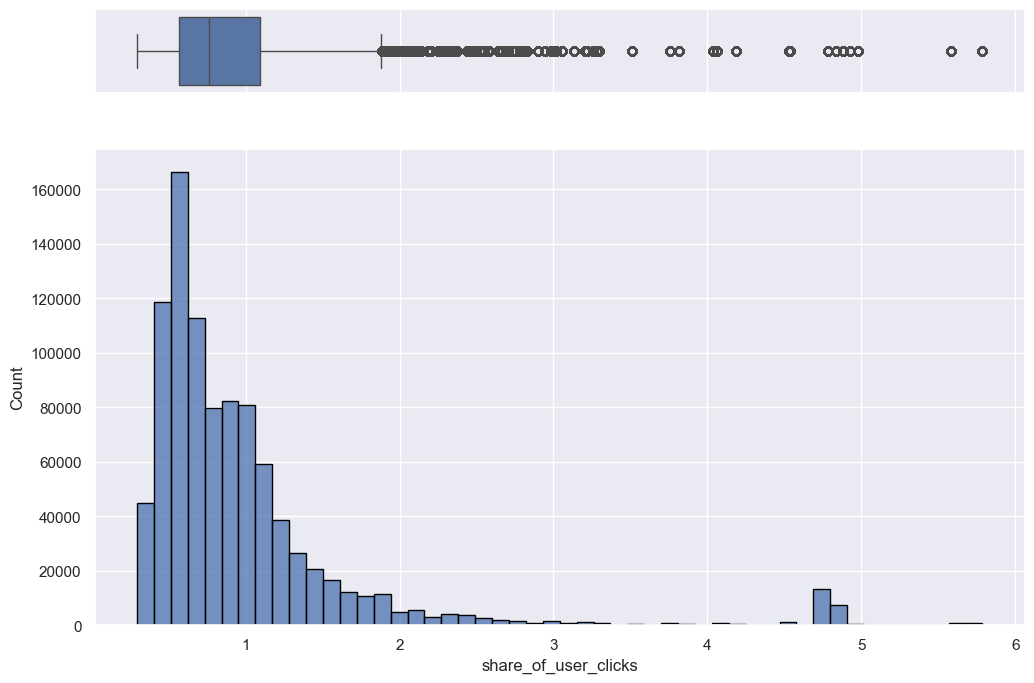

Описательные статистики для столбца  share_of_user_devices :
count    939148.000000
mean          0.901300
std           0.907947
min           0.194858
25%           0.356591
50%           0.590740
75%           1.096413
max           8.002008
Name: share_of_user_devices, dtype: float64


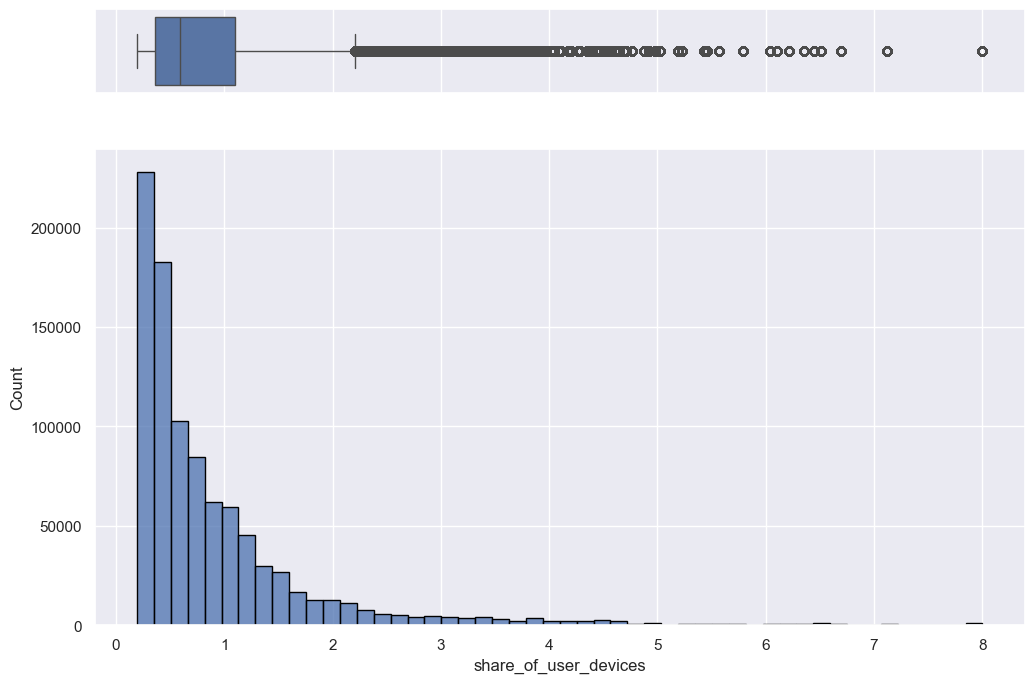

Описательные статистики для столбца  relative_audience_weight :
count    939148.000000
mean         15.039919
std          10.065107
min           1.000000
25%           8.000000
50%          13.000000
75%          19.000000
max         142.000000
Name: relative_audience_weight, dtype: float64


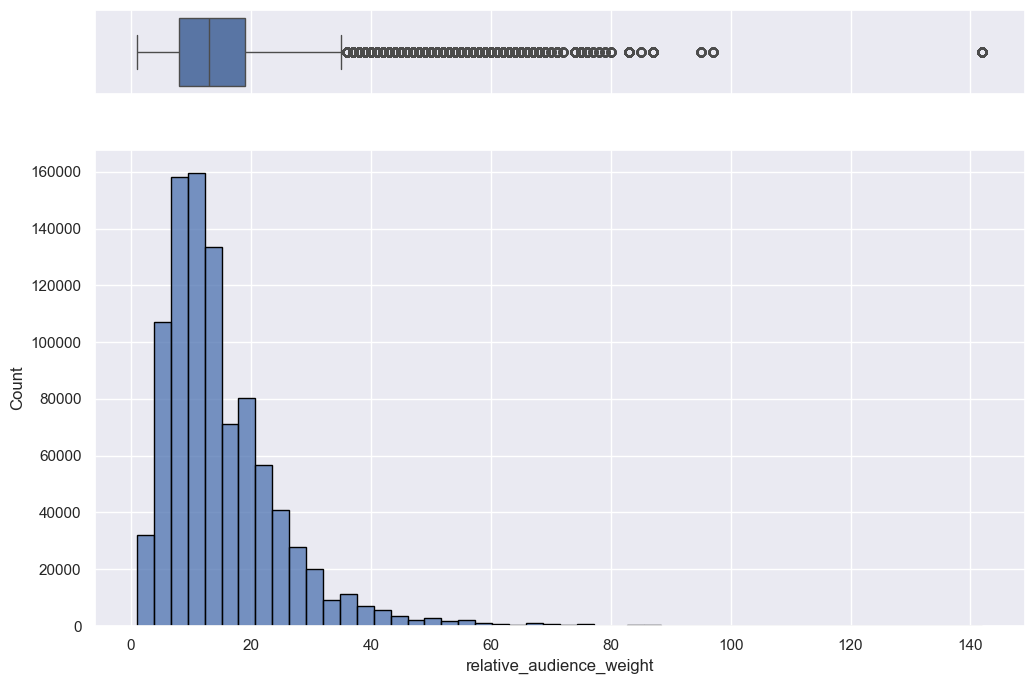

Описательные статистики для столбца  session_clicks_devices :
count    939148.000000
mean          0.073715
std           0.132928
min           0.000573
25%           0.018701
50%           0.037714
75%           0.078760
max           3.699331
Name: session_clicks_devices, dtype: float64


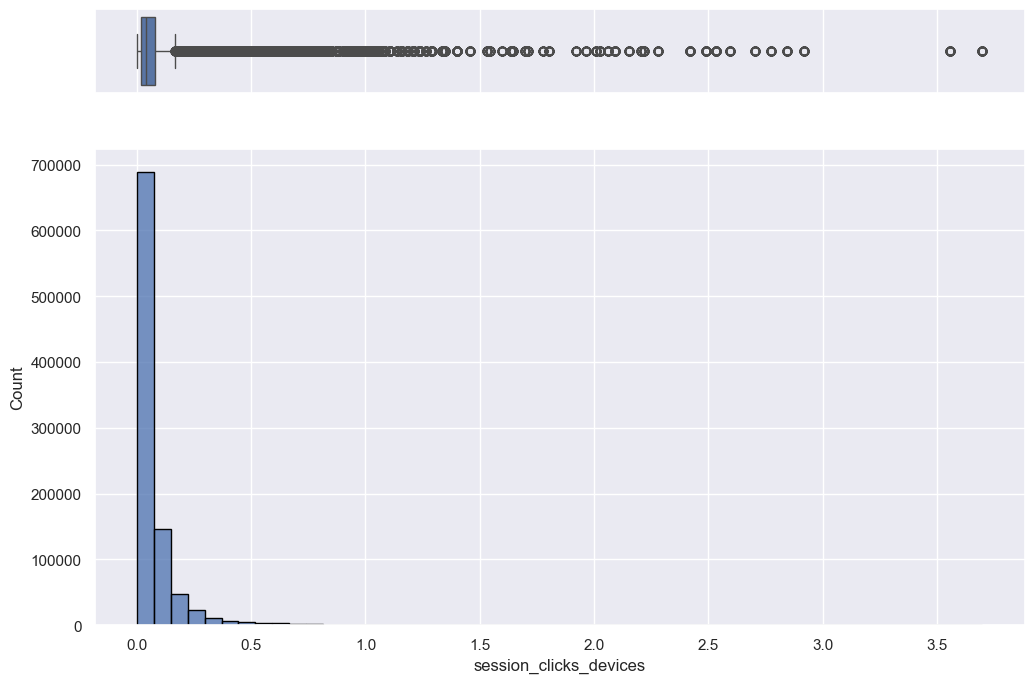

Описательные статистики для столбца  users_activity :
count    939148.000000
mean          0.023638
std           0.023193
min           0.000286
25%           0.011519
50%           0.018088
75%           0.027814
max           0.358869
Name: users_activity, dtype: float64


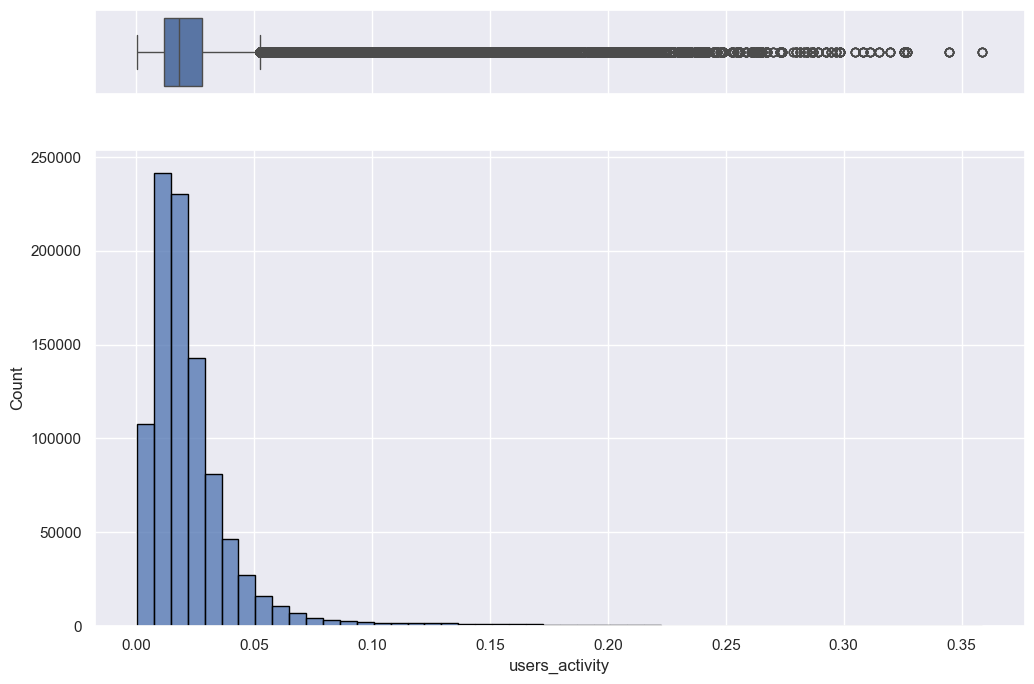

Описательные статистики для столбца  share_age_group_cloud_usage :
count    939148.000000
mean        633.537170
std         345.288849
min          59.019600
25%         373.265991
50%         566.067993
75%         845.326416
max        1664.239990
Name: share_age_group_cloud_usage, dtype: float64


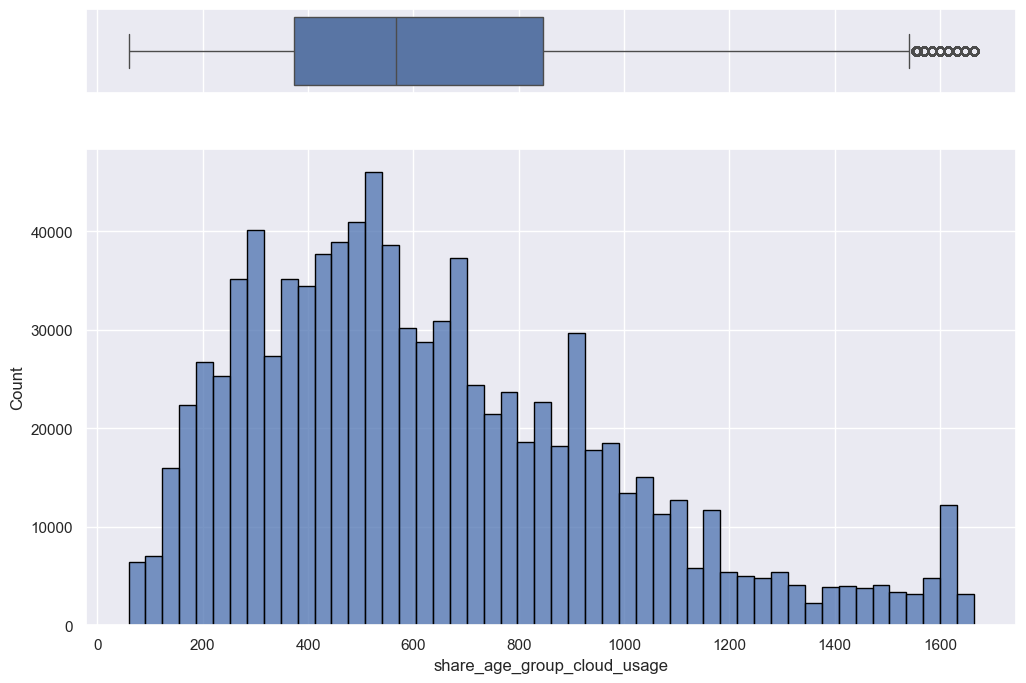

Описательные статистики для столбца  share_age_group_primary_device :
count    939148.000000
mean        450.079956
std         289.762573
min           9.768600
25%         223.510803
50%         401.260010
75%         622.184692
max        1372.449951
Name: share_age_group_primary_device, dtype: float64


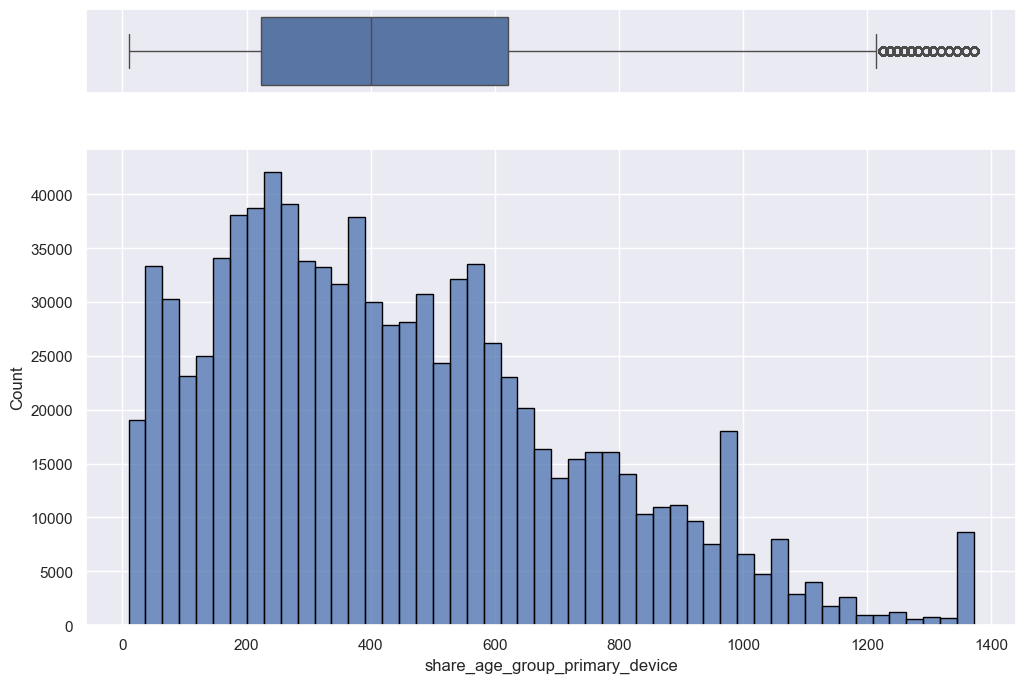

Описательные статистики для столбца  share_age_group_surf_depth :
count    939148.000000
mean        464.378387
std         268.371918
min          28.456900
25%         262.529388
50%         417.709503
75%         627.312500
max        1346.209961
Name: share_age_group_surf_depth, dtype: float64


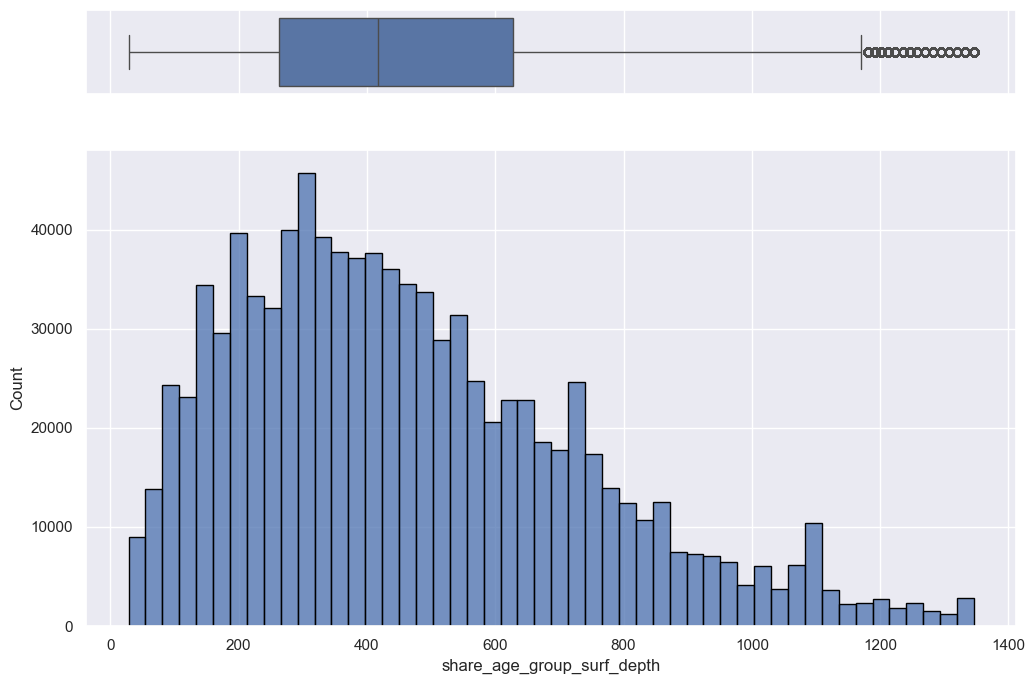

Описательные статистики для столбца  share_age_group_ads_activity :
count    939148.000000
mean        334.246338
std         188.594955
min          19.107500
25%         190.321594
50%         306.534393
75%         441.200012
max        1032.951050
Name: share_age_group_ads_activity, dtype: float64


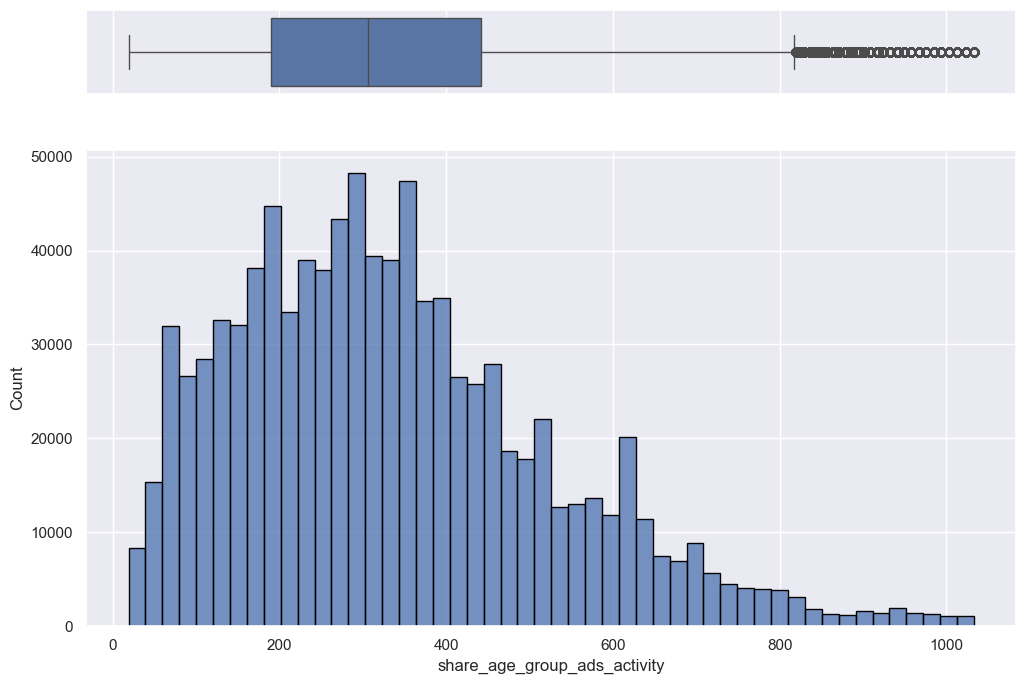

Описательные статистики для столбца  share_age_group_date :
count    939148.000000
mean         84.495857
std          40.742619
min           8.632900
25%          54.606602
50%          79.146896
75%         107.690300
max         200.729996
Name: share_age_group_date, dtype: float64


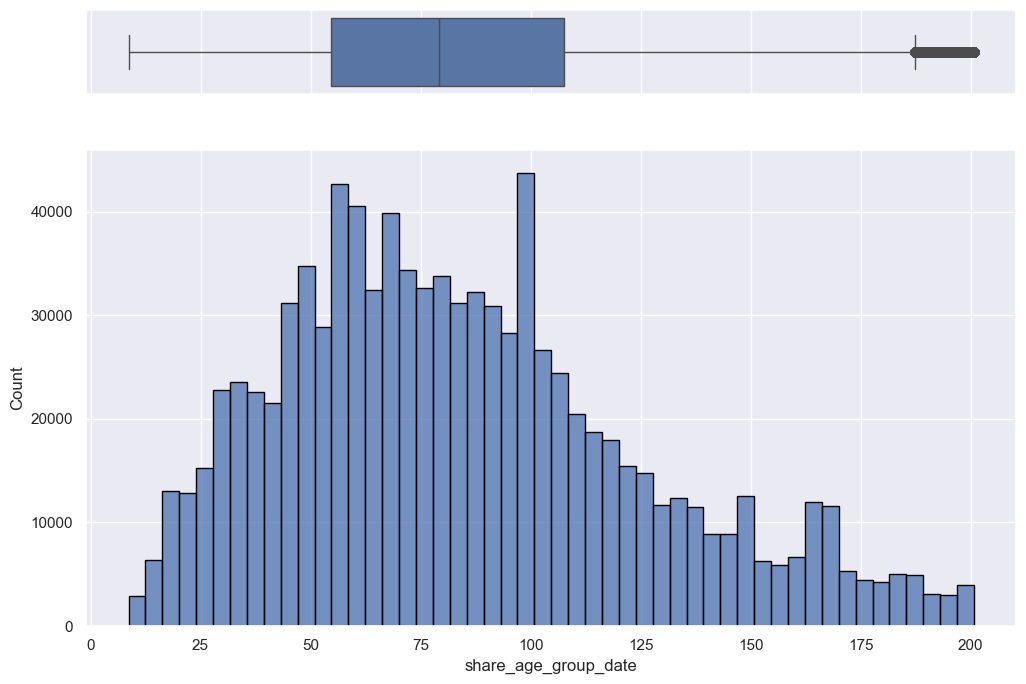

Описательные статистики для столбца  share_age_group_day_week :
count    939148.000000
mean        168.984589
std          81.475739
min          17.345600
25%         109.365303
50%         158.398102
75%         215.456497
max         400.829987
Name: share_age_group_day_week, dtype: float64


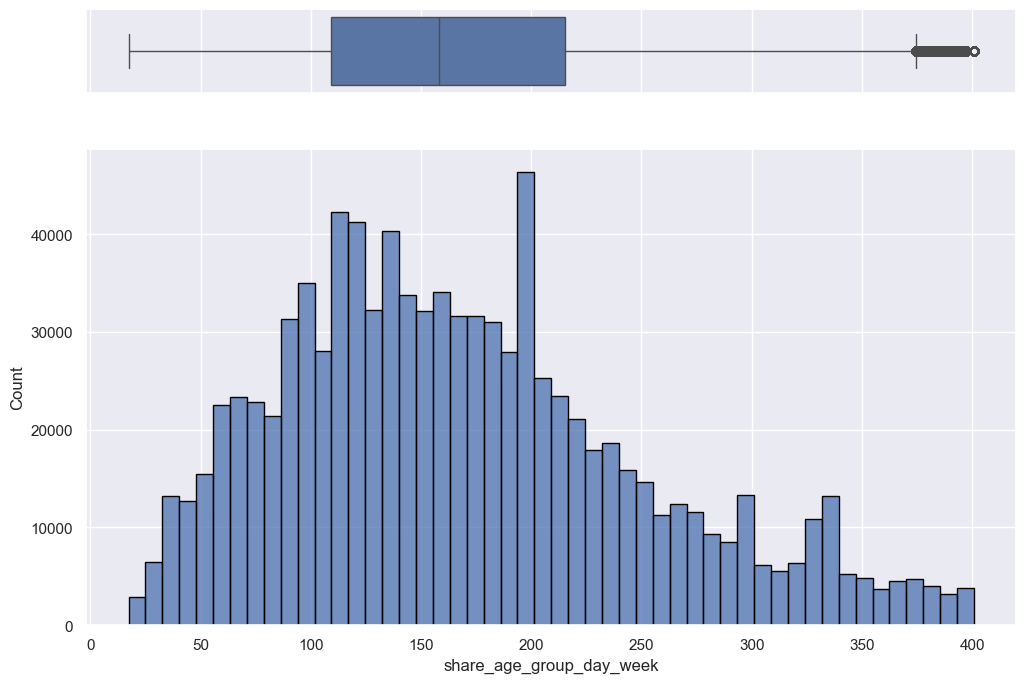

Описательные статистики для столбца  share_age_group_daytime :
count    939148.000000
mean        366.032013
std         215.016815
min          11.844900
25%         198.245300
50%         336.645905
75%         495.170593
max        1077.829956
Name: share_age_group_daytime, dtype: float64


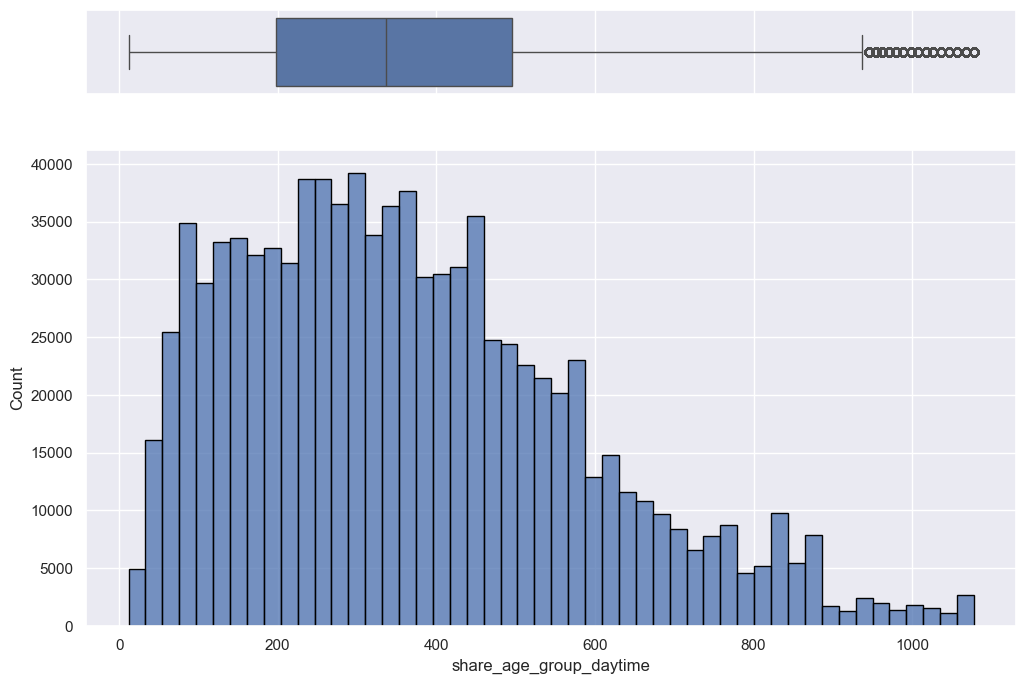

Описательные статистики для столбца  share_age_group_website_category :
count    939148.000000
mean         63.851189
std          37.537674
min           4.248800
25%          36.867001
50%          56.101200
75%          81.594101
max         278.630005
Name: share_age_group_website_category, dtype: float64


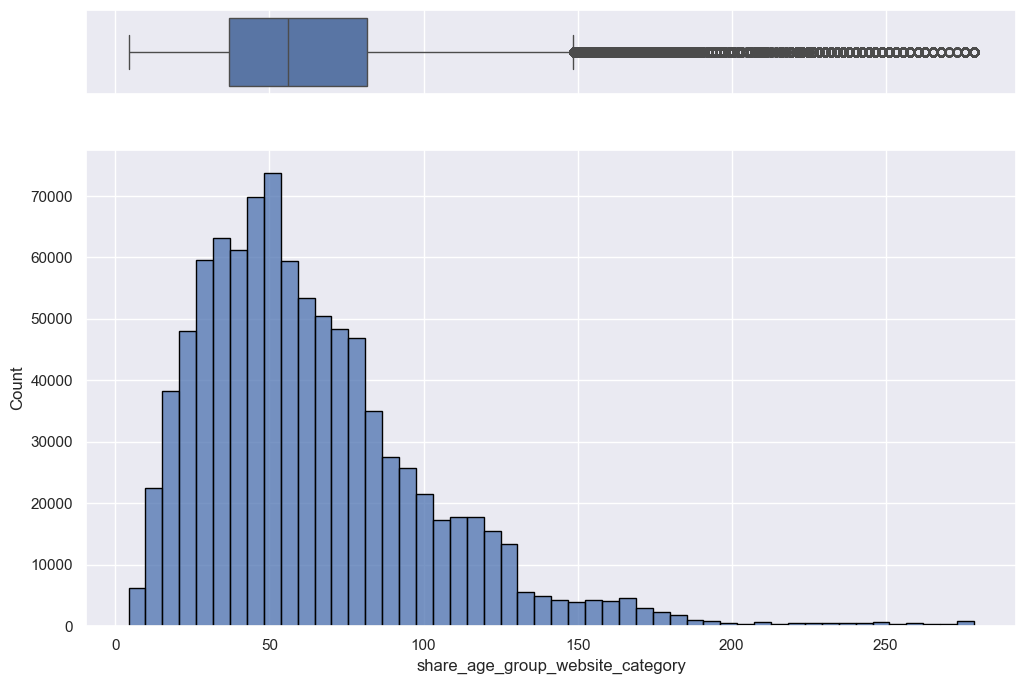

Описательные статистики для столбца  users_character :
count    939148.000000
mean         14.107759
std          11.412121
min           0.296928
25%           5.784877
50%          10.707137
75%          18.702469
max          61.256599
Name: users_character, dtype: float64


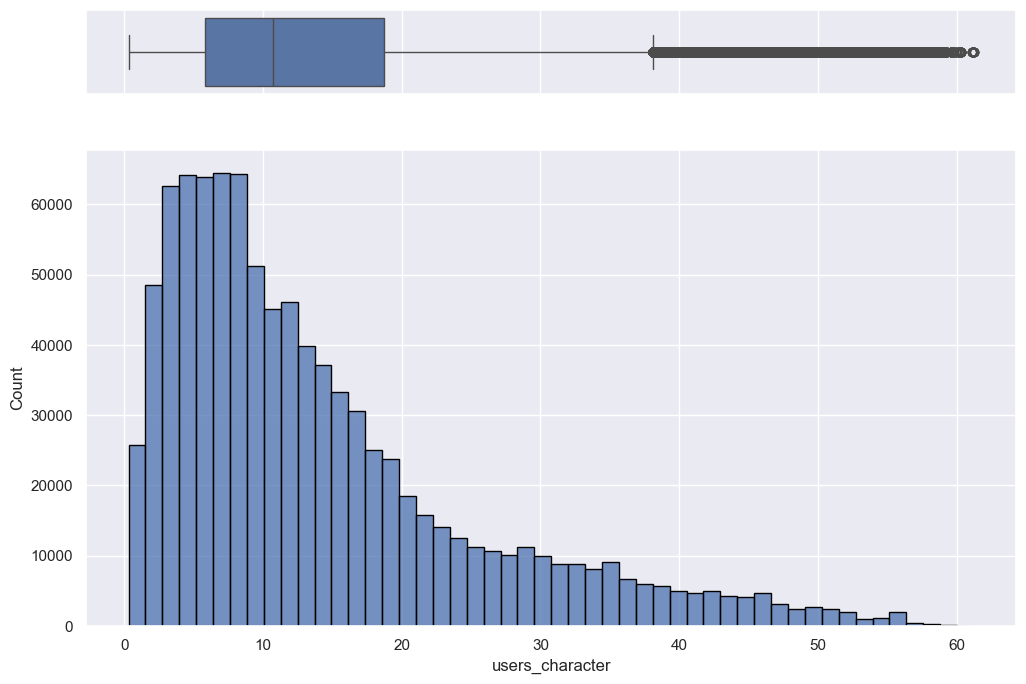

In [119]:
feature_distribution (['share_of_visited_websites', 'share_daytime',
       'mean_session', 'max_active_daytime', 'share_of_daytime_degree6',
       'share_of_user_clicks', 'share_of_user_devices',
       'relative_audience_weight', 'session_clicks_devices', 'users_activity',
        'share_age_group_cloud_usage',
       'share_age_group_primary_device', 'share_age_group_surf_depth',
       'share_age_group_ads_activity', 'share_age_group_date',
       'share_age_group_day_week', 'share_age_group_daytime',
       'share_age_group_website_category', 
       'users_character'])

**share_of_visited_websites** доля интернет-активности пользователя приходится в зависимости от посещения  разных категорий сайтов
На самые популярные категории сайтов заходит от 5% до 9% пользователей. 
Распределение нормальное, правостороннее
Есть выбросы, т.е. есть несколько особо часто посещаемых категорий сайтов

**share_daytime** распределение активности пользователя во времени в процентах
Наблюдается цикличность, разные группы пользователей посещают сайты в разное время
Распределение многовершинное, левостороннее
На пик активности в среднем приходится 34% пользователей 

**mean_session** Среднее количество сессий пользователя в день
В среднем, пользователь совершает 1,5 2 сессии в день. Редкие фанаты совершают более 7 сессий
Распределение нормальное правостороннее

**max_active_daytime** Наиболее активное время суток у пользователя
Распределение правостороннее близко к нормальному, вершина смещена в лево. 
Судя по всему у 50% пользователей действительно есть любимое время посещения. 


Выбросы есть в полях: share_of_visited_websites, mean_session, max_active_daytime и др., но все они могуб объясняться поведением людей, возмзжно это поведение свойственно какой-то определенной возрастной группе, поэтому всю информацию оставим для изучения. С неоднородностью будем босорьтя с помощью StsndardScaler 

### `age_category` - изучение целевой переменной

In [120]:
display("Уникальные значения:", df['age_category'].unique())
display("Число уникальных значений:", df['age_category'].nunique())
display("Число пропусков:", df['age_category'].isna().sum())
doly_age=round(df['age_category'].mean(), 2)
display(doly_age)
doly_age = round(df['age_category'].value_counts(normalize=True), 2)
display("","Распеделение долей пользователей по возрастным группам:", doly_age)

'Уникальные значения:'

array([0, 4, 3, 2, 1], dtype=int8)

'Число уникальных значений:'

5

'Число пропусков:'

np.int64(0)

np.float64(2.43)

''

'Распеделение долей пользователей по возрастным группам:'

age_category
4    0.30
2    0.25
3    0.22
0    0.15
1    0.09
Name: proportion, dtype: float64

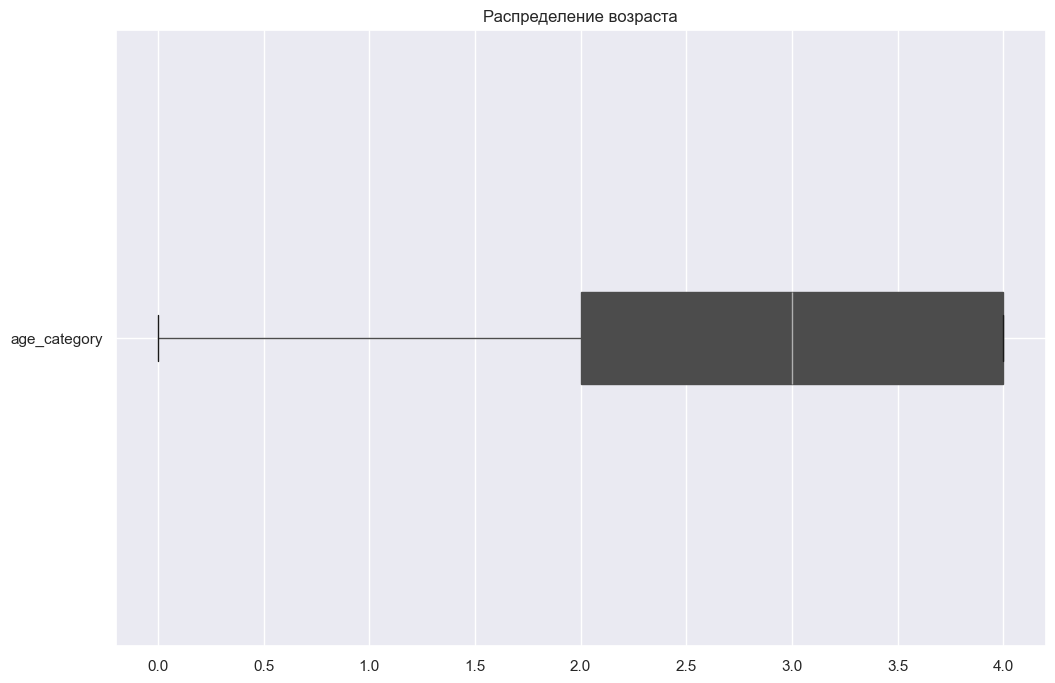

In [121]:
plt.figure(figsize=(12, 8))
df.boxplot(column=['age_category'], grid=True, patch_artist=True, vert=False)
plt.title('Распределение возраста')
plt.show()


**вывод по age_category:**

- 50% пользователей - это люди от 26 и старше 56 лет (категории 2, 3, 4). Медиана 3, чуть выше среднего 2,47, большие значения сосредоточены в левой части распределения. 
- 5 групп возрастов.
- Более менее равномерное распределение категори. Наблюдается небольшой дисбаланс, особенно для групп 1 (9%) и группы 0 (15%). Для остальных групп (2, 3, 4) разделение более равномерное (от22% до 30%).
- Выбросов нет

Из датафрейма **df** удалим поля идентификатор: `session_id`

In [122]:
df=df.drop(columns=['session_id'])

In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 939148 entries, 0 to 939147
Data columns (total 31 columns):
 #   Column                            Non-Null Count   Dtype         
---  ------                            --------------   -----         
 0   user_id                           939148 non-null  object        
 1   age_category                      939148 non-null  int8          
 2   cloud_usage                       939148 non-null  int8          
 3   ads_activity                      939148 non-null  object        
 4   primary_device                    939148 non-null  object        
 5   surf_depth                        939148 non-null  object        
 6   date                              939148 non-null  datetime64[ns]
 7   daytime                           939148 non-null  object        
 8   website_category                  939148 non-null  object        
 9   share_of_visited_websites         939148 non-null  float32       
 10  share_daytime                   

В итоговом датафрейме **df** **31** столбец, **939148** записей

### Корреляции

Выявим корреляции между целевой переменной и признаками, а ткаже между признаками

In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 939148 entries, 0 to 939147
Data columns (total 31 columns):
 #   Column                            Non-Null Count   Dtype         
---  ------                            --------------   -----         
 0   user_id                           939148 non-null  object        
 1   age_category                      939148 non-null  int8          
 2   cloud_usage                       939148 non-null  int8          
 3   ads_activity                      939148 non-null  object        
 4   primary_device                    939148 non-null  object        
 5   surf_depth                        939148 non-null  object        
 6   date                              939148 non-null  datetime64[ns]
 7   daytime                           939148 non-null  object        
 8   website_category                  939148 non-null  object        
 9   share_of_visited_websites         939148 non-null  float32       
 10  share_daytime                   

In [125]:
df.columns

Index(['user_id', 'age_category', 'cloud_usage', 'ads_activity',
       'primary_device', 'surf_depth', 'date', 'daytime', 'website_category',
       'share_of_visited_websites', 'share_daytime', 'mean_session',
       'max_active_daytime', 'share_of_daytime_degree6',
       'share_of_user_clicks', 'share_of_user_devices',
       'relative_audience_weight', 'session_clicks_devices', 'users_activity',
       'day_week', 'share_age_group_cloud_usage',
       'share_age_group_primary_device', 'share_age_group_surf_depth',
       'share_age_group_ads_activity', 'share_age_group_date',
       'share_age_group_day_week', 'share_age_group_daytime',
       'share_age_group_website_category', 'max_active_day',
       'max_active_dayweek', 'users_character'],
      dtype='object')

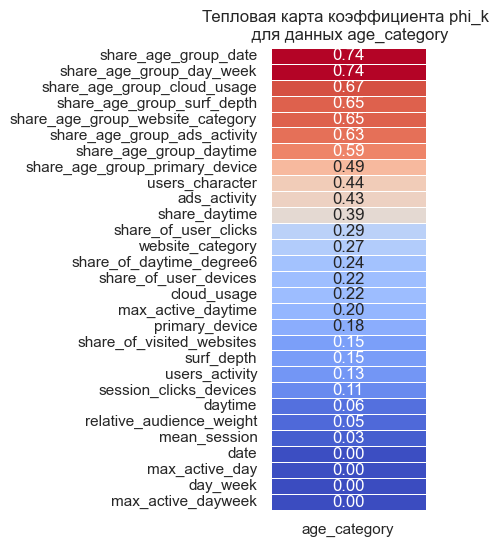

In [126]:
def correl_matrix_column(value, col):
    '''
    Строит тепловую карту по корреляционной матрицы для заданной переменной 
    value - столбцы/столбец
    col- столбец, для которого выводят коэффициенты корреляции
    interval_cols - список непрерывных признаков
    При использовании phik крайне важно настроить параметр interval_cols, передав ему список с 
    названиями непрерывных признаков: если этого не сделать, библиотека своими силами будет 
    пытаться разнести признаки по типам, и она часто делает в этом ошибки - от этого в свою очередь 
    мы получаем некорректную оценку корреляций, так как от типа признака зависит метод оценки корреляции.
    '''
    continuous_features = ['share_of_visited_websites', 'share_daytime', 'mean_session',
       'max_active_daytime', 'share_of_daytime_degree6',
       'share_of_user_clicks', 'share_of_user_devices',
       'relative_audience_weight', 'session_clicks_devices', 'users_activity',
       'day_week', 'share_age_group_cloud_usage',
       'share_age_group_primary_device', 'share_age_group_surf_depth',
       'share_age_group_ads_activity', 'share_age_group_date',
       'share_age_group_day_week', 'share_age_group_daytime',
       'share_age_group_website_category', 
       'max_active_dayweek', 'users_character']
    
    correlation_matrix = df[value].phik_matrix(interval_cols=continuous_features)
    
    
    plt.figure(figsize=(2, 6))
    correlation_matrix.loc[correlation_matrix.index != col][[col]].sort_values(by=col, ascending=False)
     
    data_heatmap = correlation_matrix.loc[correlation_matrix.index != col][[col]].sort_values(by=col, ascending=False)
    sns.heatmap(data_heatmap,
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            linewidths=0.5, 
            cbar=False 
           )
    plt.title(f'Тепловая карта коэффициента phi_k \n для данных {col}')
    plt.show()
    


correl_matrix_column(['age_category', 'cloud_usage', 'ads_activity',
       'primary_device', 'surf_depth', 'date', 'daytime', 'website_category',
       'share_of_visited_websites', 'share_daytime', 'mean_session',
       'max_active_daytime', 'share_of_daytime_degree6',
       'share_of_user_clicks', 'share_of_user_devices',
       'relative_audience_weight', 'session_clicks_devices', 'users_activity',
       'day_week', 'share_age_group_cloud_usage',
       'share_age_group_primary_device', 'share_age_group_surf_depth',
       'share_age_group_ads_activity', 'share_age_group_date',
       'share_age_group_day_week', 'share_age_group_daytime',
       'share_age_group_website_category', 'max_active_day',
       'max_active_dayweek', 'users_character'], 'age_category')

С целевой переменной `age_category` наиболее сильные взаимосвязи с ads_activity и share_of_daytime: 0.43 и 0.39. Также обнаружены связи послабее с полями: website_category(0.27), cloud_usage (0.22), max_active_daytime (0.19), primary_device (0.18), share_of_visited_websites (0.15), surf_depth (0.15) и mean_session (0.10).


In [127]:
df.columns

Index(['user_id', 'age_category', 'cloud_usage', 'ads_activity',
       'primary_device', 'surf_depth', 'date', 'daytime', 'website_category',
       'share_of_visited_websites', 'share_daytime', 'mean_session',
       'max_active_daytime', 'share_of_daytime_degree6',
       'share_of_user_clicks', 'share_of_user_devices',
       'relative_audience_weight', 'session_clicks_devices', 'users_activity',
       'day_week', 'share_age_group_cloud_usage',
       'share_age_group_primary_device', 'share_age_group_surf_depth',
       'share_age_group_ads_activity', 'share_age_group_date',
       'share_age_group_day_week', 'share_age_group_daytime',
       'share_age_group_website_category', 'max_active_day',
       'max_active_dayweek', 'users_character'],
      dtype='object')

Построим **тепловую карту взаимосвязей между всеми признаками**

<function matplotlib.pyplot.show(close=None, block=None)>

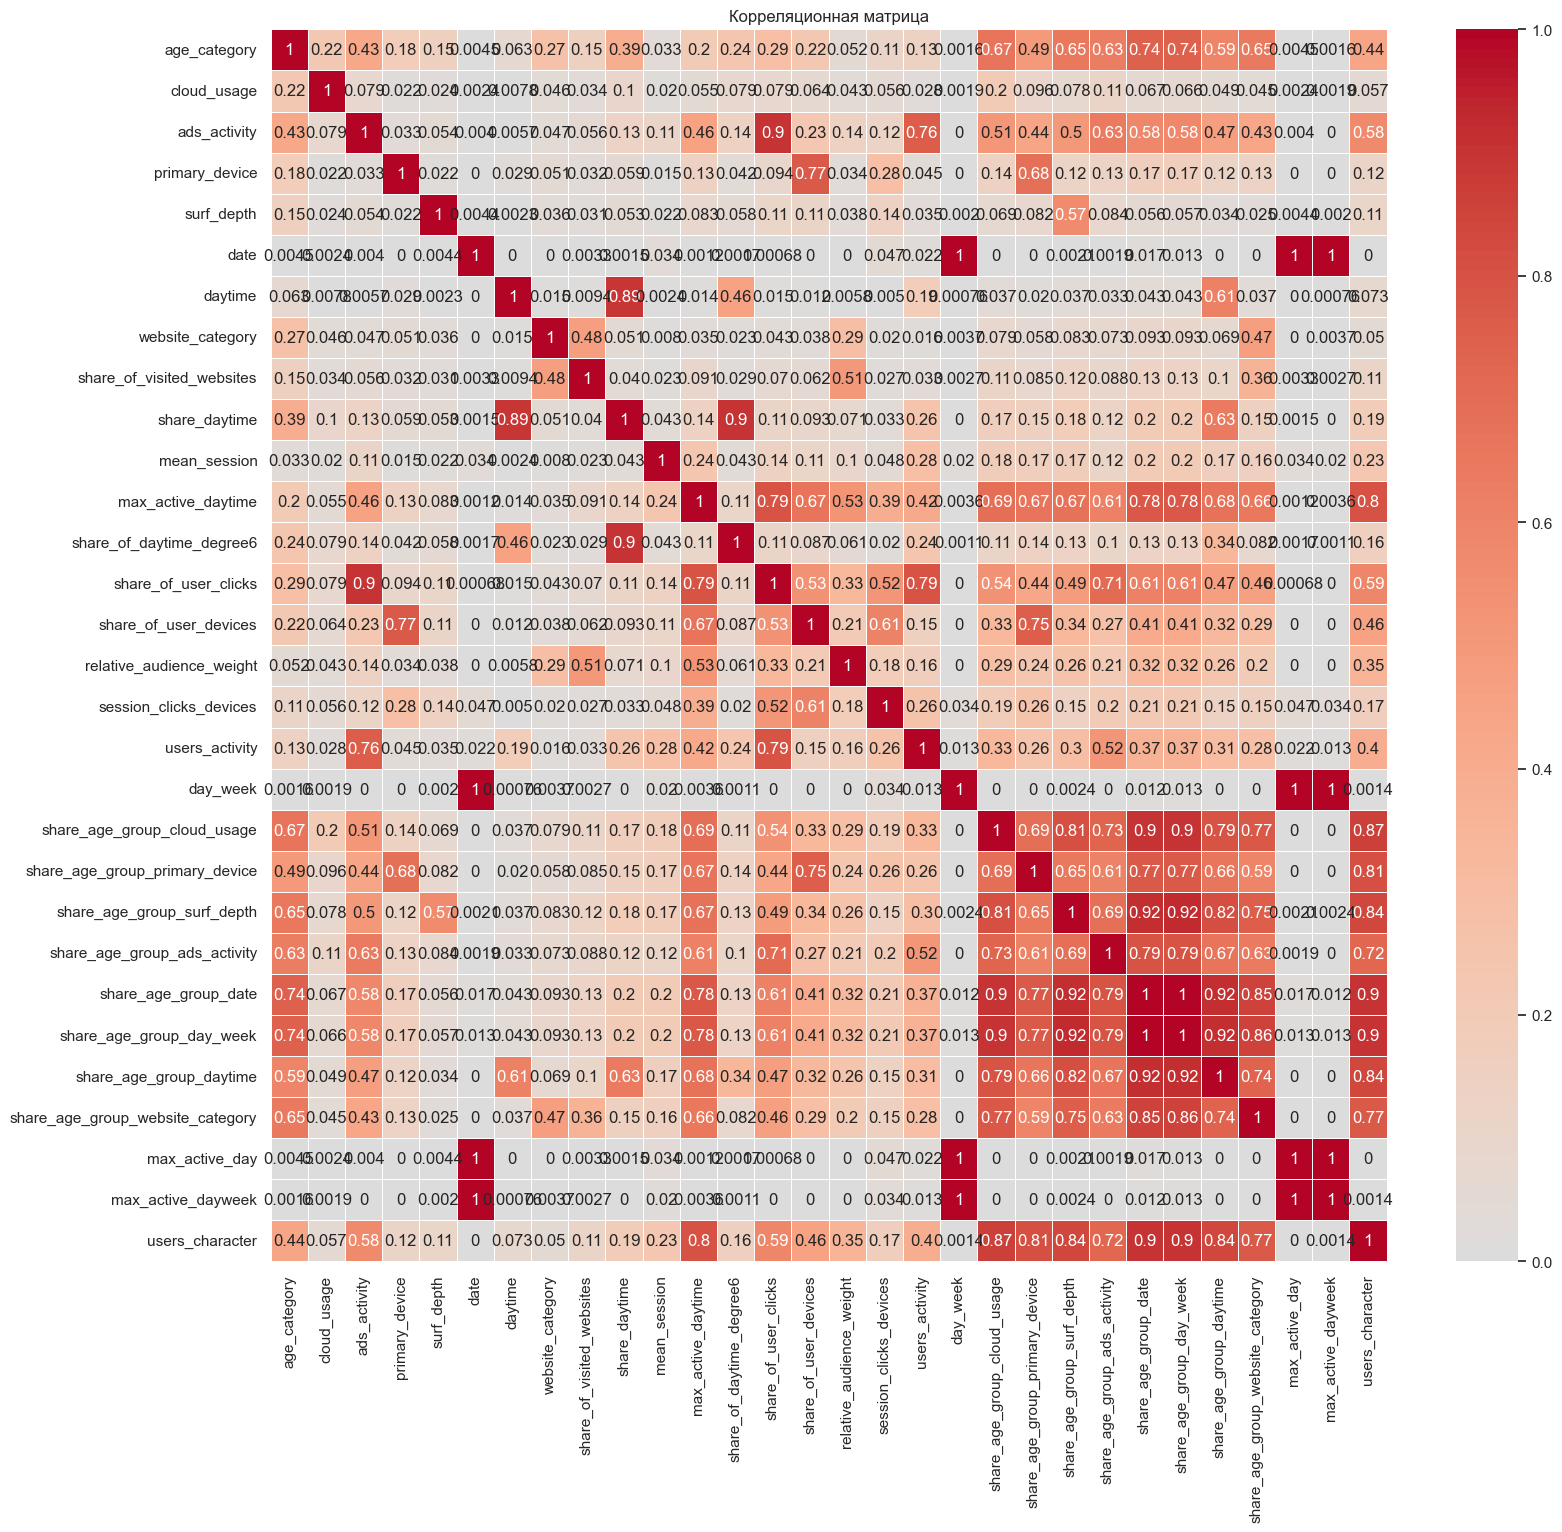

In [128]:
columns_for_analiz=['age_category', 'cloud_usage', 'ads_activity',
       'primary_device', 'surf_depth', 'date', 'daytime', 'website_category',
       'share_of_visited_websites', 'share_daytime', 'mean_session',
       'max_active_daytime', 'share_of_daytime_degree6',
       'share_of_user_clicks', 'share_of_user_devices',
       'relative_audience_weight', 'session_clicks_devices', 'users_activity',
       'day_week', 'share_age_group_cloud_usage',
       'share_age_group_primary_device', 'share_age_group_surf_depth',
       'share_age_group_ads_activity', 'share_age_group_date',
       'share_age_group_day_week', 'share_age_group_daytime',
       'share_age_group_website_category', 'max_active_day',
       'max_active_dayweek', 'users_character'
]

continuous_features =['share_of_visited_websites', 'share_daytime', 'mean_session',
       'max_active_daytime', 'share_of_daytime_degree6',
       'share_of_user_clicks', 'share_of_user_devices',
       'relative_audience_weight', 'session_clicks_devices', 'users_activity',
       'day_week', 'share_age_group_cloud_usage',
       'share_age_group_primary_device', 'share_age_group_surf_depth',
       'share_age_group_ads_activity', 'share_age_group_date',
       'share_age_group_day_week', 'share_age_group_daytime',
       'share_age_group_website_category', 
       'max_active_dayweek', 'users_character'
]
correlation_matrix=df[columns_for_analiz].phik_matrix(interval_cols=continuous_features)
plt.figure(figsize=(18, 16))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Корреляционная матрица')
plt.show

Обнаружили **мультиколинеарность**, с коэффициентом **0.89**, между признаками: 
- share_daytime и daytime
- mean_session и max_active_daytime

Обнаружили **мультиколинеарность**, с коэффициентом **0.9**, между признаками: 
- share_of_daytime_degree6 и share_daytime
- share_of_user_clicks и ads_activity


Чтобы убрать колинеарность удалим из датафрейма признаки: `'share_of_user_clicks', 'mean_session', 'date', 'daytime', 'max_active_day', 'max_active_dayweek', 'share_daytime', 'share_age_group_cloud_usage', 
'share_age_group_surf_depth', 'share_age_group_date', 'share_age_group_day_week'`

Также удалим `date, 'day_week', max_active_day', 'max_active_dayweek`, как с нулевой корреляцией                  

In [129]:
df=df.drop(columns=['share_of_user_clicks', 'mean_session', 'date', 'daytime', 'max_active_day', 'max_active_dayweek',
                   'share_daytime', 'share_age_group_cloud_usage', 
                    'share_age_group_surf_depth', 'share_age_group_date',
                   'share_age_group_day_week',
                   'day_week'])

<function matplotlib.pyplot.show(close=None, block=None)>

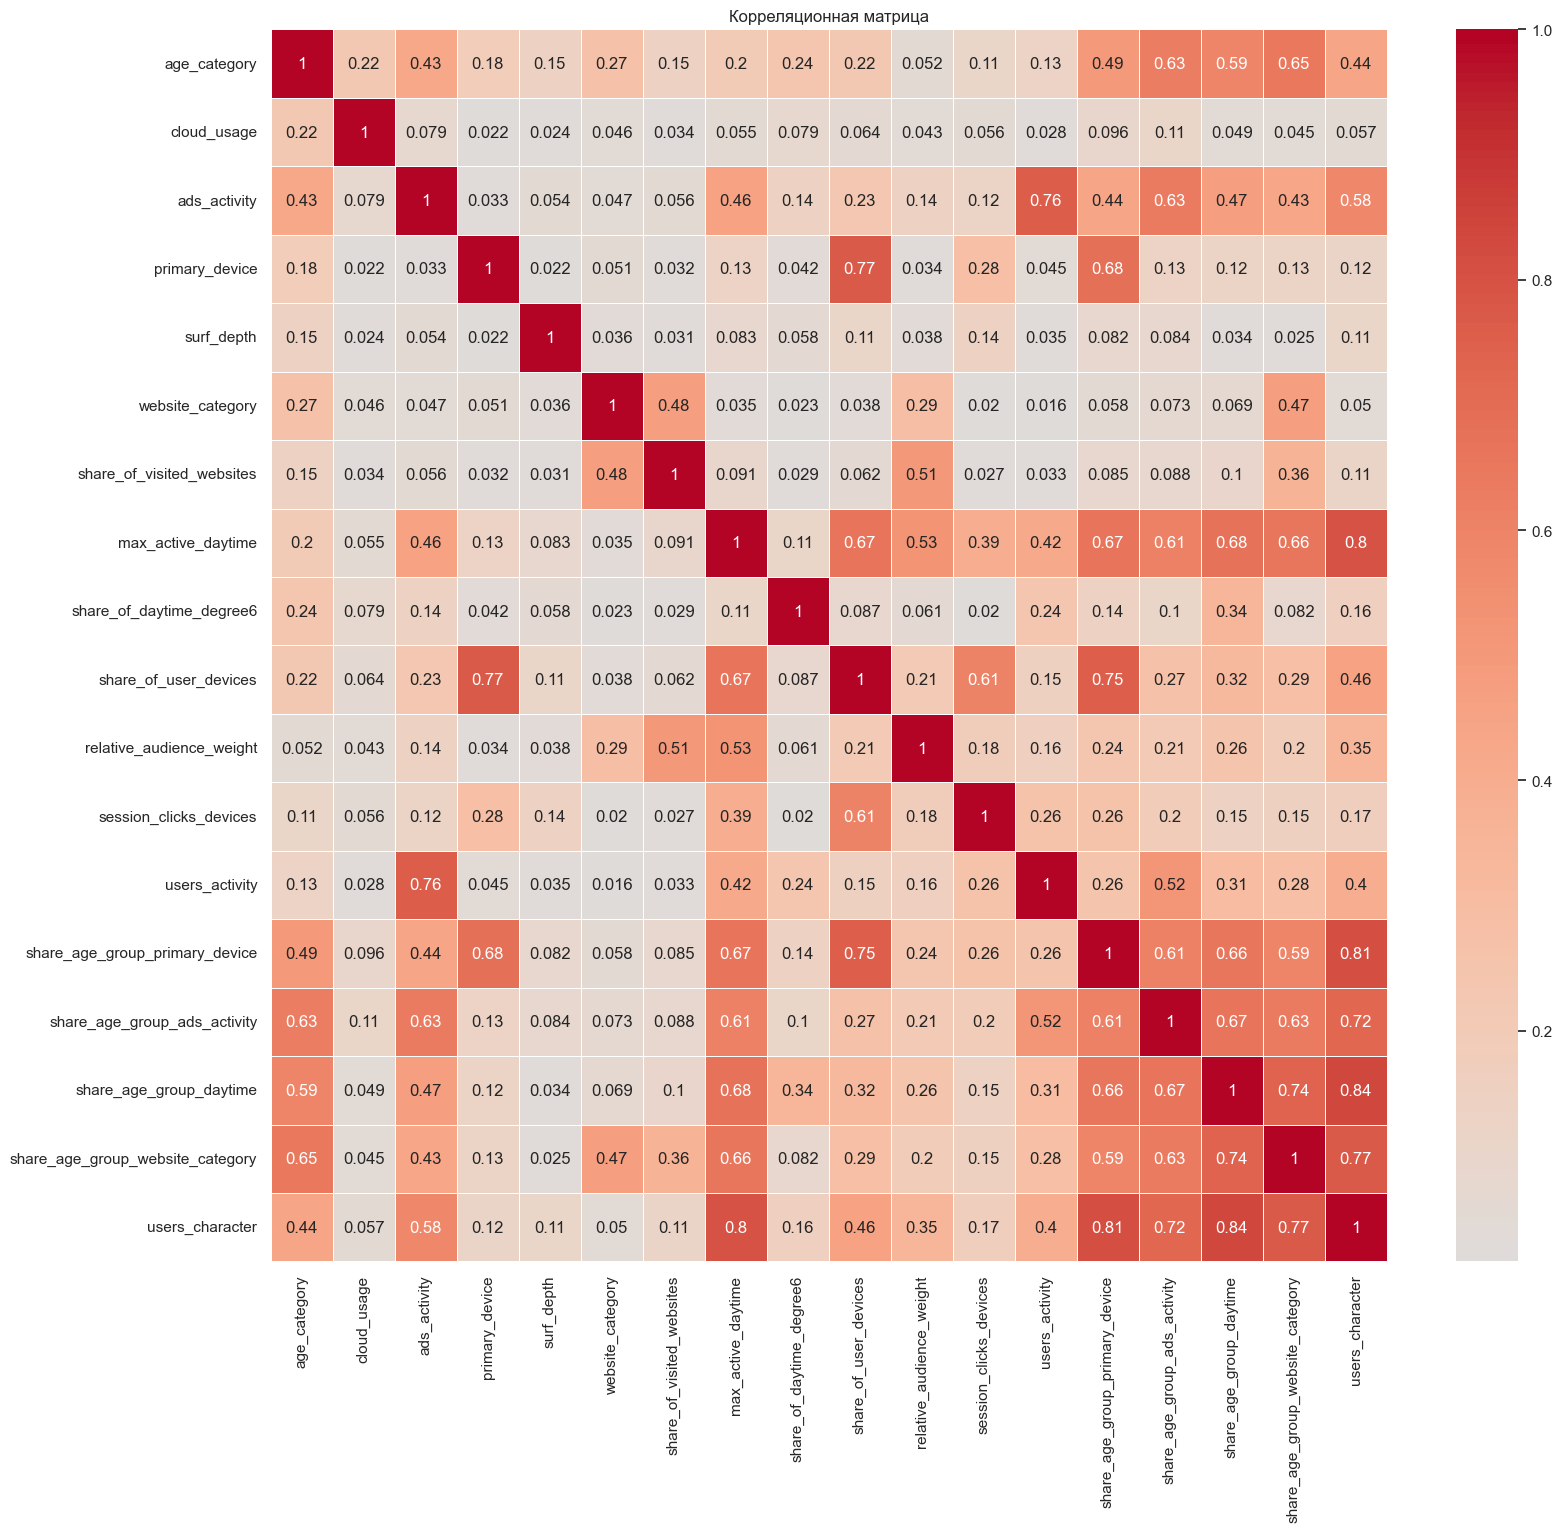

In [130]:
columns_for_analiz=['age_category', 'cloud_usage', 'ads_activity',
       'primary_device', 'surf_depth', 'website_category',
       'share_of_visited_websites', 
       'max_active_daytime', 'share_of_daytime_degree6',
       'share_of_user_devices',
       'relative_audience_weight', 'session_clicks_devices', 'users_activity',
       'share_age_group_primary_device', 
       'share_age_group_ads_activity', 
       'share_age_group_daytime',
       'share_age_group_website_category', 
       'users_character'
]

continuous_features =['share_of_visited_websites', 
       'max_active_daytime', 'share_of_daytime_degree6',
       'share_of_user_devices',
       'relative_audience_weight', 'session_clicks_devices', 'users_activity',
       'share_age_group_primary_device', 
       'share_age_group_ads_activity', 
       'share_age_group_daytime',
       'share_age_group_website_category', 
       'users_character'
]

correlation_matrix=df[columns_for_analiz].phik_matrix(interval_cols=continuous_features)
plt.figure(figsize=(18, 16))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Корреляционная матрица')
plt.show

In [131]:
df.shape

(939148, 19)

##### Выводы по EDA

- Датафрейм **df** содержит **939148** строк и **19** столбцов
- Рассчитаны признаки:
  ###### Таким образом, рассчитано и добавлено в датафрейм **df** 17 показателей:
   - `users_activity` - обобщенный показатель активности пользователя: перемножим 'share_daytime' (распределение активности пользователя во времени), 'share_of_user_clicks' (доля интенсивности кликов пользователя в зависимости от категории ads_activity), 'mean_session' (среднее количество сессий в день).
   - `share_of_daytime_degree6` - возвели `share_of_daytime` в шестую степень
   - `share_of_user_clicks` - доля интенсивности кликов пользователя в зависимости от категории ads_activity, на 1000 кликов
   - `share_of_user_devices` - доля видов устройств на пользователя по primary_device, на 1000 устройств
   - `relative audience weigh` - отношение числа пользователей, сгруппированных по возрасту и категории сайта, к общему числу пользователей сайта, на 10000 пользователей
   - общий показатель `session_clicks_devices`, перемножим признаки: mean_session х share_of_user_clicks х share_of_user_devices
   - `share_age_group_cloud_usage` - доля пользователей по возрастам среди облачных серсисов
   - `share_age_group_primary_device` - доля пользователей по возрастам среди типов устройств
   - `share_age_group_surf_depth` - доля пользователей по возрастам по глубине посещения сайта за сессию
   - `share_age_group_ads_activity` - доля пользователей по возрастам по активности CTR
   - `share_age_group_date` - доля пользователей по возрастам в зависимости от даты посещения
   - `share_age_group_day_week` - доля пользователей по возрастам в зависимости от дня недели
   - `share_age_daytime` - доля пользователей по возрастам в зависимости от времени посещения за день
   - `share_age_website_category` - доля пользователей по возрастам в зависимости от количества посещённых сайтов
   - `max_active_day` - самый активный день
   - `max_active_dayweek` - самый активный день недели
   - `users characteristics`  - усредненные характеристики пользователя
   - доля интернет-активности пользователя приходится в зависимости от посещение  разных категорий сайтов website_category (`share_of_visited_websites`)
   - распределение активности пользователя во времени в процентах (`share_of_daytime`)
   - Среднее количество сессий пользователя в день (`mean_session`)
   - Наиболее активное время суток у пользователя (`max_active_daytime`)

Таким образом, всего рассчитано и добавлено 20 показателей.

- Проведены преобразования:
  - названия столбцов датафрейма приведены к стилю **snake case**
  - нормализовали текстовые поля
  - определено число уникальных значений (категорий) в текстовых полях:
     `ads_activity`: **5** категорий ('умеренно' 'очень редко' 'часто' 'редко' 'очень часто') CTR
     `primary_device`: **4** категории ('ноутбук' 'планшет' 'пк' 'смартфон')
     `surf_depth`: **3** категории ('средне' 'поверхностно' 'глубоко')
     `date`: **14** категорий (за первые 2 недели ноября 2025года)
     `website_category`: **20** категорий
  - дубликатов явных и неявных нет
  - пропусков нет
- Изучили описательные статистики распределения для числовых непрерывных признаков `'share_of_visited_websites', 'share_of_daytime', 'mean_session', 'max_active_daytime'`
**share_of_visited_websites** доля интернет-активности пользователя приходится в зависимости от посещения разных категорий сайтов На самые популярные категории сайтов заходит от 5% до 9% пользователей. Распределение нормальное, правостороннее Есть выбросы, т.е. есть несколько особо часто посещаемых категорий сайтов

**share_of_daytime** распределение активности пользователя во времени в процентах Наблюдается цикличность, разные группы пользователей посещают сайты в разное время Распределение многовершинное, левостороннее На пик активности в среднем приходится 34% пользователей

**mean_session** Среднее количество сессий пользователя в день В среднем, пользователь совершает 1,5 2 сессии в день. Редкие фанаты совершают более 7 сессий Распределение нормальное правостороннее

**max_active_daytime** Наиболее активное время суток у пользователя Распределение правостороннее близко к нормальному, вершина смещена в лево. Судя по всему у 50% пользователей действительно есть любимое время посещения.

Выбросы есть в полях: share_of_visited_websites, mean_session, max_active_daytime и др., но все они могут объясняться поведением людей, возможно это поведение свойственно какой-то определенной возрастной группе, поэтому всю информацию оставим для изучения. С неоднородностью будем бороться с помощью **StandardScaler**

- Изучили описательные статистики распределения для числового категориального признака 'age_category' и 'cloud_usage'
   - **cloud_usage** - расделение почти 50/50. Тех, кто пользуется облаками 52%
- Целевая переменная `age_category`:
  - 50% пользователей - это люди от 26 и старше 56 лет (категории 2, 3, 4). Медиана 3, чуть выше среднего 2,47, большие значения сосредоточены в левой части распределения. 
  - 5 групп возрастов.
  - Более менее равномерное распределение категори. Наблюдается небольшой дисбаланс, особенно для групп 1 (9%) и группы 0 (15%). Для остальных групп (2, 3, 4) разделение более равномерное (от22% до 30%).
  - Выбросов нет
    
- С целевой переменной `age_category` наиболее сильные взаимосвязи с ads_activity и share_of_daytime: 0.43 и 0.39. Также обнаружены связи послабее с полями: website_category(0.27), cloud_usage (0.22), max_active_daytime (0.19), primary_device (0.18), share_of_visited_websites (0.15), surf_depth (0.15) и mean_session (0.10).
- Умеренные взаимосвязи между признаками:
  - share_of_visited_websites и website_category 0.48
  - max_active_daytime и ads_activity 0.46
- Из датафрейма удалены признаки:
  -  `'daytime', 'mean_session'` (колинеарность)
  -  поля идентификаторы: `session_id`
  -  поле 'user_id' понадобиться при разделении на выборки : тестовая, обучающая, валидационная. Здесь важно не допустить, чтобы одни и те же пользователи попали в обе выборки. Различить пользователей поможет их уникальный идентификатор. В тестовую выборку отправиь от 20 до 30 процентов уникальных пользователей.

___________

Таким образом, во время предобработи данных проведём:
1. Трансформируем текстовые признаки в числовые, применив:
   - OneHotEncoder для небольших категорий у пртзнаков: `ads_activity`, `primary_device`, `surf_depth`, `date`, `website_category`
2. Поскольку есть выбросы, по стандартизируем числовые столбцы с помощью **StandardScaler**
3. Применим фильтр к числовым столбцам VarianceTreshold и удалим признаки с нулевой вариацией
4. Применим обертку RFE и выберем самые информативные признаки 

In [132]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 939148 entries, 0 to 939147
Data columns (total 19 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   user_id                           939148 non-null  object 
 1   age_category                      939148 non-null  int8   
 2   cloud_usage                       939148 non-null  int8   
 3   ads_activity                      939148 non-null  object 
 4   primary_device                    939148 non-null  object 
 5   surf_depth                        939148 non-null  object 
 6   website_category                  939148 non-null  object 
 7   share_of_visited_websites         939148 non-null  float32
 8   max_active_daytime                939148 non-null  int16  
 9   share_of_daytime_degree6          939148 non-null  float32
 10  share_of_user_devices             939148 non-null  float32
 11  relative_audience_weight          939148 non-null  i

## Предобработка данных

### Разделим данные на: обучающую, валидационную и тестовую выборки

**Важно:** при разделении на обучающую и тестовую выборки важно не допустить, чтобы одни и те же пользователи попали в обе выборки. Различить пользователей поможет их уникальный идентификатор. В тестовую выборку нужно отправить от 20 до 30 процентов уникальных пользователей.


Чтобы разделить данные на выборки нам требуется учесть:
1. одни и те же пользователи (и часть записей о них) не попали в разные выборки (train, val, test)
2. соблюсти распределение классов по целевой переменной age_category
Здесь использование обычного метода **train_test_splnt()** не подходит. Поэтому, для решения задачи воспользуемся **GroupShuffleSplit**. Он разделяет данные на основе групп (`user_id`).

Чтобы соблюсти дисбаланс классов в выборках по целевой переменной `age_category`, проведём предварительную стратификацию групп, т.к. реализованного **stratify** нет у **GroupShuffleSplit**.

Для этого воспользуемся функцией **stratify_groups_by_label** в которой **StratifiedShuffleSplit** разобьёт на выборки с учетом пропорций классов, а потом отфильтруем датафрейм по `user_id`.

Сперва выделим **20% test тестовой** выборки

In [133]:
def stratify_groups_by_label(df, group_col, label_col, test_size=0.2):
    """Разделяет GROUPS (не строки!), сохраняя пропорции LABEL"""
    gss_inner = StratifiedShuffleSplit(n_splits=1, test_size=test_size)
    
    unique_groups = df[group_col].unique()
    labels_of_groups = df.groupby(group_col)[label_col].first() 
    
    for train_gid, test_gid in gss_inner.split(unique_groups, labels_of_groups):
        return unique_groups[train_gid], unique_groups[test_gid]


Применив функцию, получаем списки по `user_id`. 

С помощью `.isin` отбираем записи

In [134]:
train_users, test_users = stratify_groups_by_label(df, 'user_id', 'age_category')

temp_df = df[df['user_id'].isin(train_users)]
test = df[df['user_id'].isin(test_users)]

In [135]:
test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 188610 entries, 546 to 938879
Data columns (total 19 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   user_id                           188610 non-null  object 
 1   age_category                      188610 non-null  int8   
 2   cloud_usage                       188610 non-null  int8   
 3   ads_activity                      188610 non-null  object 
 4   primary_device                    188610 non-null  object 
 5   surf_depth                        188610 non-null  object 
 6   website_category                  188610 non-null  object 
 7   share_of_visited_websites         188610 non-null  float32
 8   max_active_daytime                188610 non-null  int16  
 9   share_of_daytime_degree6          188610 non-null  float32
 10  share_of_user_devices             188610 non-null  float32
 11  relative_audience_weight          188610 non-null  int1

**test** - отобрали.

Теперь разделим **temp_df** на обучающую и валидационные выборки (20%)

In [136]:
train_users, test_users = stratify_groups_by_label(temp_df, 'user_id', 'age_category', test_size=0.2522)


train = df[df['user_id'].isin(train_users)]
val = df[df['user_id'].isin(test_users)]

Внимательно изучим датафрейм **test**. В нём представлены все столбцы **df**. Выделим из него **X** и **y**, а так же для выборок **val**, **train**.

Для этого создадим словарь, в цикле создадим датафреймы.

Чтобы `y` выводился коректно применим к строке `final_data[f'y_{name}']...` метод `squeeze()` - приводит данные к виду "одномерный массив" , вместо двумерного столбца (таблицу N x 1)

пример: y_train = y_train.squeeze()

In [137]:
data_splits = {'train': train, 'val': val, 'test': test}

final_data = {} 

for name, temp_df in data_splits.items():
    current_df = temp_df.copy() 
    
    X_temp = current_df.drop(columns=['age_category', 'user_id'])
    y_temp = current_df['age_category'].astype('category') 
    
    final_data[f'X_{name}'] = X_temp.reset_index(drop=True)
    final_data[f'y_{name}'] = y_temp.reset_index(drop=True).to_frame(name='target').squeeze()

    #y_train = y_train.squeeze() - приводим данные к виду "одномерный массив" , вместо двумерного столбца (таблицу N x 1)

Извлечём из словаря переменные X_train, y_train, ...

In [138]:
X_train, y_train = final_data['X_train'], final_data['y_train']
X_val, y_val     = final_data['X_val'], final_data['y_val']
X_test, y_test   = final_data['X_test'], final_data['y_test']

Проверим размерности выборок **train, val, test**

In [139]:
print(f"Общее количество образцов: {len(df)}")
print("-" * 40)
print("Набор данных | Размер | Цель")
print("-" * 40)
print(f"Тренировочный (Train) | {len(X_train)} | Обучение базовой модели")
print(f"Валидационный (Val)   | {len(X_val)}   | Настройка гиперпараметров")
print(f"Тестовый (Test)       | {len(X_test)}  | Финальная оценка")
print("-" * 40)
print(f"Сумма: {len(X_train) + len(X_val) + len(X_test)}")

Общее количество образцов: 939148
----------------------------------------
Набор данных | Размер | Цель
----------------------------------------
Тренировочный (Train) | 561931 | Обучение базовой модели
Валидационный (Val)   | 188607   | Настройка гиперпараметров
Тестовый (Test)       | 188610  | Финальная оценка
----------------------------------------
Сумма: 939148


## Предобработка данных — построение пайплайнов

####  Создадим пайплайн для предобработки данных
**Для числовых признаков:**
- Корректно заполним пропуски — средним, медианой или другим методом.
- Масштабируйте данные с помощью `StandardScaler`
- уберем признаки с нулевой вариацией с помощью фильтра **VarainceTreshold**

**Для категориальных признаков:**
- Корректно заполним пропуски —  модой.
- Применим кодирование: **One-Hot Encoding** для признаков с малой кардинальностью.

In [140]:
num_column = X_train.select_dtypes(include=['number']).columns.tolist()
cat_column = X_train.select_dtypes(include=['object']).columns.tolist()

X_train=X_train.reset_index(drop=True)
y_train=y_train.reset_index(drop=True)

num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('vt', VarianceThreshold(threshold=0.001)),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])


preprocessor = ColumnTransformer(transformers=[
    ('num_pipeline', num_pipeline, num_column),
    ('cat_pipeline', cat_pipeline, cat_column)
    
    ],
    remainder='drop',
    verbose_feature_names_out=False                             
)

Обработка признаков завершена

Теперь приступим к созданию и обучению моделей.

## Обучение и оценка базовой модели

- оценка базовой моделу dummy
- оценка базовой **lr**
- оценка базовой **svc**

Создаю **dummy** модель

In [141]:
dummy_clf = DummyClassifier(strategy='stratified', random_state=RANDOM_SEED)

Выполняю кросс-валидацию для Dummy, чтобы найти F1_macro

In [142]:
cv_scores = cross_val_score(
    dummy_clf,
    X_train,
    y_train,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

In [143]:
display(f'Средний F1_weighted по Dummy модели: {cv_scores.mean():.4f}')

'Средний F1_weighted по Dummy модели: 0.2278'

Средний F1_macro по Dummy модели: 0.2268

**Создаём финальный пайплайн для lr**.

Отберём самые значимые признаки, применив обёртку **RFE**

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('features_selector', RFE(
        estimator = LogisticRegression(solver='lbfgs', class_weight='balanced'),
        n_features_to_select=49,
        step=1
    )),
    ('classifier', LogisticRegression(solver='lbfgs', class_weight='balanced'))
])

Если использовать обертку


Для многоклассовой логистической регрессии задаю solver='lbfgs'

In [144]:
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('features_selector', RFE(
        estimator = LogisticRegression(solver='lbfgs', class_weight='balanced', max_iter=1000),
        n_features_to_select=40,
        step=1
    )),
    ('classifier', LogisticRegression(solver='lbfgs', class_weight='balanced', max_iter=1000))
])

обучаю пайплайн **lr**

In [145]:
lr_pip = lr_pipeline.fit(X_train, y_train)
display('Обучение закончено')

'Обучение закончено'

После обучения **lr** посмотрим список отобранных столбцов

In [146]:
rfe_step = lr_pipeline.named_steps['preprocessor']
feature_names=rfe_step.get_feature_names_out()
display(feature_names)

array(['cloud_usage', 'share_of_visited_websites', 'max_active_daytime',
       'share_of_user_devices', 'relative_audience_weight',
       'session_clicks_devices', 'share_age_group_primary_device',
       'share_age_group_ads_activity', 'share_age_group_daytime',
       'share_age_group_website_category', 'users_character',
       'ads_activity_очень редко', 'ads_activity_очень часто',
       'ads_activity_редко', 'ads_activity_умеренно',
       'ads_activity_часто', 'primary_device_ноутбук',
       'primary_device_пк', 'primary_device_планшет',
       'primary_device_смартфон', 'surf_depth_глубоко',
       'surf_depth_поверхностно', 'surf_depth_средне',
       'website_category_category 01', 'website_category_category 02',
       'website_category_category 03', 'website_category_category 04',
       'website_category_category 05', 'website_category_category 06',
       'website_category_category 07', 'website_category_category 08',
       'website_category_category 09', 'website_cat

Считаю метрики для логистической регресси на **train**

In [147]:
lr_metrics = { 
    'f1_weighted': 'f1_weighted', 
    'precision_weighted': 'precision_weighted', 
    'recall_weighted': 'recall_weighted' }


scores_lr_basa = cross_validate(
    estimator=lr_pipeline,
    X=X_train,
    y=y_train,
    cv=cv, 
    scoring=lr_metrics,
    return_train_score=True, 
    n_jobs=-1 
)

Вывожу метрики базовой **lr**

In [148]:
mean_f1_lr = np.mean(scores_lr_basa['test_f1_weighted']) 
std_f1 = np.std(scores_lr_basa['test_f1_weighted']) 

mean_precision = np.mean(scores_lr_basa['test_precision_weighted']) 
mean_recall = np.mean(scores_lr_basa['test_recall_weighted']) 

display(f'F1 weighted: {mean_f1_lr:.4f} (+/- {std_f1:.4f})') 
display(f'Precision weighted: {mean_precision:.4f}') 
display(f'Recall weighted: {mean_recall:.4f}')

'F1 weighted: 0.6782 (+/- 0.0015)'

'Precision weighted: 0.6833'

'Recall weighted: 0.6794'

'F1 weighted: 0.6953 (+/- 0.0015)'
'Precision weighted: 0.6992'
'Recall weighted: 0.6968'

Метрики на базовой модлели **логистической регресси** лучше **dummy**, но низкие для продакшена

**Создаём финальный пайплайн для SVC**.

Отберём самые значимые признаки, применив обёртку **RFE**

Создаю отдельные два экземпляра для финального пайплайна **SVC*. устанавливаю  **probability=False**, чтобы сделать отбор признаков быстрее. Вепроятности классов в этой задаче не нужны

Для более быстрой работы вместо **SVC** использую **LinearSVC**, он более быстрый, используется при линейных вычислениях, когда вероятности не нужны (их рассчитывают при калибровке, если надо). Нелинейные ядра попробую при **GrenSearch**

In [149]:
svc_for_RFE = LinearSVC(
    C=1.0,              
    class_weight='balanced',
    dual=False,
    random_state=RANDOM_SEED
)
final_svc_classifier = LinearSVC(
    C=1.0,              
    class_weight='balanced',
    dual=False,
    random_state=RANDOM_SEED
)

In [150]:
svc_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('features_selector', RFE(
        estimator = svc_for_RFE,
        n_features_to_select=40,
        step=1
    )),
    ('classifier', final_svc_classifier)
])

Обучаю модель **SVC**

In [151]:
svc_pip = svc_pipeline.fit(X_train, y_train)
display('Обучение завершено')

'Обучение завершено'

После обучения **svc** посмотрим список отобранных столбцов

In [152]:
svc_rfe_steps = svc_pipeline.named_steps['features_selector']

In [153]:
feature_names_svc = svc_rfe_steps.get_feature_names_out()
display(feature_names_svc)

array(['share_of_visited_websites', 'max_active_daytime',
       'share_of_user_devices', 'relative_audience_weight',
       'session_clicks_devices', 'share_age_group_primary_device',
       'share_age_group_ads_activity', 'share_age_group_daytime',
       'share_age_group_website_category', 'users_character',
       'ads_activity_очень редко', 'ads_activity_очень часто',
       'ads_activity_редко', 'ads_activity_умеренно',
       'ads_activity_часто', 'primary_device_ноутбук',
       'primary_device_пк', 'primary_device_планшет',
       'primary_device_смартфон', 'surf_depth_глубоко',
       'surf_depth_поверхностно', 'surf_depth_средне',
       'website_category_category 02', 'website_category_category 03',
       'website_category_category 05', 'website_category_category 06',
       'website_category_category 07', 'website_category_category 08',
       'website_category_category 09', 'website_category_category 10',
       'website_category_category 11', 'website_category_category 

Считаю метрики для SVC на **train**

In [154]:
svc_metrics = { 
    'f1_weighted': 'f1_weighted', 
    'precision_weighted': 'precision_weighted', 
    'recall_weighted': 'recall_weighted' }


scores_svc_basa = cross_validate(
    estimator=svc_pipeline,
    X=X_train,
    y=y_train,
    cv=cv, 
    scoring=svc_metrics,
    return_train_score=True, 
    n_jobs=-1 
)

Вывожу метрики для **SVC**

In [155]:
mean_f1_svc = np.mean(scores_svc_basa['test_f1_weighted']) 
std_f1 = np.std(scores_svc_basa['test_f1_weighted']) 

mean_precision = np.mean(scores_svc_basa['test_precision_weighted']) 
mean_recall = np.mean(scores_svc_basa['test_recall_weighted']) 

display(f'F1 weighted: {mean_f1_svc:.4f} (+/- {std_f1:.4f})') 
display(f'Precision weighted: {mean_precision:.4f}') 
display(f'Recall weighted: {mean_recall:.4f}')

'F1 weighted: 0.6176 (+/- 0.0004)'

'Precision weighted: 0.6205'

'Recall weighted: 0.6283'

'F1 weighted: 0.6288 (+/- 0.0012)'
'Precision weighted: 0.6340'
'Recall weighted: 0.6401'

Метрики для SVC модели совпадают с логистической регрессией. Надо улучшить показатели для продакшена.

## Создание и отбор признаков

Мне не понятен этот пункт в данном месте исследования.

Ранее были созданы признаки в таблице `df_ds_s13_visits`: 
- доля интернет-активности пользователя приходится в зависимости от посещение  разных категорий сайтов     (share_of_visited_websites)
- распределение активности пользователя во времени в процентах (share_of_daytime)
- наиболее активное время суток у пользователя (max_active_daytime)
Они попали в итоговый датафрейм **df** и в обучающую, валидационную и тестовую выборки:

 -   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
- 0   cloud_usage                560507 non-null  int8   
- 1   ads_activity               560507 non-null  object 
- 2   primary_device             560507 non-null  object 
- 3   surf_depth                 560507 non-null  object 
- 4   date                       560507 non-null  object 
- 5   website_category           560507 non-null  object 
- 6   share_of_visited_websites  560507 non-null  float32
- 7   share_of_daytime           560507 non-null  float32
- 8   max_active_daytime         560507 non-null  int16  



Пожалуй, в этом месте исследования можно сказать только, что метрика **f1-weighted** на всех ядрах и моделях получилась около **0.38**, что не достаточно для продакшена. Поэтому попробуем увеличить эту метрику за счет введения новых вычисляемых признаков. НО, добавим их на этапе 2.7 и посмотрим, есть ли толк!



Было создано и добавлено на этапе 2.8 5 признаков:
- `share_of_daytime_degree6` - возвели `share_of_daytime` в шестую степень
- `share_of_user_clicks` - доля интенсивности кликов пользователя в зависимости от категории ads_activity, на 1000 кликов
- `share_of_user_devices` - доля видов устройств на пользователя по primary_device, на 1000 устройств
- `relative audience weight` - отношение числа пользователей, сгруппированных по возрасту и категории сайта, к общему числу пользователей сайта, на 10000 пользователей
- Рассчитаем общий показатель `session_clicks_devices`, перемножим признаки: mean_session х share_of_user_clicks х share_of_user_devices


**Результат**: метрика f1-weighted не изменилась. Осталась на уровне 0.39 - 0.40

Ha ядрах rbf (0.52) и poly (0.47) метрики улучшились, но не достаточно. 

Добавим ещё несколько признаков (п.2.9), в результате метрики базовых моделей возрасли до **0,62**

## Подбор гиперпараметров моделей

### Определяем сетку гиперпараметров
Определяем ключевые параметры, которые влияют на качество моделей LogisticRegression и SVC.

Для этого создаём сетки гиперпараматров для моделей **lr**, **SVC**

проверим с помощью линейных  и нелинейных вычислений.

**Подбираем параметры для lr**

In [156]:
param_grid_lr_l2 = { 
    'classifier__C': [0.1, 1, 100], # Сила регуляризации 
    'classifier__class_weight': [
        #None, 
        'balanced'],
    'classifier__solver': ['lbfgs'] #, 'sag'], # Быстрые солверы для больших данных 
    #'classifier__max_iter': [500, 1000] # Чтобы избежать ошибки конвергенции 
}

In [157]:
param_grid_l1 = { 
    'classifier__penalty': ['l1', 'l2'], # Добавляем L1 
    'classifier__solver': ['saga'], # saga нужен для l1 
    'classifier__C': [0.01, 0.1, 1], # Уменьшаем диапазон C, он иначе влияет на L1 
    'classifier__max_iter': [1000, 2000] # Для 'saga' итераций нужно больше 
}

Применяем параметры для lr

In [158]:
lr_grid_search = GridSearchCV(
    estimator = lr_pipeline,
    param_grid=param_grid_lr_l2,
    cv=cv, 
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=2   # Чтобы видеть прогресс
)

In [159]:
lr_grid_search.fit(X_train, y_train)
display(f'Лучшие параметры: {lr_grid_search.best_params_}')
display(f'Лучшая метрика F1_weighted на train: {lr_grid_search.best_score_:.4f}')

Fitting 5 folds for each of 3 candidates, totalling 15 fits


"Лучшие параметры: {'classifier__C': 100, 'classifier__class_weight': 'balanced', 'classifier__solver': 'lbfgs'}"

'Лучшая метрика F1_weighted на train: 0.6784'

Сохраним лучшую модель линейной регрессии

In [160]:
best_lr = lr_grid_search.best_estimator_
display('Лучшая логистическая модель best_lr сохранена')

'Лучшая логистическая модель best_lr сохранена'

**param_grid_lr_l2**

"Лучшие параметры: {'classifier__C': 100, 'classifier__class_weight': 'balanced', 'classifier__solver': 'lbfgs'}"
'Лучшая метрика F1_weighted на train: 0.6953'

**Замечание:** для lbfgs по умолчанию используется penalty=L2 (веса штрафуются, но не обнуляются) при росте C регуляризация (сила штрафа) ослабевает для LR.

**Подбираем параметры для SVC**

**Проверяем модель с линейным ядром.** Пока в модели используем для этобго более быстрый и легкий класс LinearSVC

In [161]:
svc_param_grid = { 'classifier__C': [0.01, 0.1, 1], # Сила регуляризации 
                   'classifier__class_weight': ['balanced'] }

In [162]:
svc_grid_search = GridSearchCV(
    estimator = svc_pipeline,
    param_grid=svc_param_grid,
    cv=cv, 
    scoring='f1_weighted', 
    n_jobs=-1,
    verbose=2   
)

In [163]:
svc_grid_search.fit(X_train, y_train)
display(f'Лучшие параметры: {svc_grid_search.best_params_}')
display(f'Лучшая метрика F1_macro на train: {svc_grid_search.best_score_:.4f}')

Fitting 5 folds for each of 3 candidates, totalling 15 fits


"Лучшие параметры: {'classifier__C': 1, 'classifier__class_weight': 'balanced'}"

'Лучшая метрика F1_macro на train: 0.6176'

Сохраним лучшую SVC модель

In [164]:
best_svc = svc_grid_search.best_estimator_
display('Лучшая SVC модель best_svc сохранена')

'Лучшая SVC модель best_svc сохранена'

"Лучшие параметры: {'classifier__C': 1, 'classifier__class_weight': 'balanced'}"
'Лучшая метрика F1_macro на train: **0.6288**'

На линейном ядре LinearSVC подбор параметра регуляризации C ничего не дал F1_macro на train: 0.6288 и соответствует базовому F1_weighted.

Проверим на ядре poly - для поиска нелинейных взаимосвязей

##### Вычисления на ядре rbf продолжительные. Проверим на 11237 записей от выборки train (примерно <10 минут считает)

Создадим выборку пропорциональную данным (стратифицированная выборка), содержащую 11237 записей

In [165]:
X_sample, X_train_s, y_sample, y_train_s = train_test_split(X_train, y_train, test_size=0.98, stratify=y_train, random_state = RANDOM_SEED)

In [166]:
X_sample.shape, y_sample.shape, X_train_s.shape, y_train_s.shape

((11238, 17), (11238,), (550693, 17), (550693,))

Обучим новый пайплайн svc_pip30  на новой выборке X_sample, чтобы посмотреть работу ядра rbf  и определить лучшие параметры

**rbf полный**

In [167]:
from sklearn.kernel_approximation import Nystroem # создаст признаки

num_column = X_train.select_dtypes(include=['number']).columns.tolist()
cat_column = X_train.select_dtypes(include=['object']).columns.tolist()

X_train=X_train.reset_index(drop=True)
y_train=y_train.reset_index(drop=True)

num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
    
])

cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

preprocessor_rbf = ColumnTransformer(transformers=[
    ('num_pipeline', num_pipeline, num_column),
    ('cat_pipeline', cat_pipeline, cat_column)
    ],
    remainder='drop',
    verbose_feature_names_out=False                             
)

In [168]:
svc_for_RFE = LinearSVC(
    C=1.0,              
    class_weight='balanced'
)


final_svc_classifier = SVC(
    kernel='rbf', 
    C=1.0,              
    gamma='scale',      
    class_weight='balanced',
    probability=False
)

svm_rbf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_rbf),
    ('RFE', RFE(
        estimator = svc_for_RFE,
        n_features_to_select=40,
        step=1
    )),
    ('classifier', final_svc_classifier)
])

In [169]:
svm_rbf_pip = svm_rbf_pipeline.fit(X_sample, y_sample)
display('Обучение svm_rbf_pipeline ...')

'Обучение svm_rbf_pipeline ...'

In [170]:
param_grid_rbf_basic = {
    'classifier__C': [0.1, 1, 10, 100],
    'classifier__gamma': ['scale', 0.1, 1], 
    'classifier__class_weight': ['balanced']
}

In [171]:
param_grid_rbf_detailed = {
    'classifier__C': np.logspace(-3, 2, 6),      # Массив: [0.001, 0.01, 0.1, 1, 10, 100]
    'classifier__gamma': np.logspace(-3, 0, 4),  # Массив: [0.001, 0.01, 0.1, 1.0]
    'classifier__class_weight': ['balanced'],
    'classifier__kernel': ['rbf']                # Можно указать явно для читаемости
}

In [172]:
svc_grid_search_rbf2 = GridSearchCV(
    estimator = svm_rbf_pipeline,
    param_grid=param_grid_rbf_detailed,
    cv=cv, 
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=2   # Чтобы видеть прогресс
)

In [173]:
svc_grid_search_rbf2.fit(X_sample, y_sample)
display(f'Лучшие параметры: {svc_grid_search_rbf2.best_params_}')
display(f'Лучшая метрика F1_weighted на train: {svc_grid_search_rbf2.best_score_:.4f}')

Fitting 5 folds for each of 24 candidates, totalling 120 fits


"Лучшие параметры: {'classifier__C': np.float64(100.0), 'classifier__class_weight': 'balanced', 'classifier__gamma': np.float64(0.1), 'classifier__kernel': 'rbf'}"

'Лучшая метрика F1_weighted на train: 0.9834'

Сохраним лучшую rbf модель

In [174]:
best_rbf = svc_grid_search_rbf2.best_estimator_
display('Лучшая rbf best_rbf сохранена')

'Лучшая rbf best_rbf сохранена'

**param_grid_rbf_basic**


**param_grid_rbf_detailed**
"Лучшие параметры: {'classifier__C': np.float64(100.0), 'classifier__class_weight': 'balanced', 'classifier__gamma': np.float64(0.01), 'classifier__kernel': 'rbf'}"
'Лучшая метрика F1_weighted на train: **0.9639**'

**Poly**

In [175]:
svc2_for_RFE = SVC(
    kernel='linear',
    C=1.0,              
    class_weight='balanced',
    probability=False,
    random_state=RANDOM_SEED
)
final_svc2_classifier = SVC(
    kernel='linear',
    C=1.0,              
    class_weight='balanced',
    probability = False,
    random_state=RANDOM_SEED
)

In [176]:
svc2_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('features_selector', RFE(
        estimator = svc2_for_RFE,
        n_features_to_select=40,
        step=1,
        verbose=2
    )),
    ('classifier', final_svc2_classifier)
])

In [177]:
svc2_pipeline.fit(X_sample, y_sample)
display('Обучение svc2_pipeline ...')

Fitting estimator with 43 features.
Fitting estimator with 42 features.
Fitting estimator with 41 features.


'Обучение svc2_pipeline ...'

Получаем список отобранных признаков после RFE

In [221]:
display(feature_names)

array(['cloud_usage', 'share_of_visited_websites', 'max_active_daytime',
       'share_of_user_devices', 'relative_audience_weight',
       'session_clicks_devices', 'share_age_group_primary_device',
       'share_age_group_ads_activity', 'share_age_group_daytime',
       'share_age_group_website_category', 'users_character',
       'ads_activity_очень редко', 'ads_activity_очень часто',
       'ads_activity_редко', 'ads_activity_умеренно',
       'ads_activity_часто', 'primary_device_ноутбук',
       'primary_device_пк', 'primary_device_планшет',
       'primary_device_смартфон', 'surf_depth_глубоко',
       'surf_depth_поверхностно', 'surf_depth_средне',
       'website_category_category 01', 'website_category_category 02',
       'website_category_category 03', 'website_category_category 04',
       'website_category_category 05', 'website_category_category 06',
       'website_category_category 07', 'website_category_category 08',
       'website_category_category 09', 'website_cat

теперь применим сетку

In [178]:
svc_param_grid_poly = { 
    'classifier__kernel': ['poly'], 
    'classifier__C': [0.1, 1, 10], 
    'classifier__degree': [2, 3], 
    'classifier__gamma': ['scale', 0.1], 
    'classifier__coef0': [0, 1], 
    'classifier__class_weight': ['balanced'] 
    }

In [179]:
svc_grid_search_poly = GridSearchCV(
    estimator = svc2_pipeline,
    param_grid=svc_param_grid_poly,
    cv=cv, 
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=2   # Чтобы видеть прогресс
)

In [180]:
svc_grid_search_poly.fit(X_sample, y_sample)
display(f'Лучшие параметры: {svc_grid_search_poly.best_params_}')
display(f'Лучшая метрика F1_weighted на train: {svc_grid_search_poly.best_score_:.4f}')

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Fitting estimator with 43 features.
Fitting estimator with 42 features.
Fitting estimator with 41 features.


"Лучшие параметры: {'classifier__C': 10, 'classifier__class_weight': 'balanced', 'classifier__coef0': 1, 'classifier__degree': 3, 'classifier__gamma': 0.1, 'classifier__kernel': 'poly'}"

'Лучшая метрика F1_weighted на train: 0.9872'

на малой стратифицированной выборке 11237 запись, ядро **polly**:

"Лучшие параметры: {'classifier__C': 10, 'classifier__class_weight': 'balanced', 'classifier__coef0': 1, 'classifier__degree': 3, 'classifier__gamma': 'scale', 'classifier__kernel': 'poly'}"
'Лучшая метрика F1_weighted на train: **0.9740**'

Сохраним лучшую модель

In [181]:
best_poly = svc_grid_search_poly.best_estimator_
display('Лучшая poly модель best_poly сохранена ')

'Лучшая poly модель best_poly сохранена '

**Выведем результаты по моделям в датафрейм**

In [182]:
results_data = {
    'model_name': [
        'Linear_basa', 
        'SVC_Linear_basa', 
        'Linear_GridSearch', 
        'SVC_Linear_GridSearch', 
        'SVC_Poly', 'SVC_RBF'
    ],
    'best_score f1_weighet': [
        mean_f1_lr,
        mean_f1_svc, 
        round(lr_grid_search.best_score_, 4), 
        round(svc_grid_search.best_score_, 4),
        round(svc_grid_search_poly.best_score_, 4),
        round(svc_grid_search_rbf2.best_score_, 4)
    ],
    'best_params': [
        {},
        {},
        lr_grid_search.best_params_, 
        svc_grid_search.best_params_,
        svc_grid_search_poly.best_params_,
        svc_grid_search_rbf2.best_params_
    ]
}


Приведём ячейки к строкам, чтобы было единообразие и убирём префикс "classifier__". Напишем для этого функцию **format_params** 

In [183]:
def format_params(params):
    '''
    params - словарь, который надо преобразовать
    '''
    if not params:  
        return '-'
    param_strings =[f"{k}={v}" for k, v in params.items()]
    result_string = ", ".join(param_strings).replace('classifier__', '')
    return result_string

for i in range(len(results_data['best_params'])):
    results_data['best_params'][i] = format_params(results_data['best_params'][i])

df_models_results = pd.DataFrame(results_data)

Устанавливаем опцию *option_context('display.max_colwidth', None)*, чтобы в таблице выводилась вся информация (не обрезалась часть, как было в столбце "best_params")

In [184]:
display('='*110)
display(f'Метрики и параметры полученных моделей:' )
display('='*110)
with pd.option_context('display.max_colwidth', None): 
    display(df_models_results)

display('='*110)

'=============================================================================================================='

'Метрики и параметры полученных моделей:'

'=============================================================================================================='

,model_name,best_score f1_weighet,best_params
0,Linear_basa,0.678216,-
1,SVC_Linear_basa,0.617559,-
2,Linear_GridSearch,0.678400,"C=100, class_weight=balanced, solver=lbfgs"
3,SVC_Linear_GridSearch,0.617600,"C=1, class_weight=balanced"
4,SVC_Poly,0.987200,"C=10, class_weight=balanced, coef0=1, degree=3, gamma=0.1, kernel=poly"
5,SVC_RBF,0.983400,"C=100.0, class_weight=balanced, gamma=0.1, kernel=rbf"


'=============================================================================================================='

Таким образом, проверили и подобрали лучшие параметры **SVC**  для трех типов ядер:
1. линейное ядро **linear**: "Лучшие параметры: {'classifier__C': 1, 'classifier__class_weight': 'balanced'}"
'Лучшая метрика F1_macro на train: **0.6288**'
2. полиномиальное ядро **poly** на страфицированной выборке в 11237 записей sample: "Лучшие параметры: {'classifier__C': 10, 'classifier__class_weight': 'balanced', 'classifier__coef0': 1, 'classifier__degree': 3, 'classifier__gamma': 'scale', 'classifier__kernel': 'poly'}"
'Лучшая метрика F1_weighted на train: **0.9740**'

3. радиальное ядро **rbf** на страфицированной выборке в 11237 записей sample: "Лучшие параметры: {'classifier__C': np.float64(100.0), 'classifier__class_weight': 'balanced', 'classifier__gamma': np.float64(0.01), 'classifier__kernel': 'rbf'}"
'Лучшая метрика F1_weighted на train: **0.9639**'

Улучшения метрики **F1_weighted** при использовании ядер **poly** и **rbf** хорошо заметны, модель можно рекомендовать в продакшен. 

Из трёх моделей выберем одну, с наилучшей метрикой: best_poly, обучим её на sample выборке

### Обучение лучшей модели и получение метрик

Обучим лучшую модель только на части обучающей выборки (X_sample, y_sample) - 11237 записей, поскольку вся выборка train -  561884 записей. Столько не обучу, очень много.

In [185]:
best_poly.fit(X_sample, y_sample)
display('Обучение завершено')

Fitting estimator with 43 features.
Fitting estimator with 42 features.
Fitting estimator with 41 features.


'Обучение завершено'

1. Считаю метрики на X_sample, y_sample с помощью кросс-валидации

Учитывая, что sample - это стратифицированная выборка, полученная по даным train, то рассчитанные метрики будут характеризовать и соответствовать всей обучающей выборке train.

Высчитывать метрики для train с помощью predict не имеет смысла, поскольку модель "видела" часть данных (выборка sample), что приедет к переобучению.

Используем predict для оценки на val и test

In [186]:
poly_sample_metrics = { 
    'f1_weighted': 'f1_weighted', 
    'precision_weighted': 'precision_weighted', 
    'recall_weighted': 'recall_weighted' }


scores_poly = cross_validate(
    estimator=best_poly,
    X=X_sample, 
    y=y_sample,
    cv=cv, 
    scoring=poly_sample_metrics,
    return_train_score=True, 
    n_jobs=-1 
)

Выводим метрики

In [187]:
mean_f1 = np.mean(scores_poly['test_f1_weighted']) 
std_f1 = np.std(scores_poly['test_f1_weighted']) 

mean_precision = np.mean(scores_poly['test_precision_weighted']) 
mean_recall = np.mean(scores_poly['test_recall_weighted']) 

display(f'F1-weighted: {mean_f1:.4f} (+/- {std_f1:.4f})') 
display(f'Precision weighted: {mean_precision:.4f}') 
display(f'Recall weighted: {mean_recall:.4f}')

'F1-weighted: 0.9872 (+/- 0.0022)'

'Precision weighted: 0.9873'

'Recall weighted: 0.9872'

Метрики на части (11237 записей) обучающей выборки с помощью кросс-валидации:

'F1 weighted: 0.9866 (+/- 0.0020)'
'Precision weighted: 0.9866'
'Recall weighted: 0.9866'

Таким образом, на train модель практически не ошибается

In [188]:
y_train_s_pred = best_poly.predict(X_train_s)

2. Применим готовую модель для получения меток классов на val:

In [189]:
y_val_pred = best_poly.predict(X_val)

In [190]:
print('Classification report,  val:\n', classification_report(y_val, y_val_pred))

Classification report,  val:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99     28720
           1       1.00      1.00      1.00     16442
           2       0.97      0.98      0.98     47239
           3       0.96      0.96      0.96     41464
           4       1.00      0.98      0.99     54742

    accuracy                           0.98    188607
   macro avg       0.98      0.98      0.98    188607
weighted avg       0.98      0.98      0.98    188607



Напишем функцию *f1_weighted_model_metrics*, которая по истинным меткам *y* и предсказанным, выводит словарь с метриками

In [191]:
def f1_weighted_model_metrics(y_true, y_pred):
    metrics = {
        'precision_weighted': precision_score(y_true, y_pred, average = 'weighted'),
        'recall_weighted': recall_score(y_true, y_pred, average = 'weighted'),
        'f1_weighted': f1_score(y_true, y_pred, average = 'weighted'),
        'confusion_matrix': confusion_matrix(y_true, y_pred)
    }
    return metrics


Посчитаем результаты для моделей

In [192]:
results_train_s = f1_weighted_model_metrics(y_train_s, y_train_s_pred)
results_val = f1_weighted_model_metrics(y_val, y_val_pred)

Результаты сохраним в датафрейм *df_results_train_val*

In [193]:
df_results_train_val = pd.DataFrame({
    'train_s': {k: v for k, v in results_train_s.items() if k != 'confusion_matrix'},
    'val': {k: v for k, v in results_val.items() if k != 'confusion_matrix'}
    
})

print('='*110)
print('Метрики precision, recall, f1 лучшей модели best_poly на train и val: ')
print('='*110)
print(df_results_train_val)
print('='*110)

Метрики precision, recall, f1 лучшей модели best_poly на train и val: 
                     train_s       val
precision_weighted  0.989136  0.981618
recall_weighted     0.989114  0.981496
f1_weighted         0.989118  0.981529


Построим матрицу ошибок

In [194]:
confusion_matrix_val = results_val['confusion_matrix'] 

In [195]:
print(confusion_matrix_val)

[[28377     6     0   337     0]
 [    0 16442     0     0     0]
 [   21     0 46423   789     6]
 [  209     0  1168 40006    81]
 [  143     0   350   380 53869]]


Строим тепловую карту матрицы ошибок

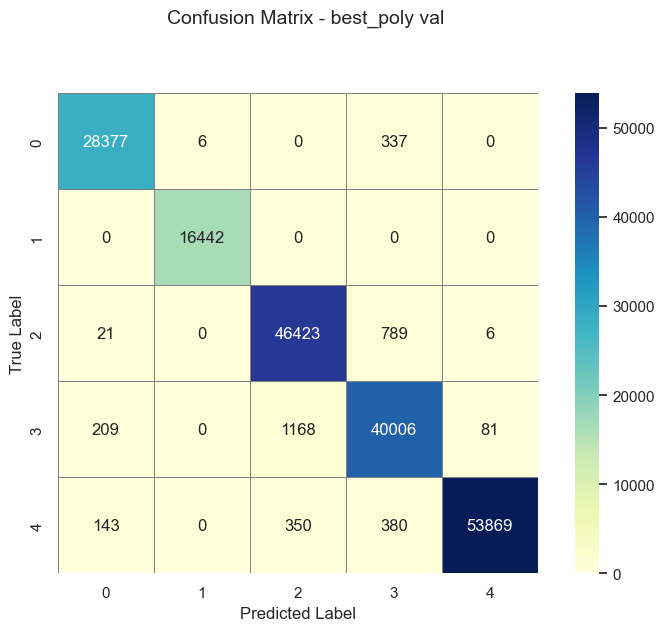

In [196]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    confusion_matrix_val, 
    annot=True,          
    fmt='d',             
    cmap='YlGnBu',       
    linewidths=0.5,
    linecolor='gray',
    cbar=True,
    square=True          
)

plt.suptitle('Confusion Matrix - best_poly val', fontsize=14, y=1.05)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)


plt.tight_layout()
plt.show()

Судя по карте, модель путает больше всего:
- третий класс со вторым
- нулевой с первым

У самого малочисленного класса recall самый маленький 0.96 (по сравнению с остальными классами), но тем не менее достаточно хороший.

**Веса модели**

Поскольку ядро - poly, то привычным способом столбцы (просто отобрать признаки и применить coef_[0]) отобрать не получится.

Запустим пайплайн модели целиком (с препроцессором и RFE) снова и получим признаки. Долго выполняется (критичен к количеству данных). Поэтому делаем это на sample выборке, такжк ка и best_poly!!! 

Сперва возьмём названия признаков (44 признака) после предобработки, этап 'preprocessor' из нашей poly модели: best_model

In [197]:
best_model = svc_grid_search_poly.best_estimator_
preprocessor_step = best_model.named_steps['preprocessor']
ohe_features = preprocessor_step.get_feature_names_out()

Для определения весов признаков воспользуемся методом `permutation_importance`, который работает со входными и выходными данными.

In [198]:
result = permutation_importance(
    estimator=best_model, 
    X=X_sample,           
    y=y_sample, 
    scoring='f1_weighted',
    n_repeats=30, 
    random_state= RANDOM_SEED,
    n_jobs=-1
)

Создадим пустой словарь `aggregated_importance` для наших признаков, с нулевыми весами

In [199]:
raw_features = list(X_sample.columns)
aggregated_importance = {name: 0.0 for name in raw_features}

собирём **веса** всех новых признаков, созданных на этапе препроцессора, и сохраним их к одному исходному признаку 

In [200]:
for ohe_name, imp in zip(ohe_features, result.importances_mean):
    base_name = ohe_name.split('__')[-1] 
    
    if base_name not in aggregated_importance:
        if ohe_name in raw_features:
            base_name = ohe_name
        else:
            aggregated_importance[base_name] = 0.0
            
    aggregated_importance[base_name] += imp

# Собираем финальный отчет
final_df = pd.DataFrame(list(aggregated_importance.items()), columns=['feature', 'importance'])
final_sorted = final_df.sort_values('importance', ascending=False).reset_index(drop=True)

display(final_sorted.head(15))

,feature,importance
0,ads_activity_очень часто,0.535151
1,ads_activity_редко,0.461577
2,share_age_group_website_category,0.417276
3,share_of_visited_websites,0.358274
4,session_clicks_devices,0.353358
5,share_age_group_daytime,0.281657
6,primary_device_ноутбук,0.268954
7,max_active_daytime,0.185606
8,ads_activity_часто,0.177233
9,share_age_group_primary_device,0.174324


Определили наиболее весомые признаки для определения возраста пользователя являются:
- ads_activity (характеристика CTR)
- share_age_group_daytime (доля пользователей по возрастам в зависимости от времени посещения за день)
- share_of_visited_websites (доля интернет-активности пользователя приходится в зависимости от посещение  разных категорий сайтов website_category)
- session_clicks_devices (session_clicks_devices`, перемножим признаки: mean_session х share_of_user_clicks х share_of_user_devices)
- share_age_group_ads_activity (доля пользователей по возрастам по активности CTR)
- users_activity ()
- max_active_daytime (наиболее активное время суток у пользователя )
- share_age_group_website_category (доля пользователей по возрастам в зависимости от количества посещённых сайтов)

Лидеры - первые три: **ads_activity, share_age_group_daytime, share_of_visited_websites**

## Подготовка артефактов модели для внедрения

Создадим функцию для объединения датафреймов и создания признаков

In [216]:
def merge_df (tmp0, tmp1, tmp2, tmp3, tmp4, tmp5):
    '''
    Объединяет 6 датафреймов в один
    tmp0, tmp1, tmp2, tmp3, tmp4, tmp5 - датафреймы, которые надо объединить
    user_id - поле, по которому объединяются датафреймы

    Создаёт призн
    '''
    df=tmp0.copy()
    for dataframe in [tmp1, tmp2, tmp3, tmp4, tmp5]:
        df=df.merge(dataframe, on='user_id')
    #Создаём новые признаки
    # количество сессий пользователя в каждой категории
    count_website_category_user=df.groupby(['user_id', 'website_category'])['website_category'].transform('count')
    # количество сесстий кользователя
    user_count_ALL_sessii=df.groupby('user_id')['session_id'].transform('count')
    # + share_of_visited_websites - доля интернет-активности пользователя
    df['share_of_visited_websites']=(count_website_category_user / user_count_ALL_sessii).round(3)

    # + max_active_daytime
    max_daytime=df.groupby(['user_id', 'daytime'])['daytime'].count()
    max_active_daytime=max_daytime.groupby('user_id').max().reset_index(name='max_active_daytime')
    df=df.merge(max_active_daytime, on=['user_id'])

    # share_daytime - вспомогательный
    sessions_in_group = df.groupby(['user_id', 'daytime'])['session_id'].transform('count')
    share_daytime=(sessions_in_group / user_count_ALL_sessii)

    # + share_of_daytime_degree6
    df['share_of_daytime_degree6'] = share_daytime ** 6

    # + share_of_user_devices
    count_primary_device=df.groupby(['primary_device'])['user_id'].transform('count')
    count_primary_device_user=df.groupby(['primary_device', 'user_id'])['age_category'].transform('count')
    df['share_of_user_devices']=((count_primary_device_user/count_primary_device)*1000)

    # + relative_audience_weight
    df['relative_audience_weight']=df.groupby(['age_category', 'website_category','user_id'])['user_id'].transform('count')


    # + session_clicks_devices
        # share_of_user_clicks вспомогательный
    count_ads_activity_user=df.groupby(['ads_activity', 'user_id'])['user_id'].transform('count')
    share_of_user_clicks=((count_ads_activity_user/df.groupby(['ads_activity'])['user_id'].transform('count'))*1000)
       # mean_session вспомогательный
    mean_session=(df.groupby(['user_id', 'date'])['session_id'].transform('count')/user_count_ALL_sessii)
    
    df['session_clicks_devices'] = share_of_user_clicks*mean_session * df['share_of_user_devices']

    
    # + users_activity состоит из произведения трех признаков
      # share_daytime вспомогательный
    sessions_in_group = df.groupby(['user_id', 'daytime'])['session_id'].transform('count')
    share_daytime=(sessions_in_group / user_count_ALL_sessii).round(3) 
    
    df['users_activity'] = share_daytime*share_of_user_clicks*mean_session
   
    # рассчитаем ещё 4 признака
    age_count = df.groupby(['age_category', 'user_id'])['user_id'].transform('count')
    for_age_list = ['primary_device', 'ads_activity', 
                    'daytime', 'website_category']
    for col in for_age_list:
        group_counts = df.groupby([col, 'age_category'])['user_id'].transform('count')
        col_name = f'share_age_group_{col}'
        df[col_name] = round(group_counts / age_count, 4)

    # users_character - обобщенный показатель

     # Преобразуем признаки
    df['cloud_usage']=df['cloud_usage'].astype(int)
    df['date'] = pd.to_datetime(df['date'])
    df['day_week'] = df['date'].dt.dayofweek
    
    for_users_character = ['cloud_usage', 'date', 'day_week',
                           'primary_device', 'ads_activity', 
                           'daytime', 'website_category']
    sum_users_character=0
    for col in for_users_character:
        group_counts = df.groupby([col, 'age_category'])['user_id'].transform('count')
        sum_users_character = sum_users_character + group_counts
        
    df['users_character'] = (sum_users_character) / age_count


    # Удалим ненужные признаки
    for_delete = ['date', 'day_week', 'daytime', 'session_id', 'mean_session',
                 'user_id', 'age_category']
    df = df.drop(columns=for_delete, errors='ignore')

    # Понижаем разрядность
    list_int = ['cloud_usage', 'max_active_daytime', 'relative_audience_weight']
    for col in list_int:
        df[col] = pd.to_numeric(df[col], downcast='integer')

    list_float = ['share_of_visited_websites', 'share_of_daytime_degree6', 'share_of_user_devices',
                 'session_clicks_devices', 'users_activity', 'share_age_group_primary_device',
                 'share_age_group_ads_activity', 'share_age_group_daytime', 'share_age_group_website_category',
                 'users_character']
    for col in list_float:
        df[col] = pd.to_numeric(df[col], downcast='float')
    
    return df

In [217]:
df_new=merge_df (df_ds_s13_users, df_cloud_usage, df_ads_activity, df_primary_device, df_surf_depth, df_ds_s13_visits)

In [218]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 939148 entries, 0 to 939147
Data columns (total 17 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   cloud_usage                       939148 non-null  int8   
 1   ads_activity                      939148 non-null  object 
 2   primary_device                    939148 non-null  object 
 3   surf_depth                        939148 non-null  object 
 4   website_category                  939148 non-null  object 
 5   share_of_visited_websites         939148 non-null  float32
 6   max_active_daytime                939148 non-null  int16  
 7   share_of_daytime_degree6          939148 non-null  float32
 8   share_of_user_devices             939148 non-null  float32
 9   relative_audience_weight          939148 non-null  int16  
 10  session_clicks_devices            939148 non-null  float32
 11  users_activity                    939148 non-null  f

In [209]:
df_new.head()

,cloud_usage,ads_activity,primary_device,surf_depth,website_category,share_of_visited_websites,max_active_daytime,share_of_daytime_degree6,share_of_user_devices,relative_audience_weight,session_clicks_devices,users_activity,share_age_group_primary_device,share_age_group_ads_activity,share_age_group_daytime,share_age_group_website_category,users_character
0,1,умеренно,ноутбук,средне,category 17,0.051,226,0.005029,3.624968,28,0.447652,0.051125,17.826,65.7363,105.3004,9.6832,344.016484
1,1,умеренно,ноутбук,средне,category 19,0.092,226,0.005029,3.624968,50,0.447652,0.051125,17.826,65.7363,105.3004,17.3516,351.684982
2,1,умеренно,ноутбук,средне,category 18,0.079,226,0.005029,3.624968,43,0.447652,0.051125,17.826,65.7363,105.3004,18.5037,352.836996
3,1,умеренно,ноутбук,средне,category 20,0.092,226,0.005029,3.624968,50,0.447652,0.051125,17.826,65.7363,105.3004,14.8315,349.164835
4,1,умеренно,ноутбук,средне,category 05,0.033,226,0.005029,3.624968,18,0.447652,0.051125,17.826,65.7363,105.3004,14.5458,348.879121


Датафрейм **df_new** - создан для проверки работы функции **merge_df**. Проверили, функция работает.

Сохраняю пайплайн предобработки

In [219]:
joblib.dump(preprocessor, 'preprocessor.joblib')

['preprocessor.joblib']

Сохраняю финальную модель

In [220]:
joblib.dump(best_poly, 'best_poly.joblib')

['best_poly.joblib']

Сохраняю информацию о выбранных признаках

In [222]:
#import json

# feature_names у меня получены выше:
# feature_names = rfe_step.get_feature_names_out()

with open('selected_features.json', 'w', encoding='utf-8') as f:
    # Преобразуем numpy array со строками в обычный список Python
    json.dump(feature_names.tolist(), f, ensure_ascii=False, indent=4)

print("Список признаков сохранен в selected_features.json")

Список признаков сохранен в selected_features.json


**Проверяю работоспособность кода**

1. Проверка: загружаю модель, загружаю данные по новому клиенту и сделаю предсказание

**Проверяю модель на тестовой выборке test**

In [224]:
loaded_pipe = joblib.load('preprocessor.joblib')
result = loaded_pipe.fit_transform(X_test, y_test) #
print(f'Препроцессинг новых данных X_test: {result.info()}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188610 entries, 0 to 188609
Data columns (total 43 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   cloud_usage                       188610 non-null  float32
 1   share_of_visited_websites         188610 non-null  float32
 2   max_active_daytime                188610 non-null  float32
 3   share_of_user_devices             188610 non-null  float32
 4   relative_audience_weight          188610 non-null  float32
 5   session_clicks_devices            188610 non-null  float32
 6   share_age_group_primary_device    188610 non-null  float32
 7   share_age_group_ads_activity      188610 non-null  float32
 8   share_age_group_daytime           188610 non-null  float32
 9   share_age_group_website_category  188610 non-null  float32
 10  users_character                   188610 non-null  float32
 11  ads_activity_очень редко          188610 non-null  f

Проверяю модель best_poly

In [225]:
estimator = joblib.load('best_poly.joblib')

Получим метки классов на test

In [226]:
y_test_pred = best_poly.predict(X_test)

In [227]:
print('Classification report,  val:\n', classification_report(y_test, y_test_pred))

Classification report,  val:
               precision    recall  f1-score   support

           0       0.94      0.99      0.96     26886
           1       1.00      0.92      0.96     17943
           2       0.97      0.97      0.97     46809
           3       0.96      0.96      0.96     41873
           4       1.00      0.99      0.99     55099

    accuracy                           0.97    188610
   macro avg       0.97      0.97      0.97    188610
weighted avg       0.97      0.97      0.97    188610



**Проверяем признаки**

In [234]:
features_df = pd.read_json('selected_features.json')

print(f'Выводим первые 5 признаков: {features_df.head()}')
display('='*120)
display('Список всех сохранённых признаков: ') 
display('='*120)
display(f'{features_df.squeeze().tolist()}') 
display('='*120)

Выводим первые 5 признаков:                            0
0                cloud_usage
1  share_of_visited_websites
2         max_active_daytime
3      share_of_user_devices
4   relative_audience_weight


'========================================================================================================================'

'Список всех сохранённых признаков: '

'========================================================================================================================'

"['cloud_usage', 'share_of_visited_websites', 'max_active_daytime', 'share_of_user_devices', 'relative_audience_weight', 'session_clicks_devices', 'share_age_group_primary_device', 'share_age_group_ads_activity', 'share_age_group_daytime', 'share_age_group_website_category', 'users_character', 'ads_activity_очень редко', 'ads_activity_очень часто', 'ads_activity_редко', 'ads_activity_умеренно', 'ads_activity_часто', 'primary_device_ноутбук', 'primary_device_пк', 'primary_device_планшет', 'primary_device_смартфон', 'surf_depth_глубоко', 'surf_depth_поверхностно', 'surf_depth_средне', 'website_category_category 01', 'website_category_category 02', 'website_category_category 03', 'website_category_category 04', 'website_category_category 05', 'website_category_category 06', 'website_category_category 07', 'website_category_category 08', 'website_category_category 09', 'website_category_category 10', 'website_category_category 11', 'website_category_category 12', 'website_category_category

'========================================================================================================================'

## Выводы о результатах работы

Выведем все результаты

In [ ]:
display('='*110)
display(f'Метрики и параметры полученных моделей:' )
display('='*110)
with pd.option_context('display.max_colwidth', None): 
    display(df_models_results)

display('='*110)


print('='*110)
print('Метрики precision, recall, f1 лучшей модели best_poly на train и val: ')
print('='*110)
print(df_results_train_val)
print('='*110)

print('\nClassification report best_poly,  val:\n', classification_report(y_val, y_val_pred))
display('='*110)
print(f'\nЗначимые признаки')
display('='*110)
display(final_sorted.head(15))
display('='*110)

Построена модель машинного обучения, которая по данным о поведении анонимного пользователя в цифровой среде определет его примерный возраст

В ходе исследования были построены 4 модели: 
- множественной линейной регрессии
- опорных векторв (svc)
- полиномиальная модель (poly)
- радиальная модель (rbf)

Поиск гиперпараметров не значительно улучшил модели lr и svc. Применение нелинейного ядра позволило повысить качество модели до приемлемых значений.

Больше всего на качество модели оказало создание разнообразных числовых признаков.

Наилучшие метрики у нелинейных моделей rbf и poly. Для продакшена отобрана с наилучшими - poly (best_poly).
Основная её метрика F1-weighted и вспомогательные precision и recall на уровне 0,98. Модель точно определяет возраст пользователя. 

Модель рекомендуется для продакшена.

Наиболее влиятельных признаков - три: ads_activity (характеристика CTR), share_age_group_daytime (доля пользователей по возрастам в зависимости от времени посещения за день) и share_of_visited_websites (доля интернет-активности пользователя приходится в зависимости от посещение  разных категорий сайтов website_category).
